In [1]:
from utils import *
from dipole import *
import pickle
import os
from scipy.optimize import curve_fit
import matplotlib as mpl
from lxml import etree
from collections import Counter
import hist
from hist import Hist
import numpy as np
import os 
from scipy.interpolate import interp1d
from scipy.stats import gamma

def calculate_corrected_upper_limits(raw_counts, efficiency, confidence_level=0.90):
    """
    Calculates the corrected upper limits for a trap histogram.
    
    Parameters:
    - raw_counts: numpy array of the raw (uncorrected) trap counts per bin
    - efficiency: numpy array of the detection efficiency per bin (0.0 to 1.0)
    - confidence_level: desired confidence level for the upper limit (e.g., 0.90 for 90% CL)
    
    Returns:
    - corrected_upper_limits: The efficiency-corrected upper limit array
    """
    # 1. Calculate the Poisson upper limit on the RAW observed counts.
    # We use the Gamma distribution ppf which is the exact continuous equivalent 
    # for Poisson confidence intervals. (e.g., For N=0 counts, limit is ~2.3)
    raw_upper_limits = gamma.ppf(confidence_level, raw_counts + 1)

    # 2. Apply the efficiency correction to the upper limits
    corrected_upper_limits = np.zeros_like(raw_upper_limits, dtype=float)
    
    # 3. Safely handle efficiencies
    # We include the < 5% bins here. If efficiency is exactly 0, the limit is infinity.
    valid_mask = efficiency > 0
    
    corrected_upper_limits[valid_mask] = raw_upper_limits[valid_mask] / efficiency[valid_mask]
    
    # Where efficiency is 0, we set the upper limit to infinity 
    # (or you can use np.nan if matplotlib complains during plotting)
    corrected_upper_limits[~valid_mask] = np.inf 
    
    return corrected_upper_limits
def format_sci(number):
    """
    Formats a float into scientific notation with 3 decimal places.
    Example: 12345.6789 -> "1.235e+04"
    """
    return "{:.3e}".format(number)


def linear_func(x,m,b):
    y = m*x + b
    return y


# Load XML, parse points, and create LinearSegmentedColormap
def load_scivis_cmap(xml_file):
    tree = etree.parse(xml_file)
    nodes = tree.findall('.//Point')
    # Normalize positions and get RGB values
    colors = [(float(n.get('r')), float(n.get('g')), float(n.get('b'))) for n in nodes]
    positions = [float(n.get('x')) for n in nodes]
    
    # Create the segmented dictionary
    cdict = {'red': [], 'green': [], 'blue': []}
    for pos, color in zip(positions, colors):
        cdict['red'].append((pos, color[0], color[0]))
        cdict['green'].append((pos, color[1], color[1]))
        cdict['blue'].append((pos, color[2], color[2]))
        
    return mpl.colors.LinearSegmentedColormap('SciVisColor', cdict)

# Generate cmap object
my_cmap = load_scivis_cmap('2-redy3.xml')


In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from matplotlib import colors
from matplotlib import cm, ticker

# plotting specifications
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                            AutoMinorLocator)
from matplotlib.offsetbox import AnchoredText

smaller= 20
small = 24
medium = 30
large = 36

params = {'text.usetex' : True,
        'font.size' : small,
        'font.family' : 'serif',
        'figure.autolayout': True
        }
plt.rcParams.update(params)
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['axes.labelsize']=small
plt.rcParams['figure.figsize']=(5,5)
plt.rcParams['axes.formatter.use_mathtext']=True

In [3]:
# --- Consistent paper palette ---------------------------------------------
# One color per semantic role, used across all figures.
C_RED  = '#be0031'   # trap-affected / Monte Carlo / 'with traps'
C_BLUE = '#00429d'   # observed / baseline / 'without traps'
C_REF  = 'slategrey' # reference lines (operating temp, 1h/1day/1yr, etc.)
C_SEQ  = ['#be0031', '#00429d', '#FFB000', 'seagreen', 'darkviolet']  # multi-series

In [4]:
image_dir_search = 'proc/*.fits'
temperatures = []
for image in glob.glob(image_dir_search):
    # Using a raw string r'' to fix the \d escape sequence warning
    found = re.findall(r'_\d+k', image)
    if not found:
        continue
    temp = found[0][1:-1]
    
    if 'dtph' not in image:
        continue
        
    temperatures.append(temp)
    
temperatures_strs = np.array(temperatures)

temps = np.sort(np.array([int(t) for t in temperatures_strs]))
test_temps = np.unique(temps)
print("Unique temperatures:", test_temps)
good_quads=[0, 1, 2, 3]
try:
    coords_npz = np.load('dipole_coord_list.npz')
    full_dipole_coord_list = []
    for i in range(len(good_quads)):
        if f'quad_idx_{i}' in coords_npz:
            full_dipole_coord_list.append([tuple(c) for c in coords_npz[f'quad_idx_{i}']])
        else:
            full_dipole_coord_list.append([])
    print("Loaded dipole_coord_list.npz")
except FileNotFoundError:
    print("dipole_coord_list.npz not found. Computing...")

# Calculate total dipoles across valid quadrants
total = sum(len(full_dipole_coord_list[q]) for q in good_quads)
total = sum(len(q_list) for q_list in full_dipole_coord_list)
print(f"Total dipoles: {total}")

Unique temperatures: [125 130 135 140 145 150 155 160 165 170 175 180 183 185 187 190 193 195
 197 200 203 207 210]
Loaded dipole_coord_list.npz
Total dipoles: 5171


In [5]:
try:
    mcdict = np.load('mc_dist.npz', allow_pickle=True)
    mcdict = np.load('mc_dist.npz')
    montecarlo_hists = mcdict['montecarlo_hists']
    mc_bin_centers = mcdict['mc_bin_centers']
    mc_mean = mcdict['mc_bin_cemc_meannters']
    mc_mean = mcdict['mc_mean']
    ci_lower = mcdict['ci_lower']
    ci_upper = mcdict['ci_upper']
    print("Loaded mc_dist.npz")
except FileNotFoundError:
    print("mc_dist.npz not found.")

Loaded mc_dist.npz


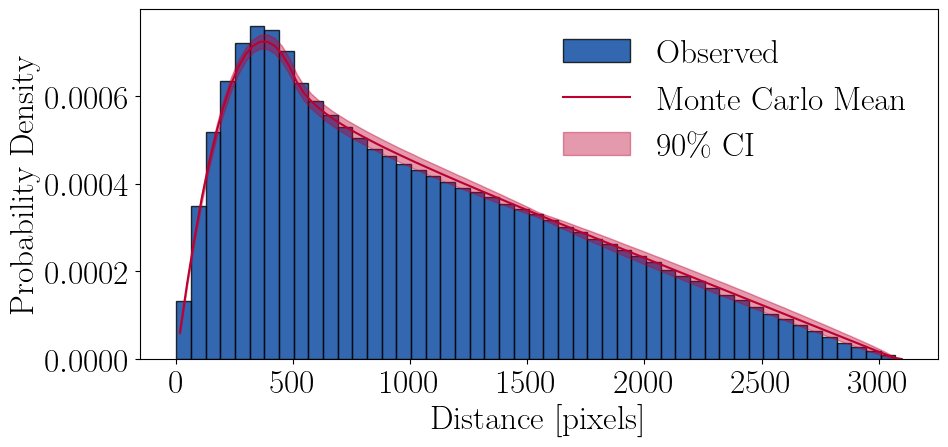

In [6]:
#analyze spatial distribution here
# 90% confidence interval
plt.figure(figsize=(10,5))
ax = plt.gca()
mccolor = C_RED
observed_color = C_BLUE
# plt.plot(mc_bin_centers, spline(mc_bin_centers), label='Spline Fit', color='black', linestyle='--')

from scipy.spatial.distance import pdist
bins_ = np.linspace(0,3072,50)

# all_hists = np.zeros(len(bins_)-1)
all_hists = (
        hist.Hist.new.Reg(50, 0, 3072, name="Distances", label="Distances")
        .Weight()
    )
all_distances = []
for q in [0,1,2,3]:
    quad_dipoles = np.array(full_dipole_coord_list[q])
    distances = pdist(quad_dipoles)
    h_from_data = (
        hist.Hist.new.Reg(50, 0, 3072, name="Distances", label="Distances")
        .Weight()
    )
    h_from_data.fill(distances)
    all_distances.append(distances)

    # hist,bins = np.histogram(distances,bins=bins_,density=False)
    # pdf,bins = np.histogram(distances,bins=bins_,density=True)
    all_hists += h_from_data
    # plt.stairs(pdf,bins,label=f'Quadrant {q+1}')


all_distances = np.concatenate(all_distances)
# bin_widths = np.diff(bins)
# pdf = all_hists / (np.sum(all_hists) * bin_widths)


# h = (
#     hist.Hist.new.Reg(len(counts), bin_edges[0], bin_edges[-1], name="x", label="Value")
#     .Double() # Use Double precision for counts
# )

# mchist,bins = np.histogram(mc_distances,bins=bins)
# mchist = mchist/np.sum(mchist)
# plt.stairs(pdf,bins,label='Observed',lw=3)

# all_hists.plot1d(ax=ax,histtype='fill',density=True,yerr=True,label='Observed',alpha=0.8,color=observed_color)
plt.hist(all_distances,bins_,color=observed_color, edgecolor='black', alpha=0.8,label='Observed',density=True)
plt.plot(mc_bin_centers, mc_mean, label='Monte Carlo Mean', color=mccolor)
plt.fill_between(mc_bin_centers, ci_lower, ci_upper, color=mccolor, alpha=0.4, label='90\% CI')
plt.legend(fontsize=small,frameon=False)
# print(np.max(distances))
# plt.hist(distances)
plt.xlabel('Distance [pixels]',fontsize=small)
plt.ylabel('Probability Density',fontsize=small)
# plt.title('Distribution of Dipoles',fontsize=20)
plt.savefig('figures/trap_distribution.pdf',dpi=300)
plt.show()
plt.close()

In [7]:
try:
    dipole_spectra = load_spectra_hdf5('dipole_spectra.h5')
    print("Loaded dipole_spectra.h5")
except FileNotFoundError:
    print("dipole_spectra.h5 not found. Computing...")

Loaded dipole_spectra.h5


In [8]:

useIntensityErr = True
wellBehavedThreshold = 4
threshold_str = f'_{wellBehavedThreshold}'
intensity_str = '_err' if useIntensityErr else ''



threshold_str = f'_{wellBehavedThreshold}'
spectra_filename = f'fit_dipole_spectra{intensity_str}{threshold_str}.h5'

try:
    fit_dipole_spectra = load_spectra_hdf5(spectra_filename)

    print(f"Loaded {spectra_filename}")
except FileNotFoundError:
    raise FileNotFoundError(f"{spectra_filename} not found.")


Loaded fit_dipole_spectra_err_4.h5


In [9]:
# from pympler import asizeof

In [10]:
# print(asizeof.asizeof(dipole_spectra)*1e-9
#       ) # Returns total recursive size

# print(asizeof.asizeof(fit_dipole_spectra)*1e-9
#       ) # Returns total recursive size

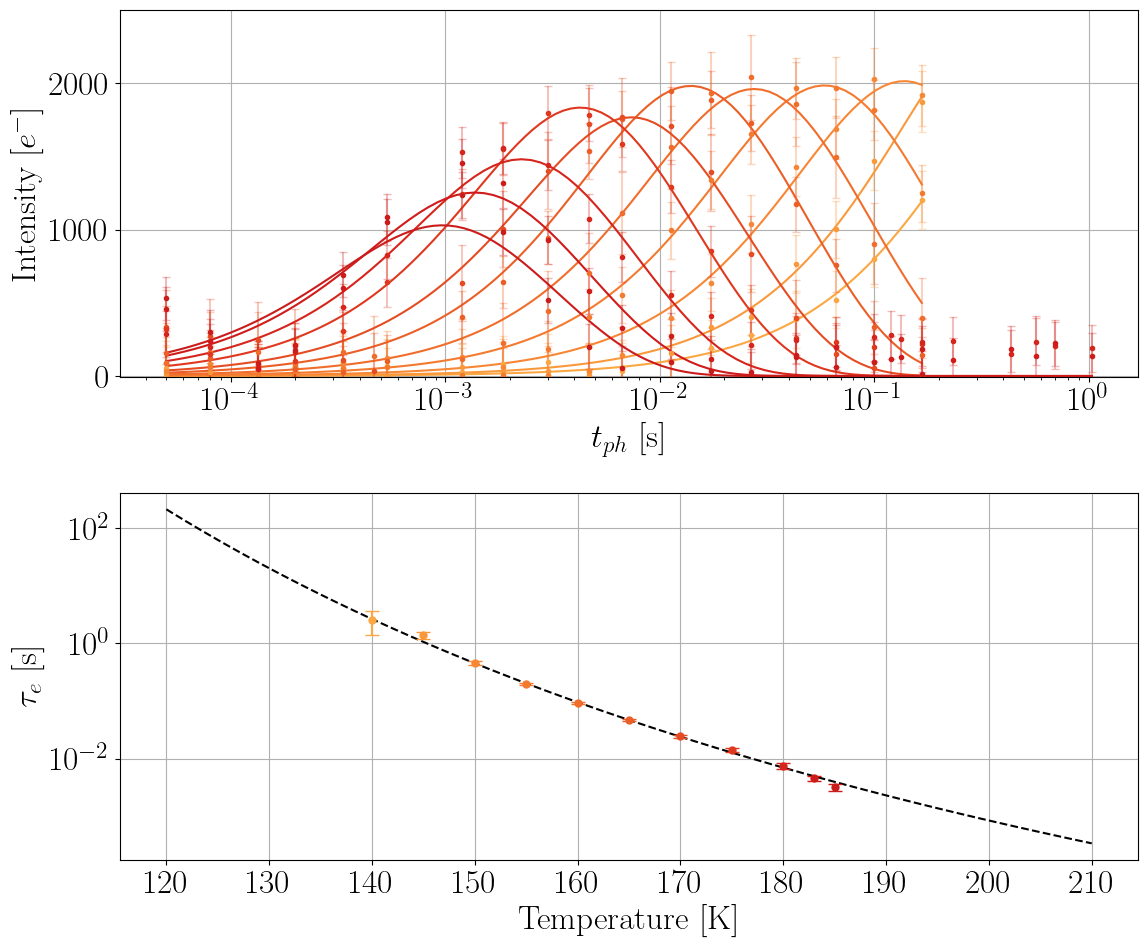

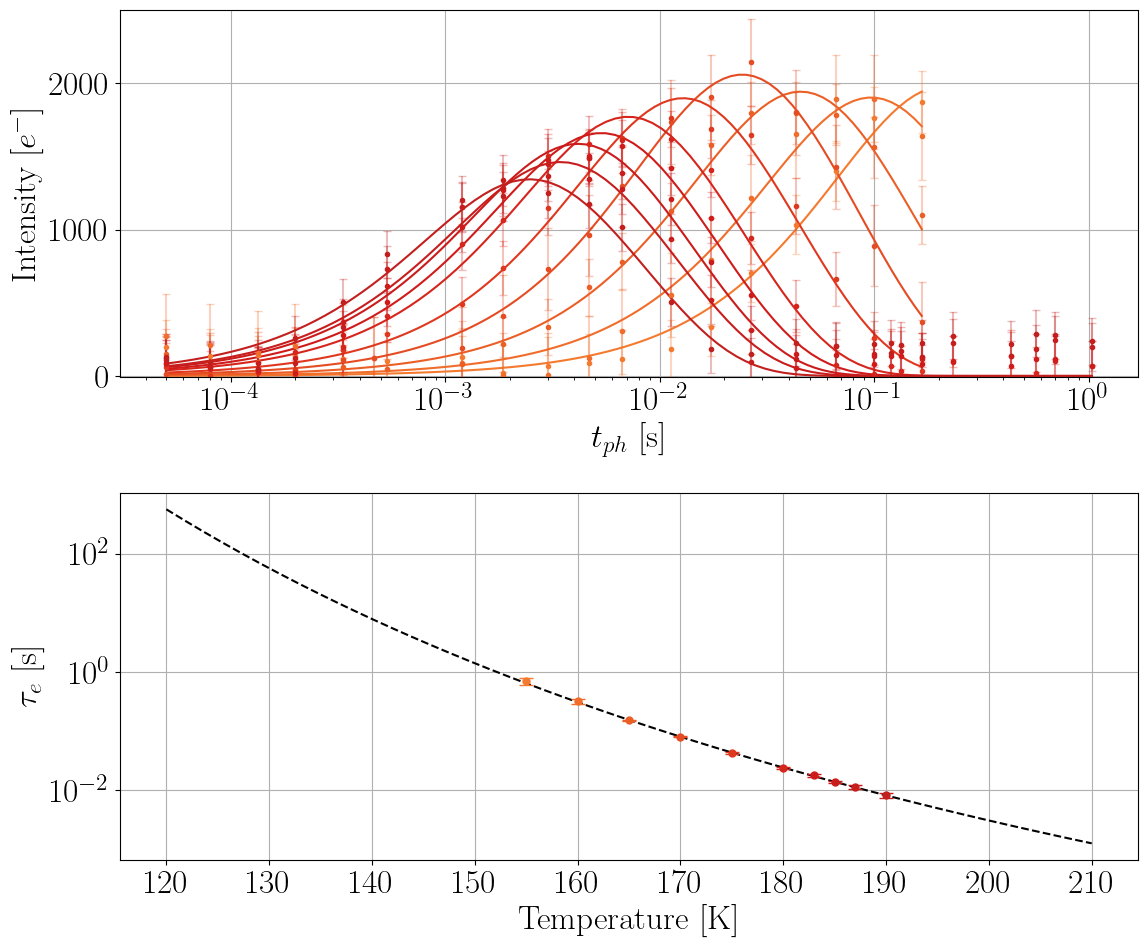

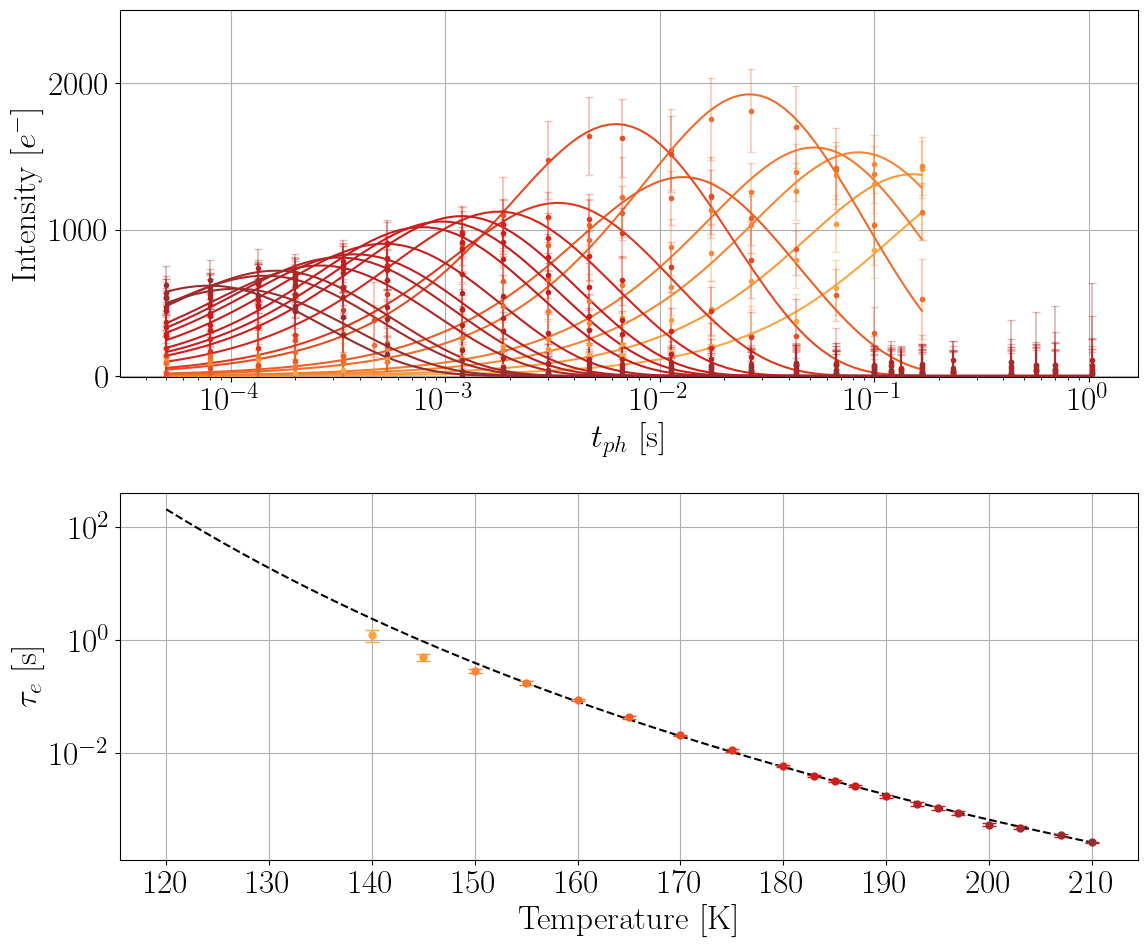

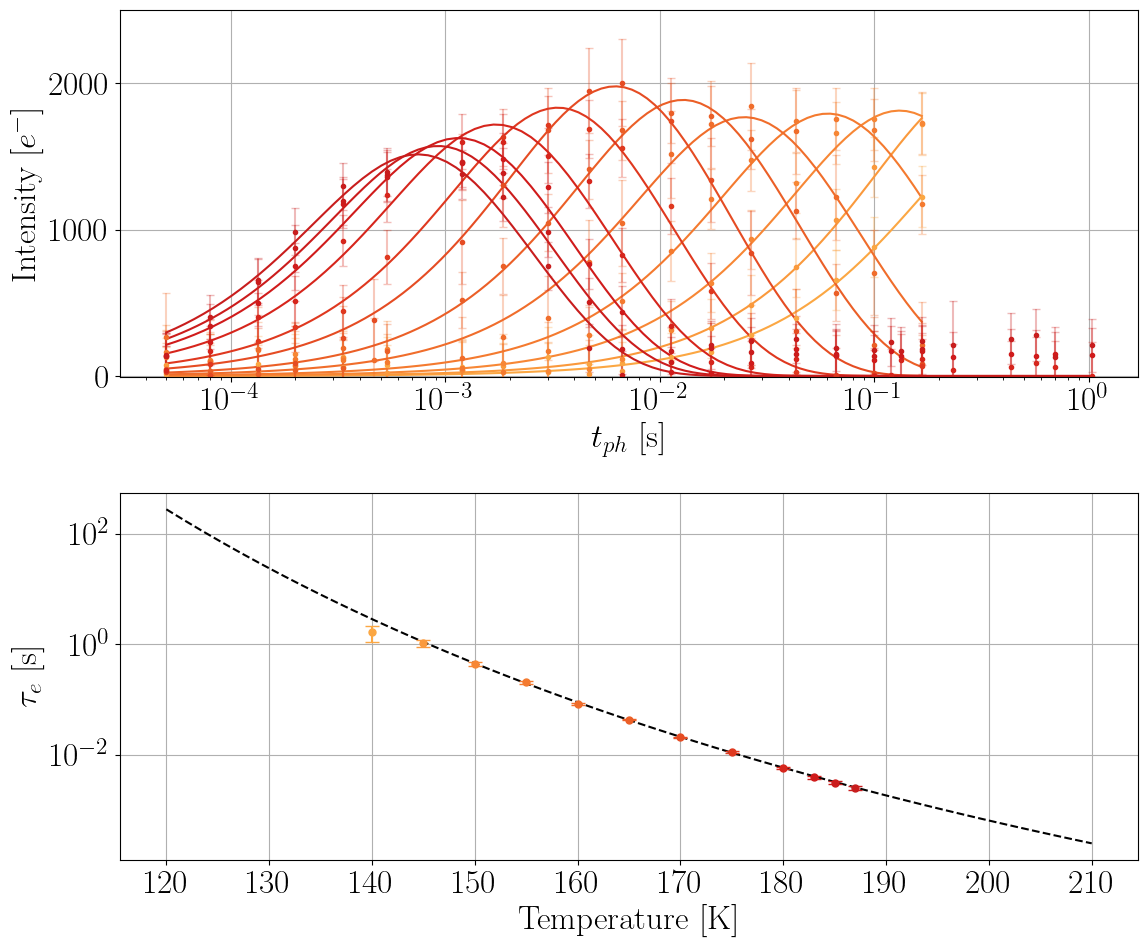

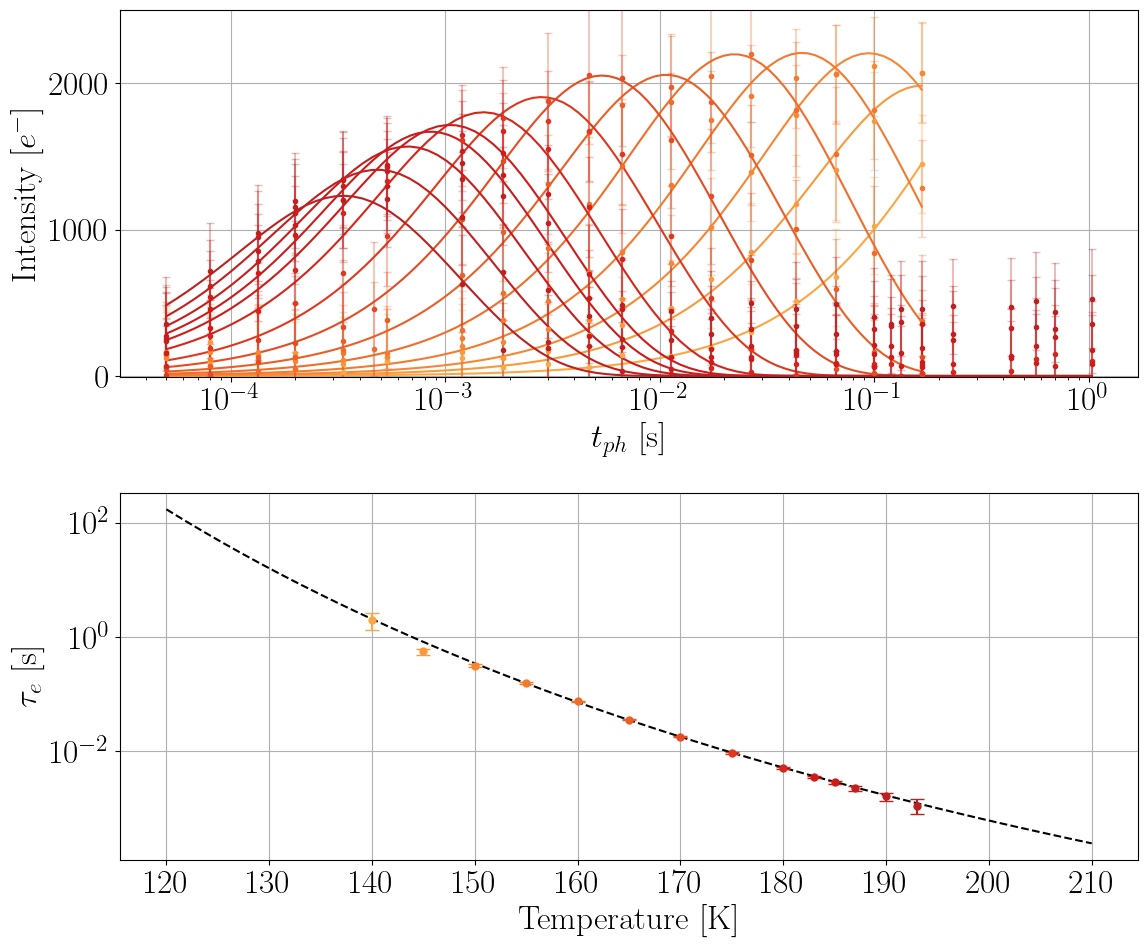

Number of Good Energy Fits Plotted: 
2135


In [11]:
cmap = my_cmap
# cmap = plt.cm.managua_r

norm = colors.Normalize(vmin=100,vmax=250)

energy_crossSections  = []
tau_temp_fits = []
maxtaus = []
plot = True
max_plots = 5
num_plotted = 0
measurement_temperatures = [125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 183, 185, 187, 190, 193, 195, 197, 200, 203, 207, 210]

tau_temperatures = {

}
for t in measurement_temperatures:
    tau_temperatures[t] = {'measured' : [], 'extrapolated': []}
    
# measured_taus = []
# extrapolated_taus = []
for q in [0,1,2,3]:
    
    dpkeys = list(fit_dipole_spectra[q])
    for i in range(len(dpkeys)):
        
        dp = dpkeys[i]
        if type(dp) != tuple:
            continue
        testdp = fit_dipole_spectra[q][dp]
        
        if testdp['WellBehavedTrap'] and not testdp['EnergyFitFailed']:

            p_value = testdp['energy_p_value'] 
            chi_squared = testdp['energy_chi2']
            r2 = testdp['energy_r_squared']

            fit_is_good = chi_squared < 100
            fit_is_good = p_value < 0.05
            fit_is_good = testdp["GoodEnergyFit"]
            
            maxtau = np.max(testdp['energy_taus'])
            maxtaus.append(maxtau)

            if fit_is_good:
                cs = testdp['energy_BestFitCrossSection']
                cserr = testdp['energy_BestFitCrossSectionErr']
                e = testdp['energy_BestFitEnergy']
                e_err = testdp['energy_BestFitEnergyErr']

                avg_good_temp = np.mean(testdp['energy_temperatures'])

                # if 135 > np.min(testdp['energy_temperatures']) and 135 < np.max(testdp['energy_temperatures']):
                for t in measurement_temperatures:
                    logtau = log_energy_cross_section(t, e, np.log(cs))
                    tau = np.exp(logtau)
                    
                    if t in testdp['energy_temperatures']:
                        tau_temperatures[t]['measured'].append(tau)
                    else:
                        tau_temperatures[t]['extrapolated'].append(tau)

                # if 135 in testdp['energy_temperatures']:
                #     measured_taus.append(tau_at_135)
                # else:
                #     extrapolated_taus.append(tau_at_135)
                
                #uncheck this to filter

                # if 135 not in testdp.keys():
                #     continue

                pcov = testdp['energy_CovarianceMatrix']
                perr1 = cserr / cs
                perr = np.array([testdp['energy_BestFitEnergyErr'], perr1])
                corr_matrix = pcov / np.outer(perr, perr)
                avg_corr = (corr_matrix[0,1] + corr_matrix[1,0])/2
                
                # if testdp["GoodEnergyFit"]:
                energy_crossSections.append((cs, e, cserr, e_err, avg_good_temp))
                tau_temp_fits.append([testdp['energy_temperatures'], testdp['energy_taus'], testdp['energy_tau_errs']])
                
                if plot and num_plotted < max_plots and len(testdp['energy_taus']) > 8:
                    num_plotted += 1
                    fig, ax = plt.subplots(2,1,figsize=(12,10))
                    # fig.suptitle(f"Dipole at {int(dp[0]),int(dp[1])} Quad {q+1}",fontsize=large,y=0.94)
                    ax[0].set_xlabel('$t_{ph}$ [s]',fontsize=small)
                    ax[0].set_ylabel('Intensity [$e^-$]',fontsize=small)

                    ax[1].set_xlabel('Temperature [K]',fontsize=small)
                    ax[1].set_ylabel('$\\tau_e$ [s]',fontsize=small)
                    ax[1].set_xticks([120,130,140,150,160,170,180,190,200,210])
                    ax[0].set_xscale('log')
                    ax[1].set_yscale('log')

                    ax[0].set_ylim(-10,2500)

                    for temp in testdp.keys():
                        if type(temp) != int:
                            continue

                        color = cmap(norm(temp))
                        dipole = testdp[temp]
                        if dipole['GoodIntensityFit']:
                            sigma_image = dipole['image_sigma']
                            
                            # ax[0].scatter(dipole['seconds'],dipole['intensities'],color=color)

                            yerr = dipole['intensity_err'] if useIntensityErr else dipole['poisson_err']

                            # if useIntensityErr:
                            # line, caps, bars = ax[1].errorbar(data[0],data[1],yerr=data[3],ls='None',color=color,capsize=3,marker='o',markersize=4)
                            line, caps, bars = ax[0].errorbar(dipole['seconds'], dipole['intensities'], yerr=yerr, color=color, ls='None', capsize=3, marker='o', markersize=3)
                            for cap in caps:
                                cap.set_alpha(0.3)
                            for bar in bars:
                                bar.set_alpha(0.3)
                            # else:
                                # ax[0].errorbar(dipole['seconds'],dipole['intensities'],yerr=dipole['poisson_err'],color=color,ls='None')

                            seconds = np.geomspace(np.min(dipole['seconds']), np.max(dipole['seconds']), 100)
                            
                            # Updated to use flattened fit intensity attributes
                            fit_ints = intensity_function(seconds, dipole['fit_coeff'], dipole['fit_tau'])
                            ax[0].plot(seconds, fit_ints, ls='-', color=cmap(norm(temp)))

                    temperatures = np.linspace(120,210,50)
                    log_fit_taus = log_energy_cross_section(temperatures, testdp['energy_BestFitEnergy'], np.log(testdp['energy_BestFitCrossSection']))
                    fit_taus = np.exp(log_fit_taus)
                    ax[1].plot(temperatures, fit_taus, color='black', ls='--')
                    
                    for t_idx in range(len(testdp['energy_temperatures'])):
                        temp_val = testdp['energy_temperatures'][t_idx]
                        color = cmap(norm(temp_val))
                        tau_val = testdp['energy_taus'][t_idx]
        
                        # ax[1].scatter(temp_val,tau_val,color=color)
                        tau_err = testdp['energy_tau_errs'][t_idx]

                        ax[1].errorbar(temp_val, tau_val, yerr=tau_err, ls='None', color=color, marker='o', markersize=5, capsize=5)
                    # import matplotlib.cm as cmx
                    # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
                    # sm.set_array([])  # Required for ScalarMappable to work correctly
                    # cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
                    # cbar = fig.colorbar(sm, cax=cbar_ax)
                    
                    # cbar.set_label('Temperature [K]',fontsize=12)
                    # plt.tight_layout()
                    ax[0].grid()
                    ax[1].grid()
                    plt.savefig(f'figures/example_trap_{num_plotted-1}.pdf',dpi=300)

                    plt.show()
                    plt.close()

print("Number of Good Energy Fits Plotted: ")
print(len(energy_crossSections))


In [12]:
np.linspace(0,1,6)

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

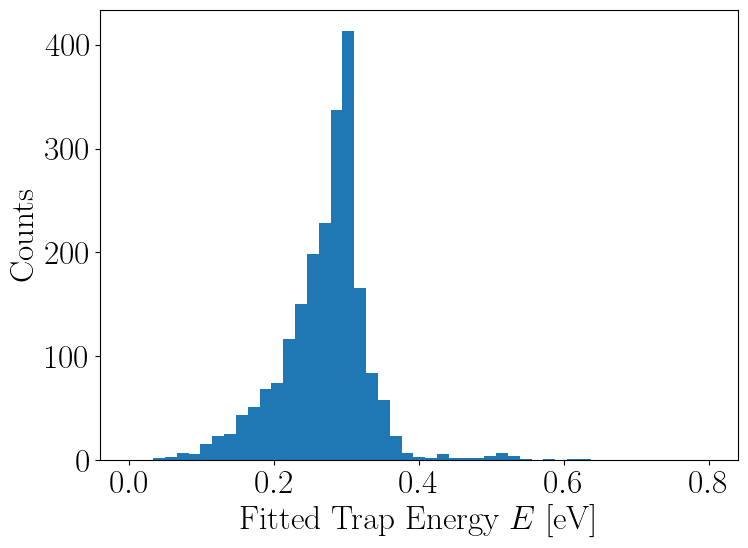

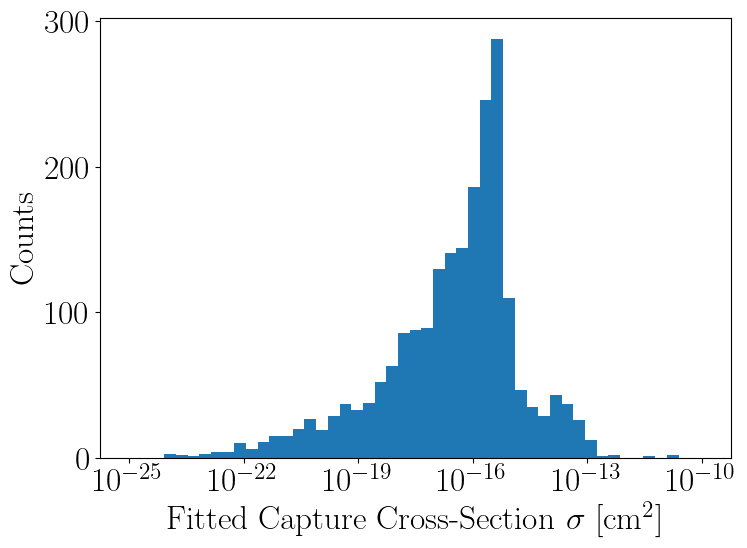

In [13]:
cross_sections = np.array(energy_crossSections)[:,0]
energies = np.array(energy_crossSections)[:,1]
plt.figure(figsize=(8,6))

plt.hist(energies,bins=np.linspace(0,0.8,50))
# plt.yscale('log')
plt.xticks(np.linspace(0,0.8,5))
plt.xlabel("Fitted Trap Energy $E$ [eV]")

plt.ylabel("Counts")

plt.show()
plt.close()

plt.figure(figsize=(8,6))
plt.hist(cross_sections,bins=np.geomspace(1e-25,1e-10,50))
plt.xscale('log')
plt.xticks(np.geomspace(1e-25,1e-10,6))
plt.xlabel("Fitted Capture Cross-Section $\sigma$ [cm$^2$]")
plt.ylabel("Counts")
plt.show()
plt.close()

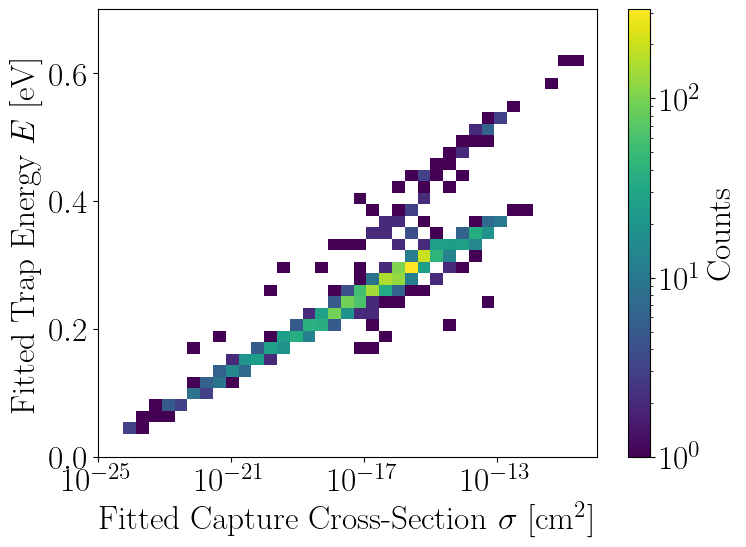

In [14]:
import matplotlib as mpl
fig, ax = plt.subplots(figsize=(8,6))

h = ax.hist2d(
    cross_sections, energies,
    bins=[np.geomspace(1e-25, 1e-10, 40), np.linspace(0, 0.7, 40)],
    cmap='viridis',
    norm=mpl.colors.LogNorm()

)

ax.set_xscale('log')
ax.set_xlabel(r"Fitted Capture Cross-Section $\sigma$ [cm$^2$]")

ax.set_ylabel(r"Fitted Trap Energy $E$ [eV]")

fig.colorbar(h[3], ax=ax, label='Counts')

plt.tight_layout()
plt.show()
plt.close()

Stage 10 produced at: 2026-05-25T13:06:09-07:00
Thermal model source: dipole.log_energy_cross_section
Stage 09 recompute max abs diff: 1.4377388168895777e-14
Histogram source: tau_at_135k_hist.npz
Trap count in histogram bins: 2135
Tau sample count: 2135


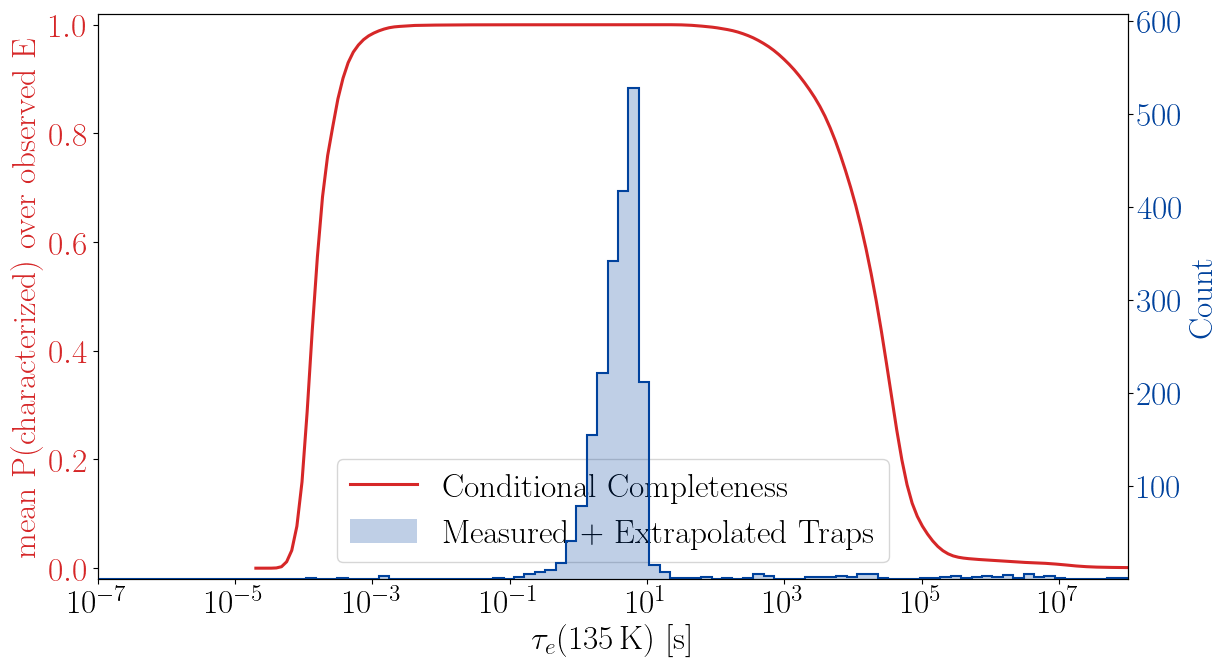

In [23]:
from pathlib import Path
import csv
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np

small = globals().get("small", 24)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "trap_completeness_method3" / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find repo root from current working directory")


repo = find_repo_root()
work = repo / "trap_completeness_method3"
cache = work / "cache"

summary_path = cache / "10_validation_sensitivity_summary.json"
statement_path = cache / "10_completeness_statement.md"
stage09_h5_path = cache / "09_characterization_probability_v1.h5"
records4_path = cache / "01_records_ngood4.csv"

summary = json.loads(summary_path.read_text())
statement = statement_path.read_text()

with h5py.File(stage09_h5_path, "r") as h5:
    tau_grid = h5["grid/tau_135_seconds"][:]
    E_grid = h5["grid/E_eV"][:]
    p4_map = h5["results/p_characterized_n_good_4"][:]
    p3_map = h5["results/p_characterized_n_good_3"][:]
    all_oob = h5["diagnostics/all_temperatures_tau_oob"][:].astype(bool)
    known_p4 = h5["validation_known_traps/n_good_4_csv/p_characterized_n_good_4"][:]
    known_tau = h5["validation_known_traps/n_good_4_csv/tau_135_seconds"][:]
    known_E = h5["validation_known_traps/n_good_4_csv/E_eV"][:]


print("Stage 10 produced at:", summary["produced_at"])
print("Thermal model source:", summary["model_notes"]["thermal_model_source"])
print("Stage 09 recompute max abs diff:", summary["model_notes"]["stage09_default_recompute_check_max_abs"])
def load_observed_E(path):
    values = []
    with path.open(newline="") as handle:
        for row in csv.DictReader(handle):
            values.append(float(row["E_eV"]))
    return np.asarray(values)


observed_E = load_observed_E(records4_path)
default_curve = np.array([np.interp(observed_E, E_grid, row).mean() for row in p4_map])
default_curve3 = np.array([np.interp(observed_E, E_grid, row).mean() for row in p3_map])
summary_points = summary["completeness_vs_tau_observed_E"]["default_n_good_4"]["representative_tau_seconds_to_mean_probability"]


tau_hist_path = repo / "tau_at_135k_hist.npz"

with np.load(tau_hist_path) as data:
    tau_edges = data["bin_edges"]

    if "total_taus" in data:
        # Current format: measured + extrapolated traps.
        tau_samples = data["total_taus"]
        tau_hist, _ = np.histogram(tau_samples, bins=tau_edges)
    elif "tau_at_135s" in data:
        # Legacy NPZ format
        tau_samples = data["tau_at_135s"]
        tau_hist, _ = np.histogram(tau_samples, bins=tau_edges)
    else:
        # Histogram-only format
        tau_samples = np.array([])
        tau_hist = data["hist"]

hist_source = tau_hist_path.name

# Some local NPZs have the bin edges but no stored traps/histogram. If so, rebuild the histogram
# from the Stage 01 characterized-trap CSV, which stores the same tau_135 quantity.
if tau_samples.size:
    tau_hist, tau_edges = np.histogram(tau_samples, bins=tau_edges)
elif int(np.sum(tau_hist)) == 0:
    tau_samples = []
    with records4_path.open(newline="") as handle:
        for row in csv.DictReader(handle):
            tau_samples.append(float(row["tau_135_seconds"]))
    tau_samples = np.asarray(tau_samples, dtype=float)
    tau_hist, tau_edges = np.histogram(tau_samples, bins=tau_edges)
    hist_source = f"rebuilt from {records4_path.name} using {tau_hist_path.name} bin edges"

print(f"Histogram source: {hist_source}")
print(f"Trap count in histogram bins: {int(tau_hist.sum())}")
print(f"Tau sample count: {tau_samples.size}")

fig, ax = plt.subplots(figsize=(16*0.8, 9*0.8))
ax.plot(tau_grid, default_curve, color="tab:red", linewidth=2.2, label="Conditional Completeness")
# ax.axhline(0.95, color="black", linestyle="--", linewidth=1, label="95% completeness")
# ax.axhline(0.90, color="gray", linestyle=":", linewidth=1, label="90% completeness")
ax.set_xscale("log")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("$\\tau_e(135\,\mathrm{K})$ [s]")
ax.set_ylabel("mean P(characterized) over observed E", color="tab:red")
ax.tick_params(axis="y", labelcolor="tab:red")

ax_hist = ax.twinx()
ax_hist.stairs(tau_hist, tau_edges, fill=True, color=C_BLUE, alpha=0.25, label="Measured + Extrapolated Traps")
ax_hist.stairs(tau_hist, tau_edges, color=C_BLUE, linewidth=1.5)
ax_hist.set_ylabel("Count", color=C_BLUE)
ax_hist.tick_params(axis="y", labelcolor=C_BLUE)
ax_hist.yaxis.get_major_ticks()[0].set_visible(False)

if np.max(tau_hist) > 0:
    ax_hist.set_ylim(0, np.max(tau_hist) * 1.15)

x_min = min(tau_grid[0], tau_edges[0])
x_max = max(tau_grid[-1], tau_edges[-1])
ax.set_xlim(x_min, x_max)

lines, labels = ax.get_legend_handles_labels()
hist_lines, hist_labels = ax_hist.get_legend_handles_labels()
ax.legend(lines + hist_lines, labels + hist_labels, loc="best", fontsize=small)
plt.savefig('figures/efficiency_completeness.pdf',dpi=300)
# ax.set_title("Completeness curve overlaid on tau_at_135k trap histogram")
# plt.grid(which='both',axis='x',color=C_REF)
plt.show()


Excluded 20 bins with completeness below 0% or outside the model grid.
number of total traps after corrections: 17726.946034201424
scal of total traps after corrections: 3.4281465933477904
bin 0: [1.000e-07, 1.417e-07] s, center=1.191e-07, efficiency=nan
bin 1: [1.417e-07, 2.009e-07] s, center=1.688e-07, efficiency=nan
bin 2: [2.009e-07, 2.848e-07] s, center=2.392e-07, efficiency=nan
bin 3: [2.848e-07, 4.037e-07] s, center=3.391e-07, efficiency=nan
bin 4: [4.037e-07, 5.722e-07] s, center=4.806e-07, efficiency=nan
bin 5: [5.722e-07, 8.111e-07] s, center=6.813e-07, efficiency=nan
bin 6: [8.111e-07, 1.150e-06] s, center=9.657e-07, efficiency=nan
bin 7: [1.150e-06, 1.630e-06] s, center=1.369e-06, efficiency=nan
bin 8: [1.630e-06, 2.310e-06] s, center=1.940e-06, efficiency=nan
bin 9: [2.310e-06, 3.275e-06] s, center=2.750e-06, efficiency=nan
bin 10: [3.275e-06, 4.642e-06] s, center=3.899e-06, efficiency=nan
bin 11: [4.642e-06, 6.579e-06] s, center=5.526e-06, efficiency=nan
bin 12: [6.579e-0

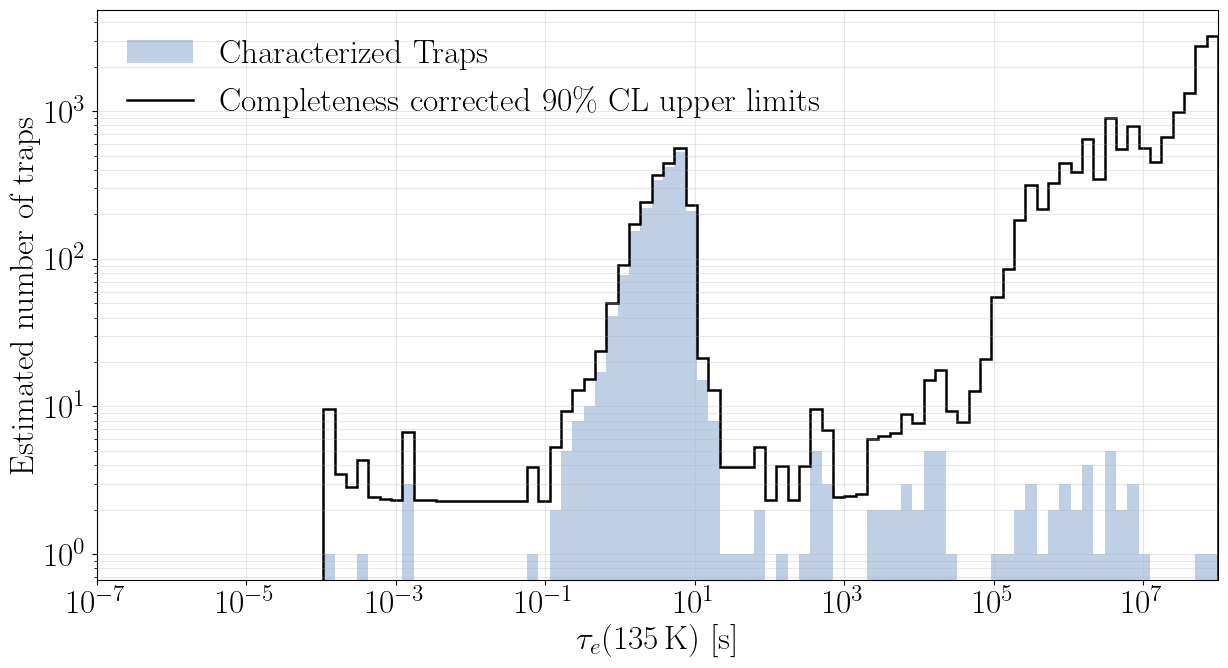

Applied 90% Poisson upper limits to all bins before completeness correction.
Saved: c:\Users\Ansh\Projects\sensei_charge_traps\figures\tau_at_135k_hist_upper_limit.pdf


In [16]:
from scipy.stats import gamma

# Correct the total 135 K histogram using the conditional-completeness curve.
# Empty bins use the one-sided 90% Poisson upper limit for zero observed events.
confidence_level = 0.90
tau_bin_centers = np.sqrt(tau_edges[:-1] * tau_edges[1:])

# Interpolate in log(tau), matching the logarithmic x axis and histogram bins.
completeness_at_bins = np.interp(
    np.log10(tau_bin_centers),
    np.log10(tau_grid),
    default_curve,
    left=np.nan,
    right=np.nan,
)

min_efficiency = 0#0.05
correction_tau_min = 1e-4   # seconds
correction_tau_max = 1e10    # seconds

valid_efficiency = (
    np.isfinite(completeness_at_bins)
    & (completeness_at_bins >= min_efficiency)
    & (tau_bin_centers >= correction_tau_min)
    & (tau_bin_centers <= correction_tau_max)
)

print(
    f"Excluded {np.sum(~valid_efficiency)} bins "
    f"with completeness below {min_efficiency:.0%} or outside the model grid."
)

# nonempty = (tau_hist > 0) & valid_efficiency
# empty = (tau_hist == 0) & valid_efficiency

# Calculate the one-sided Poisson upper limit for every bin.
raw_upper_limits = gamma.ppf(confidence_level, tau_hist + 1)

corrected_tau_hist = np.full(tau_hist.shape, np.nan, dtype=float)
corrected_tau_hist[valid_efficiency] = (
    raw_upper_limits[valid_efficiency]
    / completeness_at_bins[valid_efficiency]
)

print(f'number of total traps after corrections: {np.nansum(corrected_tau_hist)}')
print(f'scal of total traps after corrections: {np.nansum(corrected_tau_hist)/5171}')

bad = ~np.isfinite(corrected_tau_hist)

for i in np.flatnonzero(bad):
    print(
        f"bin {i}: "
        f"[{tau_edges[i]:.3e}, {tau_edges[i + 1]:.3e}] s, "
        f"center={tau_bin_centers[i]:.3e}, "
        f"efficiency={completeness_at_bins[i]}"
    )


corrected_tau_hist[~valid_efficiency] = 0.0

assert np.all(np.isfinite(corrected_tau_hist)), (
    "Simulation histogram contains NaN or infinite values"
)


upper_limit_path = repo / "tau_at_135k_hist_upper_limit.npz"

valid_indices = np.flatnonzero(valid_efficiency)
first, last = valid_indices[0], valid_indices[-1]

np.savez(
    upper_limit_path,
    hist=corrected_tau_hist[first:last + 1],
    bin_edges=tau_edges[first:last + 2],
)

print(f"Saved: {upper_limit_path}")


fig, ax = plt.subplots(figsize=(16 * 0.8, 9 * 0.8))
ax.stairs(
    tau_hist,
    tau_edges,
    color=C_BLUE,
    linewidth=1.8,
    fill=True,
    alpha=0.25,
    label="Characterized Traps",
)
ax.stairs(
    corrected_tau_hist,
    tau_edges,
    color="black",
    linewidth=1.8,
    label="Completeness corrected 90\% CL upper limits",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(tau_edges[0], tau_edges[-1])
ax.set_xlabel("$\\tau_e(135\\,\\mathrm{K})$ [s]")
ax.set_ylabel("Estimated number of traps")
ax.legend(frameon=False, fontsize=small)
ax.grid(True, which="both", alpha=0.3)

output_path = repo / "figures" / "tau_at_135k_hist_upper_limit.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(
    f"Applied {confidence_level:.0%} Poisson upper limits "
    "to all bins before completeness correction."
)
print(f"Saved: {output_path}")
# valid_centers = tau_bin_centers[valid_efficiency]
# print("Correction range:", valid_centers.min(), "to", valid_centers.max(), "seconds")

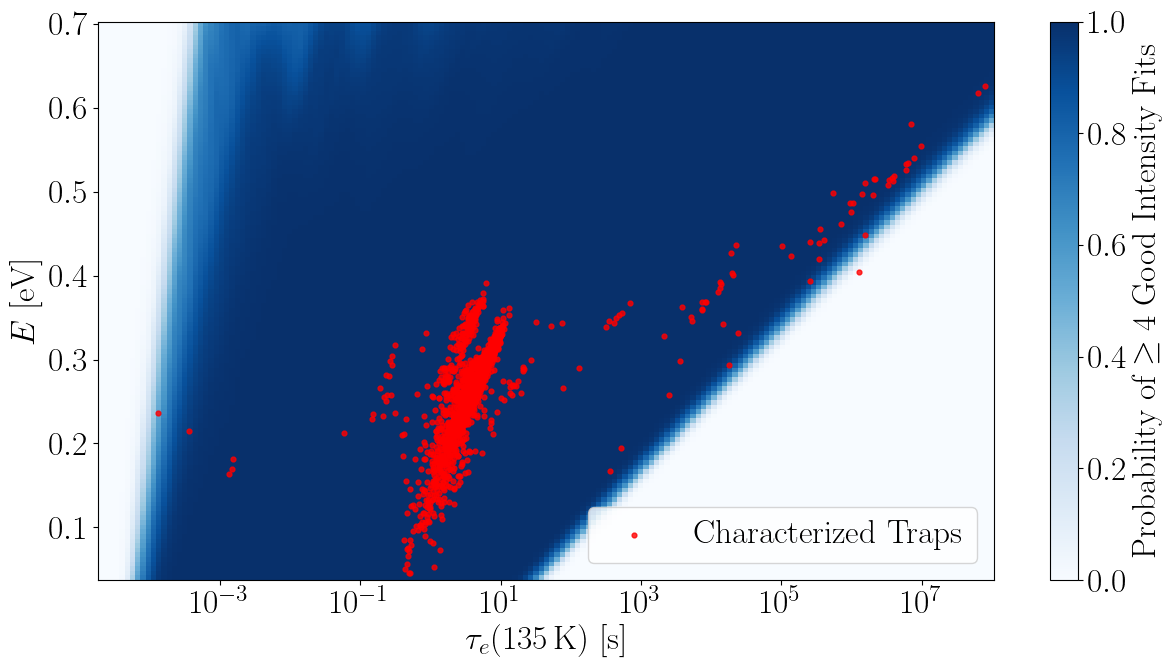

Unbounded grid fraction: 0.15238509496882702
E range: 0.04 to 0.4745 eV
tau_135 range: 177.0571976798964 to 100000000.0 s
max P4 in unbounded regime: 0.0


In [24]:
fig, ax = plt.subplots(figsize=(16*0.8, 9*0.8))
mesh = ax.pcolormesh(tau_grid, E_grid, p4_map.T, shading="auto", cmap="Blues", vmin=0, vmax=1)
# ax.contour(tau_grid, E_grid, all_oob.T.astype(float), levels=[0.5], colors="white", linewidths=1.5,label='Boundary')
ax.scatter(known_tau, known_E, s=12, c="red", alpha=0.8, label="Characterized Traps")
ax.set_xscale("log")
ax.set_xlabel("$\\tau_e(135\,\mathrm{K})$ [s]")
ax.set_ylabel("$E$ [eV]")
# ax.set_title("map with known traps and all-out-of-band contour")
fig.colorbar(mesh, ax=ax, label="Probability of $\ge4$ Good Intensity Fits")
ax.legend(loc="lower right")
plt.savefig('figures/prob_of_measuring.pdf',dpi=300)

plt.show()

unbounded = summary["unbounded_regime"]["all_temperatures_out_of_stage08_tau_band"]
print("Unbounded grid fraction:", unbounded["grid_fraction"])
print("E range:", unbounded["E_eV_min"], "to", unbounded["E_eV_max"], "eV")
print("tau_135 range:", unbounded["tau_135_seconds_min"], "to", unbounded["tau_135_seconds_max"], "s")
print("max P4 in unbounded regime:", unbounded["p4_max_in_regime"])


Direct good 135 K tau fits: 242
Extrapolated-only tau_135 values: 1893
Median tau_135 direct 135 K: 1.7365230006034342
Median tau_135 extrapolated-only: 4.91699633961438


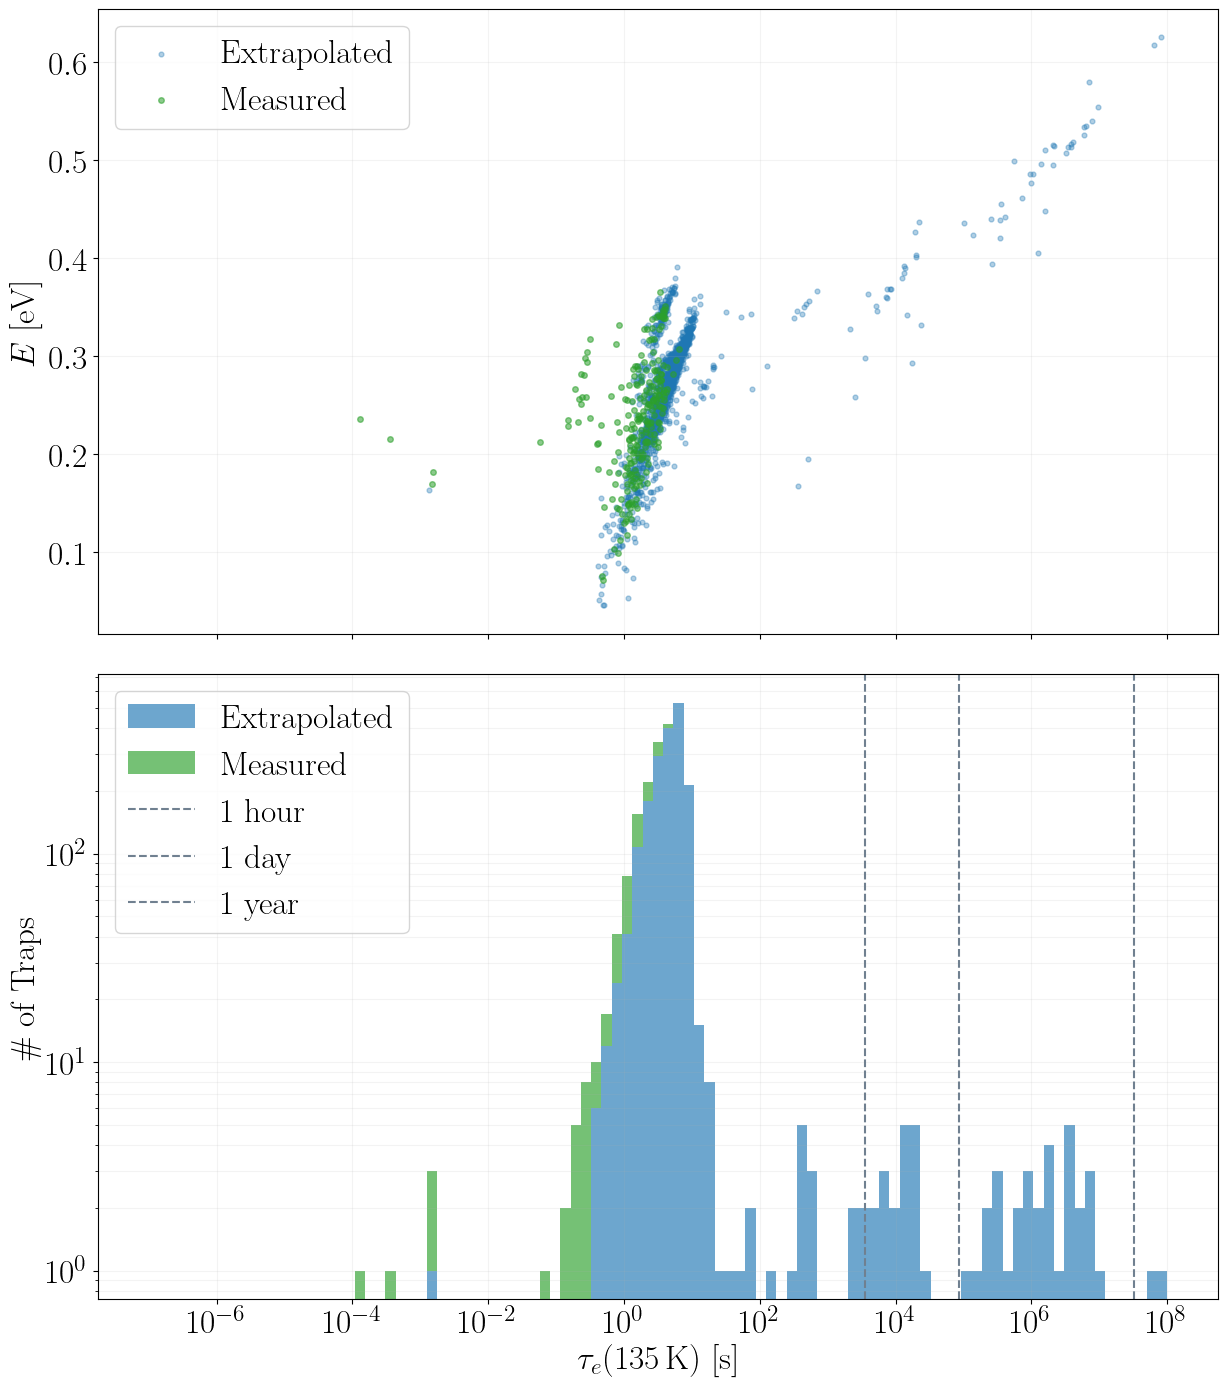

In [18]:
def parse_bool(value):
    return str(value).strip().lower() in {"true", "1", "yes"}


tau_135_records = []
E_records = []
measured_135 = []
with records4_path.open(newline="") as handle:
    for row in csv.DictReader(handle):
        tau_135_records.append(float(row["tau_135_seconds"]))
        E_records.append(float(row["E_eV"]))
        measured_135.append(parse_bool(row["tau_135_good_intensity_fit"]))

tau_135_records = np.asarray(tau_135_records, dtype=float)
E_records = np.asarray(E_records, dtype=float)
measured_135 = np.asarray(measured_135, dtype=bool)
extrapolated_135 = ~measured_135

print(f"Direct good 135 K tau fits: {int(measured_135.sum())}")
print(f"Extrapolated-only tau_135 values: {int(extrapolated_135.sum())}")
print("Median tau_135 direct 135 K:", np.median(tau_135_records[measured_135]))
print("Median tau_135 extrapolated-only:", np.median(tau_135_records[extrapolated_135]))

fig, (ax_scatter, ax_hist) = plt.subplots(
    2,
    1,
    figsize=(16*0.8, 2*9*0.8),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.0]},
)

ax_scatter.scatter(
    tau_135_records[extrapolated_135],
    E_records[extrapolated_135],
    s=12,
    alpha=0.35,
    color="tab:blue",
    label="Extrapolated",
)
ax_scatter.scatter(
    tau_135_records[measured_135],
    E_records[measured_135],
    s=16,
    alpha=0.55,
    color="tab:green",
    label="Measured",
)
ax_scatter.set_xscale("log")
ax_scatter.set_ylabel("$E$ [eV]")
# ax_scatter.set_title("Direct 135 K measurements and extrapolated tau_135 in energy space")
ax_scatter.legend(fontsize=small, loc="best")
ax_scatter.grid(True, which="both", alpha=0.15)

hist_bins = tau_edges
ax_hist.hist(
    [tau_135_records[extrapolated_135], tau_135_records[measured_135]],
    bins=hist_bins,
    stacked=True,
    color=["tab:blue", "tab:green"],
    alpha=0.65,
    label=["Extrapolated", "Measured"],
)
ax_hist.set_xscale("log")
ax_hist.set_yscale("log")
ax_hist.set_xlabel("$\\tau_e(135\,\mathrm{K})$ [s]")
ax_hist.set_ylabel("\# of Traps")
ax_hist.grid(True, which="both", alpha=0.15)
ax_hist.axvline(3600,label='1 hour',ls='--',color=C_REF)
ax_hist.axvline(3600*24,label='1 day',ls='--',color=C_REF)
ax_hist.axvline(3600*25*365.25,label='1 year',ls='--',color=C_REF)
ax_hist.legend(fontsize=small, loc="best")

plt.tight_layout()
plt.show()


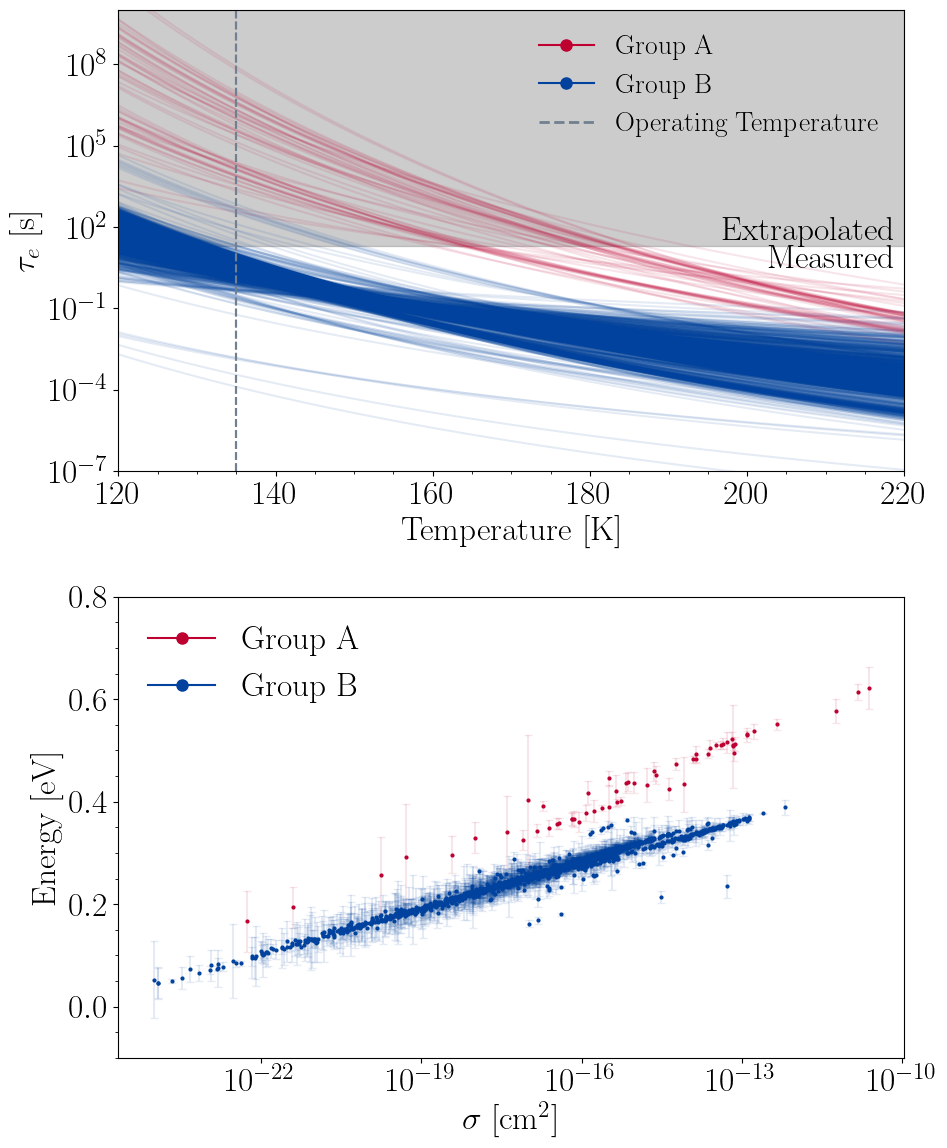

In [19]:
max_tau = 0
for t in range(len(tau_temp_fits)):
    tau = tau_temp_fits[t][1]
    if max_tau < np.max(tau):
        max_tau = np.max(tau)


fig, ax= plt.subplots(2,figsize=(10,12))
fit_temp = np.linspace(120,220,100)

cmap = plt.cm.plasma
cross_sections = np.array(energy_crossSections)[:,0]
log_cross_sections = np.log(cross_sections)


#decision_boundary
# m = 0.014  
# b = 0.85 
T = 170 #histogram
kb = 8.6717333262e-5
m =  (kb*T)
tau_test = 1
# tau_test = 0.00002
# np.log(0.00002)
b = m * (np.log(tau_test) - (-68.267 ) + 2 * np.log(m))


T2 = 130
m2 =  (kb*T2)
b2 = m2 * (np.log(tau_test) - (-68.267 ) + 2 * np.log(m2))

# plt.plot(x_vals, m * x_vals + b, linestyle='--', label=f'{T}K')




avg_A = []
avg_B = []
avg_C = []

# print(len(energies),len(energy_crossSections))
norm = colors.LogNorm(vmin=np.min(cross_sections),vmax=np.max(cross_sections))
for d,data in enumerate(energy_crossSections):
    temperatures = tau_temp_fits[d][0]
    taus = tau_temp_fits[d][1]
    tau_errs = tau_temp_fits[d][2]
    energy = data[1]
    cs = data[0]
    avgtemp = data[4]
    if energy > (m * np.log(cs) + b):
        color =C_RED
        # color ='c'
        avg_A.append(avgtemp)
    # elif energy < (m2 * np.log(cs) + b2):
    #     color = '#FFB000'
    #     # color = 'm'
    #     avg_C.append(avgtemp)
    else:
        color = C_BLUE
        # color = 'tab:blue'

        # color = 'y'
        avg_B.append(avgtemp)


    # color = cmap(d)
    # color = cmap(norm(cs))

    log_tau_fit = log_energy_cross_section(fit_temp,data[1],np.log(data[0]))
    tau_fit = np.exp(log_tau_fit)
    ax[0].plot(fit_temp,tau_fit,color=color,alpha=0.1)
    # ax[0].scatter(temperatures,taus,color=color,s=9)
    # ax[0].errorbar(temperatures,taus,yerr=tau_errs,color=color,ls="None",capsize=1)
    # ax[1].scatter(data[0],data[1],color=color,s=9)
    # ax[1].errorbar(data[0],data[1],xerr=data[2],yerr=data[3],ls='None',color=C_REF,alpha=0.1,capsize=3)
 
    
    line, caps, bars = ax[1].errorbar(data[0],data[1],yerr=data[3],ls='None',color=color,capsize=3,marker='o',markersize=2)
    for bar in bars:
        bar.set_alpha(0.1)

    for cap in caps:
        cap.set_alpha(0.1)


ax[0].text(219,3.16e1,"Extrapolated",fontsize=small,ha='right')
ax[0].text(219,3.16,"Measured",fontsize=small,ha='right')

ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[0].fill_between(fit_temp,np.ones_like(fit_temp)*max_tau,np.ones_like(fit_temp)*1e10,color='grey',alpha=0.4)
ax[0].set_ylim(1e-7,1e10)
ax[0].set_xlim(120,220)

ax[0].set_xlabel("Temperature [K]",fontsize=small)
ax[0].set_ylabel("$\\tau_e$ [s]",fontsize=small)

ax[1].set_xlabel("$\sigma$ [cm$^2$]",fontsize=small)
ax[1].set_ylabel("Energy [eV]",fontsize=small)
ax[1].set_ylim(-0.1,0.8)
ax[0].axvline(135,ls='--',label='Operating Temperature',color=C_REF)

ax[1].set_xlabel("$\sigma$ [cm$^2$]",fontsize=small)
ax[1].set_ylabel("Energy [eV]",fontsize=small)
ax[1].set_ylim(-0.1,0.8)
ax[0].axvline(135,ls='--',label='Operating Temperature',color=C_REF)
ax[0].minorticks_on()
ax[1].minorticks_on()

# --- Add this block to create and display custom legend handles ---
custom_handles = [
    Line2D([0], [0], marker='o', color=C_RED, markerfacecolor=C_RED, markersize=8, label='Group A'),
    Line2D([0], [0], marker='o', color=C_BLUE, markerfacecolor=C_BLUE, markersize=8, label='Group B'),
    # Line2D([0], [0], marker='o', color='#FFB000', markerfacecolor='#FFB000', markersize=8, label='Group C'),
    Line2D([0], [0], linestyle='--', color=C_REF, lw=2, label='Operating Temperature')

]

custom_handles2 = [
    Line2D([0], [0], marker='o', color=C_RED, markerfacecolor=C_RED, markersize=8, label='Group A'),
    Line2D([0], [0], marker='o', color=C_BLUE, markerfacecolor=C_BLUE, markersize=8, label='Group B'),
    # Line2D([0], [0], marker='o', color='#FFB000', markerfacecolor='#FFB000', markersize=8, label='Group C'),

]
# custom_handles = custom_handles +  obs_handle
# Add the legend to the bottom plot (ax[1])
ax[0].legend(handles=custom_handles, loc='best', fontsize=smaller,frameon=False)
ax[1].legend(handles=custom_handles2, loc='best', fontsize=small,frameon=False)
# --

# fig.suptitle("Characterized Charge Traps",fontsize=24,y=0.92)
# plt.tight_layout()
# sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])  # Required for ScalarMappable to work correctly
# cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
# cbar = fig.colorbar(sm, cax=cbar_ax)
# cbar.set_label('$\sigma$ [cm$^2$]',fontsize=16)
plt.savefig('figures/characterized_traps.pdf',dpi=300)

plt.show()
plt.close()

In [20]:
len(avg_A),len(avg_B),len(avg_C)

(57, 2078, 0)

242
1893


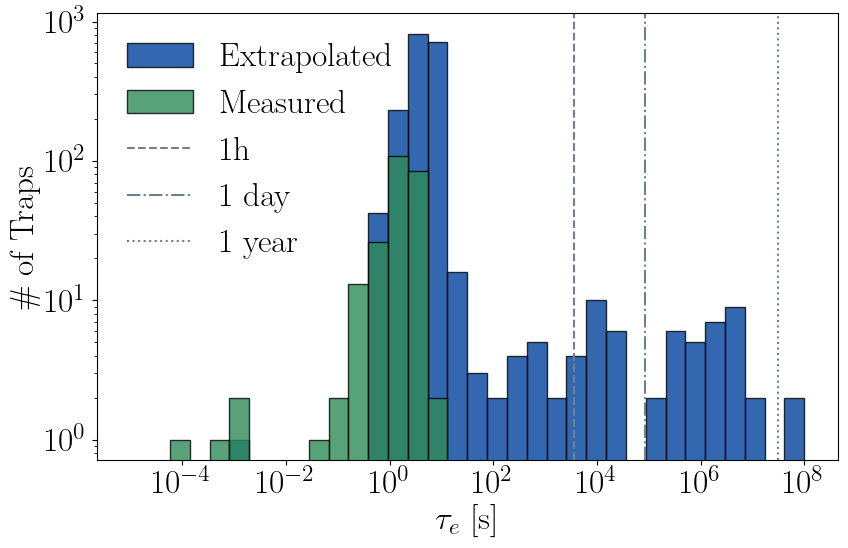

In [21]:
import hist
from hist import Hist
# fig,ax = plt.subplots(1,2,figsize=(14,6))

# for t in tau_temperatures.keys():
t = 135
fig = plt.figure(figsize=(9,6))
ax = plt.gca()
measured_taus = tau_temperatures[t]['measured']
extrapolated_taus = tau_temperatures[t]['extrapolated']

print(len(measured_taus))
print(len(extrapolated_taus))
minbin = np.min([np.min(measured_taus),np.min(extrapolated_taus)])
maxbin = np.max([np.max(measured_taus),np.max(extrapolated_taus)])

bins = np.geomspace(1e-5,1e8,35)

# mhist= Hist.new.Log(200, minbin, maxbin, name="Measured Emission Times").Weight()
# ehist= Hist.new.Log(200, minbin, maxbin, name="Extrapolated Emission Times").Weight()

# mhist.fill(measured_taus)
# ehist.fill(extrapolated_taus)

# mhist,mbins = np.histogram(measured_taus,bins=bins)
# ehist,ebins = np.histogram(extrapolated_taus,bins=bins)

# plt.stairs(mhist,mbins,color='blue',label='measured',lw=2)
# plt.stairs(ehist,ebins,color='grey',label='extrapolated',lw=2)
# mhist.plot1d(ax=ax[0],histtype='fill',yerr=False)
# ehist.plot1d(ax=ax[1],histtype='fill',yerr=False)


# ax.hist(measured_taus+extrapolated_taus, bins, color=C_REF, edgecolor='black', alpha=1,label='Total')
ax.hist(extrapolated_taus, bins, color=C_BLUE, edgecolor='black', alpha=0.8,label='Extrapolated')
ax.hist(measured_taus, bins, color='seagreen', edgecolor='black', alpha=0.8,label='Measured')


# ax.legend(fontsize=16)
# ax.set_title(f"Emission $\\tau_e$ of CCD Traps at {t}k",fontsize=20)
# ax[1].set_title("Extrapolated Emission $\\tau_e$ of CCD Traps at 135k",fontsize=20)
# for a in ax:
ax.set_xlabel('$\\tau_e$ [s]',fontsize=small)
ax.set_ylabel("\# of Traps",fontsize=small)
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_ylim(0,500)
# ax[0].set_ylim(0,50)
plt.axvline(3600,label='1h',ls='--',color=C_REF)
plt.axvline(3600*24,label='1 day',ls='-.',color=C_REF)
plt.axvline(3600*24*365,label='1 year',ls=':',color=C_REF)
ax.legend(frameon=False,loc='upper left')
ax.minorticks_on()
plt.savefig(f'figures/tau_at_{t}k_hist.pdf',dpi=300)
plt.show()
plt.close()

In [114]:


for t in tau_temperatures.keys():
    measured_taus = tau_temperatures[t]['measured']
    extrapolated_taus = tau_temperatures[t]['extrapolated']
    
    # The 'Truth' or total number of traps is the sum of both lists
    total_taus = measured_taus + extrapolated_taus
    
    if len(total_taus) == 0:
        continue
        
    print(f"Temperature: {t}K | Measured: {len(measured_taus)} | Extrapolated: {len(extrapolated_taus)}")

    # Set up a 2-panel plot (Top for Histogram, Bottom for Efficiency)
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    ax_hist = axes[0]
    ax_eff = axes[1]
    
    bins = np.geomspace(1e-7, 1e8, 100)

    # 1. Plot the Standard Histograms (Top Panel)
    # Using stacked=True is often better here so "Measured" sits on top of "Extrapolated" to show the Total
    ax_hist.hist([measured_taus, extrapolated_taus], bins=bins, stacked=True, 
                 color=['seagreen', C_BLUE], edgecolor='black', alpha=0.8, 
                 label=['Measured', 'Extrapolated'])

    ax_hist.set_title(f"Emission $\\tau_e$ of CCD Traps at {t}K", fontsize=20)
    ax_hist.set_ylabel("\# of Traps", fontsize=16)
    
    ax_hist.axvline(3600, label='1h', ls='--', color=C_REF)
    ax_hist.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
    ax_hist.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)
    ax_hist.legend(frameon=False, fontsize=16)

    # 2. Calculate the Efficiency (Bottom Panel)
    # Bin the data manually to do the math
    meas_counts, _ = np.histogram(measured_taus, bins=bins)
    extrap_counts, _ = np.histogram(extrapolated_taus, bins=bins)
    tot_counts, _ = np.histogram(total_taus, bins=bins)
    
    # Avoid division by zero warnings
    with np.errstate(divide='ignore', invalid='ignore'):
        efficiency = meas_counts / tot_counts
        
    # Find the geometric centers of the bins for plotting the scatter points
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
    # Calculate simple binomial errors for the efficiency
    eff_err = np.zeros_like(efficiency)
    valid = tot_counts > 0
    eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
    # Plot the efficiency points with error bars
    ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
                    fmt='o', color='black', markersize=5, capsize=3)
    
    # Formatting the Efficiency Panel
    ax_eff.set_xlabel('$\\tau_e$ [s]', fontsize=small)
    ax_eff.set_ylabel("Efficiency $\\epsilon$", fontsize=small)
    ax_eff.set_xscale('log')
    ax_eff.set_ylim(-0.1, 1.1)
    ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
    ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
    ax_eff.grid(True, which='both', axis='x', alpha=0.2)

    ax_eff.set_xticks(np.logspace(-8,8,17))
    ax_eff.minorticks_on()

    ax_eff.axvline(1e0,ls='--',color=C_REF)
    
    plt.tight_layout()
    # if t == 135:
    plt.savefig(f'figures/tau_at_{t}k_hist.pdf',dpi=300)
    # plt.show()
    plt.close()

    # 3. Save the data individually for this specific temperature
    filename = f'tau_at_{t}k_hist.npz'
    np.savez(filename, 
             hist=tot_counts,           # Loaded as 'tau_weights' in run_ccd_simulation.py
             bin_edges=bins,            # Loaded as 'tau_edges' in run_ccd_simulation.py
             measured_taus=measured_taus,
             extrapolated_taus=extrapolated_taus,
             total_taus=total_taus,
             meas_counts=meas_counts,
             extrap_counts=extrap_counts,
             efficiency=efficiency,
             eff_err=eff_err)
    
    print(f"Saved {filename} for simulation sampling.")


Temperature: 125K | Measured: 20 | Extrapolated: 2115
Saved tau_at_125k_hist.npz for simulation sampling.
Temperature: 130K | Measured: 33 | Extrapolated: 2102
Saved tau_at_130k_hist.npz for simulation sampling.
Temperature: 135K | Measured: 242 | Extrapolated: 1893
Saved tau_at_135k_hist.npz for simulation sampling.
Temperature: 140K | Measured: 1177 | Extrapolated: 958
Saved tau_at_140k_hist.npz for simulation sampling.
Temperature: 145K | Measured: 1924 | Extrapolated: 211
Saved tau_at_145k_hist.npz for simulation sampling.
Temperature: 150K | Measured: 2026 | Extrapolated: 109
Saved tau_at_150k_hist.npz for simulation sampling.
Temperature: 155K | Measured: 1987 | Extrapolated: 148
Saved tau_at_155k_hist.npz for simulation sampling.
Temperature: 160K | Measured: 1695 | Extrapolated: 440
Saved tau_at_160k_hist.npz for simulation sampling.
Temperature: 165K | Measured: 1136 | Extrapolated: 999
Saved tau_at_165k_hist.npz for simulation sampling.
Temperature: 170K | Measured: 739 | Ext

Total Traps Measured: 15233
Total Traps Extrapolated: 33872


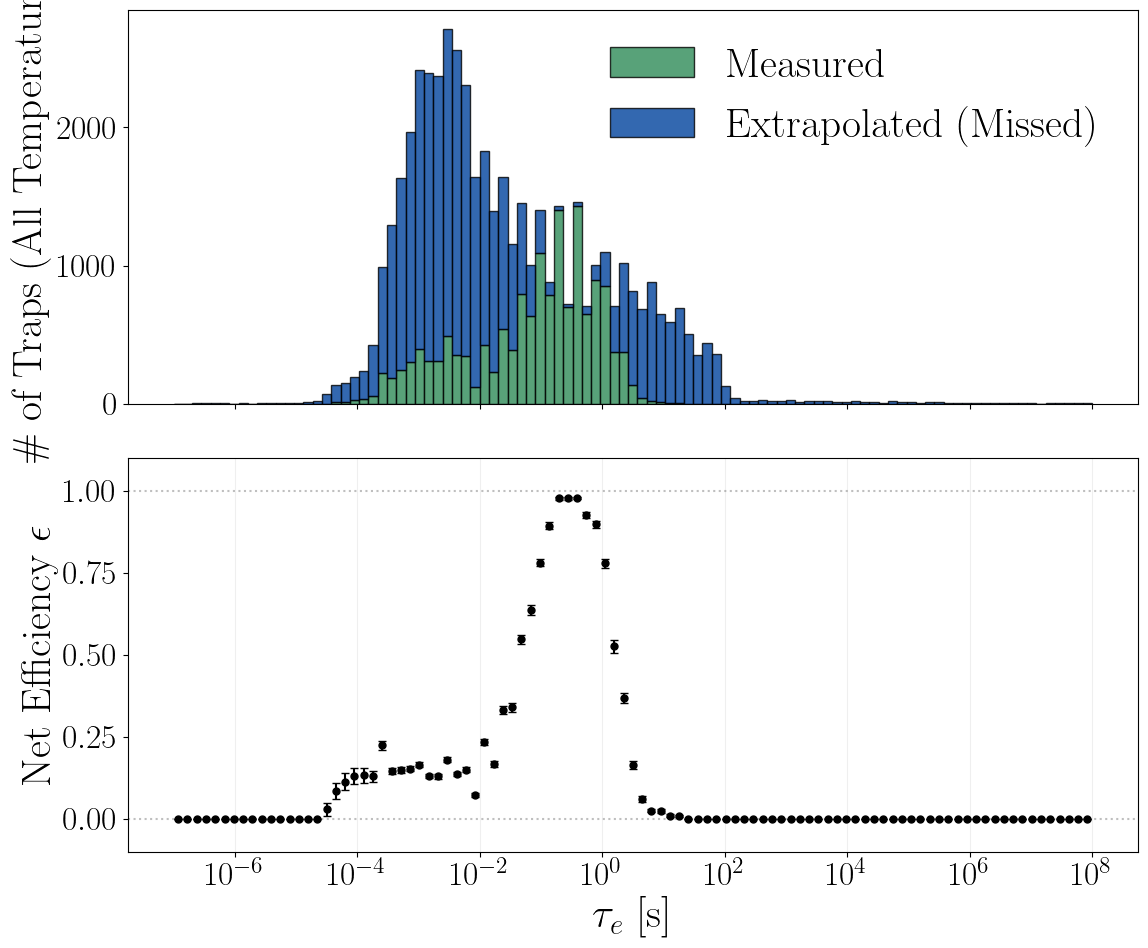

In [ ]:


# # 1. Aggregate data across all temperatures
# all_measured_taus = []
# all_extrapolated_taus = []

# for t in tau_temperatures.keys():
#     all_measured_taus.extend(tau_temperatures[t]['measured'])
#     all_extrapolated_taus.extend(tau_temperatures[t]['extrapolated'])

# all_total_taus = all_measured_taus + all_extrapolated_taus

# print(f"Total Traps Measured: {len(all_measured_taus)}")
# print(f"Total Traps Extrapolated: {len(all_extrapolated_taus)}")

# if len(all_total_taus) > 0:
#     # 2. Set up the Two-Panel Plot
#     fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]}, sharex=True)
#     ax_hist = axes[0]
#     ax_eff = axes[1]
    
#     # bins = np.geomspace(1e-7, 1e8, 75)

#     # --- Top Panel: Stacked Histogram ---
#     ax_hist.hist([all_measured_taus, all_extrapolated_taus], bins=bins, stacked=True, 
#                  color=['seagreen', C_BLUE], edgecolor='black', alpha=0.8, 
#                  label=['Measured', 'Extrapolated (Missed)'])

#     # ax_hist.set_title("Net Emission $\\tau_e$ of CCD Traps (All Temperatures Integrated)", fontsize=20)
#     ax_hist.set_ylabel("\\# of Traps (All Temperatures)", fontsize=medium)
#     # ax_hist.set_yscale('log')
    
#     # ax_hist.axvline(3600, label='1h', ls='--', color=C_REF)
#     # ax_hist.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
#     # ax_hist.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)
#     ax_hist.legend(frameon=False, fontsize=medium)

#     # --- Bottom Panel: Net Efficiency ---
#     meas_counts, _ = np.histogram(all_measured_taus, bins=bins)
#     tot_counts, _ = np.histogram(all_total_taus, bins=bins)
    
#     # Safely calculate efficiency
#     with np.errstate(divide='ignore', invalid='ignore'):
#         efficiency = meas_counts / tot_counts
        
#     bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
#     # Calculate binomial errors
#     eff_err = np.zeros_like(efficiency)
#     valid = tot_counts > 0
#     eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
#     ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
#                     fmt='o', color='black', markersize=5, capsize=3)
    
#     # Formatting
#     ax_eff.set_xlabel('$\\tau_e$ [s]', fontsize=medium)
#     ax_eff.set_ylabel("Net Efficiency $\\epsilon$", fontsize=medium)
#     ax_eff.set_xscale('log')
#     ax_eff.set_ylim(-0.1, 1.1)
#     ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
#     ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
#     ax_eff.grid(True, which='both', axis='x', alpha=0.2)

#     plt.tight_layout()
    
#     plt.show()
#     plt.close()
# else:
#     print("No data available to plot.")


Total Traps Measured: 15233
Total Traps Extrapolated: 33872


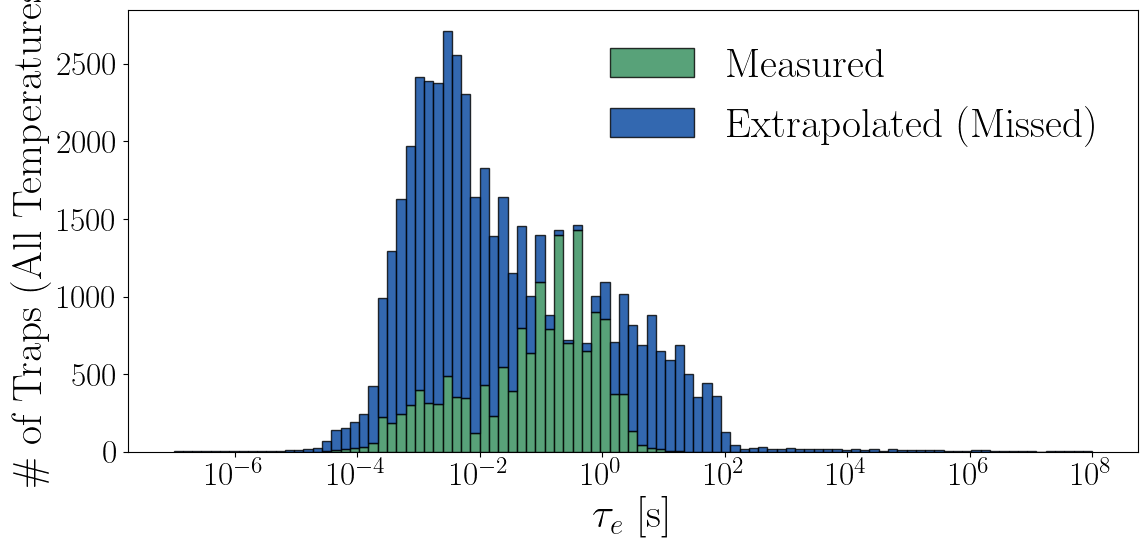

In [ ]:


# # 1. Aggregate data across all temperatures
# all_measured_taus = []
# all_extrapolated_taus = []

# for t in tau_temperatures.keys():
#     all_measured_taus.extend(tau_temperatures[t]['measured'])
#     all_extrapolated_taus.extend(tau_temperatures[t]['extrapolated'])

# all_total_taus = all_measured_taus + all_extrapolated_taus

# print(f"Total Traps Measured: {len(all_measured_taus)}")
# print(f"Total Traps Extrapolated: {len(all_extrapolated_taus)}")

# if len(all_total_taus) > 0:
#     # 2. Set up the Two-Panel Plot
#     # fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]}, sharex=True)
#     fig = plt.figure(figsize=(12,6))
#     ax_hist = plt.gca()
#     # ax_eff = axes[1]
    
#     # bins = np.geomspace(1e-7, 1e8, 50)

#     # --- Top Panel: Stacked Histogram ---
#     ax_hist.hist([all_measured_taus, all_extrapolated_taus], bins=bins, stacked=True, 
#                  color=['seagreen', C_BLUE], edgecolor='black', alpha=0.8, 
#                  label=['Measured', 'Extrapolated (Missed)'])

#     # ax_hist.set_title("Net Emission $\\tau_e$ of CCD Traps (All Temperatures Integrated)", fontsize=20)
#     ax_hist.set_ylabel("\\# of Traps (All Temperatures)", fontsize=medium)
#     ax_hist.set_xscale('log')
    
#     # ax_hist.axvline(3600, label='1h', ls='--', color=C_REF)
#     # ax_hist.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
#     # ax_hist.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)
#     ax_hist.legend(frameon=False, fontsize=medium)

#     # --- Bottom Panel: Net Efficiency ---
#     # meas_counts, _ = np.histogram(all_measured_taus, bins=bins)
#     # tot_counts, _ = np.histogram(all_total_taus, bins=bins)
    
#     # Safely calculate efficiency
#     # with np.errstate(divide='ignore', invalid='ignore'):
#         # efficiency = meas_counts / tot_counts
        
#     bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
#     # # Calculate binomial errors
#     # eff_err = np.zeros_like(efficiency)
#     # valid = tot_counts > 0
#     # eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
#     # ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
#     #                 fmt='o', color='black', markersize=5, capsize=3)
    
#     # # Formatting
#     ax_hist.set_xlabel('$\\tau_e$ [s]', fontsize=medium)
#     # ax_eff.set_ylabel("Net Efficiency $\\epsilon$", fontsize=medium)
#     # ax_eff.set_xscale('log')
#     # ax_eff.set_ylim(-0.1, 1.1)
#     # ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
#     # ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
#     # ax_eff.grid(True, which='both', axis='x', alpha=0.2)

#     plt.tight_layout()
    
#     plt.show()
#     plt.close()
# else:
#     print("No data available to plot.")


Total Traps Measured: 15233
Total Traps Extrapolated: 33872


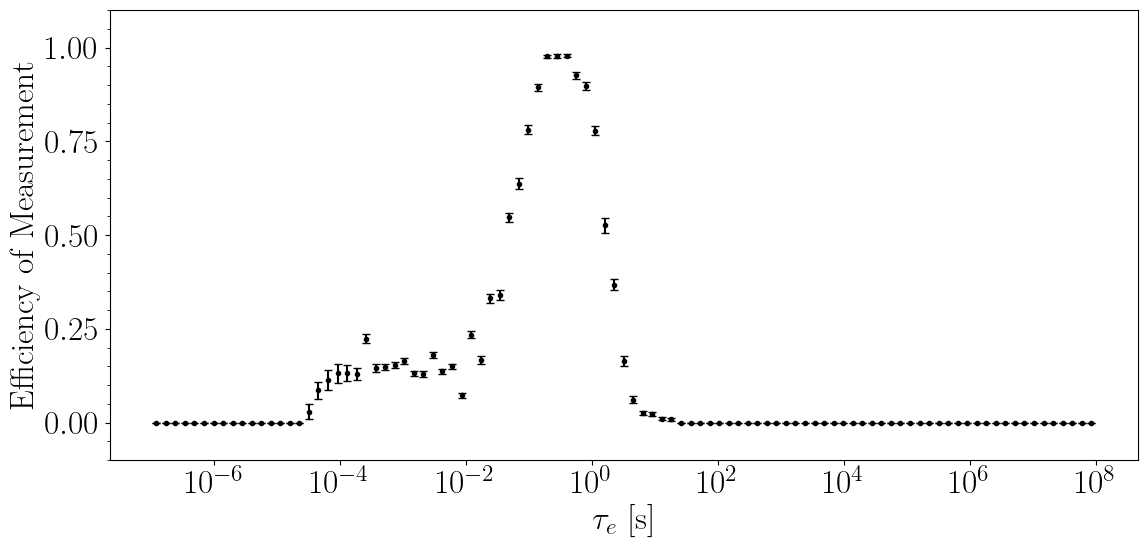

In [117]:

# 1. Aggregate data across all temperatures
all_measured_taus = []
all_extrapolated_taus = []

for t in tau_temperatures.keys():
    all_measured_taus.extend(tau_temperatures[t]['measured'])
    all_extrapolated_taus.extend(tau_temperatures[t]['extrapolated'])

all_total_taus = all_measured_taus + all_extrapolated_taus

print(f"Total Traps Measured: {len(all_measured_taus)}")
print(f"Total Traps Extrapolated: {len(all_extrapolated_taus)}")

if len(all_total_taus) > 0:
    # 2. Set up the Two-Panel Plot
    # fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]}, sharex=True)
    fig = plt.figure(figsize=(12,6))
    # ax_hist = plt.gca()
    ax_eff =  plt.gca()
    
    # bins = np.geomspace(1e-7, 1e8, 75)

    # --- Top Panel: Stacked Histogram ---
    # ax_hist.hist([all_measured_taus, all_extrapolated_taus], bins=bins, stacked=True, 
                #  color=['seagreen', C_BLUE], edgecolor='black', alpha=0.8, 
                #  label=['Measured', 'Extrapolated (Missed)'])

    # ax_hist.set_title("Net Emission $\\tau_e$ of CCD Traps (All Temperatures Integrated)", fontsize=20)
    # ax_hist.set_ylabel("\\# of Traps (All Temperatures)", fontsize=medium)
    ax_eff.set_xscale('log')
    
    # ax_hist.axvline(3600, label='1h', ls='--', color=C_REF)
    
    # ax_hist.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
    # ax_hist.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)
    # ax_hist.legend(frameon=False, fontsize=medium)

    # --- Bottom Panel: Net Efficiency ---
    meas_counts, _ = np.histogram(all_measured_taus, bins=bins)
    tot_counts, _ = np.histogram(all_total_taus, bins=bins)
    
    # Safely calculate efficiency
    with np.errstate(divide='ignore', invalid='ignore'):
        efficiency = meas_counts / tot_counts
        
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    
    # Calculate binomial errors
    eff_err = np.zeros_like(efficiency)
    valid = tot_counts > 0
    eff_err[valid] = np.sqrt(efficiency[valid] * (1.0 - efficiency[valid]) / tot_counts[valid])
    
    ax_eff.errorbar(bin_centers[valid], efficiency[valid], yerr=eff_err[valid], 
                    fmt='o', color='black', markersize=3, capsize=3)
    
    # # Formatting
    ax_eff.set_xlabel('$\\tau_e$ [s]', fontsize=small)
    ax_eff.set_ylabel("Efficiency of Measurement", fontsize=small)
    ax_eff.set_xscale('log')
    ax_eff.set_ylim(-0.1, 1.1)
    ax_eff.minorticks_on()
    # ax_eff.axhline(1.0, color='grey', ls=':', alpha=0.5)
    # ax_eff.axhline(0.0, color='grey', ls=':', alpha=0.5)
    # ax_eff.grid(True, which='both', axis='x', alpha=0.2)

    plt.tight_layout()
    plt.savefig('figures/efficiency_tau_curve.pdf',dpi=300)
    plt.show()
    plt.close()
else:
    print("No data available to plot.")


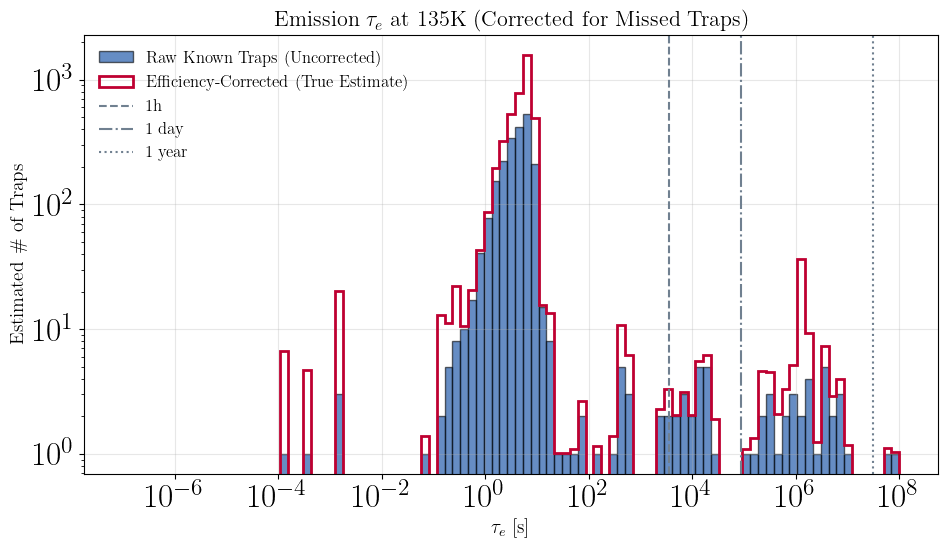

In [118]:

# ====================================================================
# 1. Build the Universal "Master Efficiency Curve"
# ====================================================================
all_measured = []
all_extrapolated = []
for t in tau_temperatures.keys():
    all_measured.extend(tau_temperatures[t]['measured'])
    all_extrapolated.extend(tau_temperatures[t]['extrapolated'])

all_total = all_measured + all_extrapolated
# bins = np.geomspace(1e-7, 1e8, 75)

meas_counts, _ = np.histogram(all_measured, bins=bins)
tot_counts, _ = np.histogram(all_total, bins=bins)

# Calculate efficiency safely
with np.errstate(divide='ignore', invalid='ignore'):
    master_efficiency = meas_counts / tot_counts
    
bin_centers = np.sqrt(bins[:-1] * bins[1:])

# Create a safe trust window (only trust regions with > 5% efficiency)
trust_mask = (master_efficiency > 0.05) & (~np.isnan(master_efficiency))

# Create a continuous interpolation function for the efficiency
# master_eff_func = interp1d(
#     bin_centers[trust_mask], 
#     master_efficiency[trust_mask], 
#     kind='linear', 
#     bounds_error=False, 
#     fill_value=np.nan
# )

master_eff_func = interp1d(
    bin_centers, 
    master_efficiency, 
    kind='linear', 
    bounds_error=False, 
    fill_value=np.nan
)

# ====================================================================
# 2. Weight every characterized trap based on where it was observed
# ====================================================================
target_temp = 135.0

tau_target_list = []
weights_list = []

for d, data in enumerate(energy_crossSections):
    cs = data[0]
    energy = data[1]
    avgtemp = data[4]  # The temperature where this trap was best measured
    
    # Calculate the tau of this trap AT THE TEMPERATURE IT WAS MEASURED
    logtau_obs = log_energy_cross_section(avgtemp, energy, np.log(cs))
    tau_obs = np.exp(logtau_obs)
    
    # Get the efficiency for this tau from our master curve
    trap_eff = master_eff_func(tau_obs)
    
    # Skip traps that fell outside our 5% reliable interpolation window
    if np.isnan(trap_eff) or trap_eff <= 0:
        continue 
        
    trap_weight = 1.0 / trap_eff
    
    # Now, calculate the tau of this trap at our TARGET extrapolated temperature
    logtau_target = log_energy_cross_section(target_temp, energy, np.log(cs))
    tau_target = np.exp(logtau_target)
    
    tau_target_list.append(tau_target)
    weights_list.append(trap_weight)

# ====================================================================
# 3. Plot the final Corrected Histogram!
# ====================================================================
plt.figure(figsize=(10, 6))

# Plot the Unweighted (Raw Known Traps)
plt.hist(tau_target_list, bins=bins, color=C_BLUE, edgecolor='black', 
         alpha=0.6, label='Raw Known Traps (Uncorrected)')

# Plot the Weighted (True Extrapolated Estimate)
plt.hist(tau_target_list, bins=bins, weights=weights_list, 
         edgecolor=C_RED, lw=2, histtype='step', 
         label='Efficiency-Corrected (True Estimate)')

plt.title(f"Emission $\\tau_e$ at {int(target_temp)}K (Corrected for Missed Traps)", fontsize=16)
plt.xlabel('$\\tau_e$ [s]', fontsize=14)
plt.ylabel('Estimated \# of Traps', fontsize=14)
plt.xscale('log')
plt.yscale('log')

plt.axvline(3600, label='1h', ls='--', color=C_REF)
plt.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
plt.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)

plt.legend(frameon=False, fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


In [119]:
# Improved pooled efficiency estimate and correction helpers
from scipy.stats import beta

def jeffreys_binomial_interval(k, n, confidence_level=0.68):
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    alpha = 1.0 - confidence_level
    lo = np.full_like(k, np.nan, dtype=float)
    hi = np.full_like(k, np.nan, dtype=float)
    valid = n > 0
    lo[valid] = beta.ppf(alpha / 2.0, k[valid] + 0.5, n[valid] - k[valid] + 0.5)
    hi[valid] = beta.ppf(1.0 - alpha / 2.0, k[valid] + 0.5, n[valid] - k[valid] + 0.5)
    return lo, hi

def poisson_binomial_at_least(probabilities, k_min):
    probabilities = np.asarray(probabilities, dtype=float)
    probabilities = probabilities[np.isfinite(probabilities)]
    if len(probabilities) < k_min:
        return 0.0
    pmf = np.array([1.0])
    for p in probabilities:
        p = np.clip(p, 0.0, 1.0)
        updated = np.zeros(len(pmf) + 1)
        updated[:-1] += pmf * (1.0 - p)
        updated[1:] += pmf * p
        pmf = updated
    return np.sum(pmf[k_min:])

def build_pooled_efficiency(tau_temperatures, bins, confidence_level=0.68):
    all_measured = []
    all_extrapolated = []
    for temp in tau_temperatures:
        all_measured.extend(tau_temperatures[temp]['measured'])
        all_extrapolated.extend(tau_temperatures[temp]['extrapolated'])

    all_total = all_measured + all_extrapolated
    measured_counts, _ = np.histogram(all_measured, bins=bins)
    total_counts, _ = np.histogram(all_total, bins=bins)
    efficiency = np.divide(
        measured_counts,
        total_counts,
        out=np.full_like(total_counts, np.nan, dtype=float),
        where=total_counts > 0,
    )
    eff_lo, eff_hi = jeffreys_binomial_interval(measured_counts, total_counts, confidence_level)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    return {
        'measured': np.asarray(all_measured),
        'extrapolated': np.asarray(all_extrapolated),
        'measured_counts': measured_counts,
        'total_counts': total_counts,
        'efficiency': efficiency,
        'eff_lo': eff_lo,
        'eff_hi': eff_hi,
        'bin_centers': bin_centers,
        'bins': bins,
    }

def make_log_efficiency_interpolator(bin_centers, efficiency, total_counts, min_total=20, eff_floor=0.05):
    valid = (total_counts >= min_total) & np.isfinite(efficiency) & (bin_centers > 0)
    if np.count_nonzero(valid) < 2:
        raise ValueError('Not enough populated efficiency bins for interpolation.')

    x = np.log10(bin_centers[valid])
    y = np.clip(efficiency[valid], eff_floor, 1.0)
    order = np.argsort(x)
    interp = interp1d(
        x[order],
        y[order],
        kind='linear',
        bounds_error=False,
        fill_value=(y[order][0], y[order][-1]),
    )

    def efficiency_at_tau(tau):
        tau = np.asarray(tau, dtype=float)
        out = np.full_like(tau, np.nan, dtype=float)
        valid_tau = tau > 0
        out[valid_tau] = interp(np.log10(tau[valid_tau]))
        return np.clip(out, eff_floor, 1.0)

    return efficiency_at_tau, valid

efficiency_bins = np.geomspace(1e-7, 1e8, 45)
pooled_efficiency = build_pooled_efficiency(tau_temperatures, efficiency_bins, confidence_level=0.68)
efficiency_at_tau, efficiency_interp_mask = make_log_efficiency_interpolator(
    pooled_efficiency['bin_centers'],
    pooled_efficiency['efficiency'],
    pooled_efficiency['total_counts'],
    min_total=20,
    eff_floor=0.05,
)


In [ ]:
# Plot the pooled efficiency with Jeffreys binomial intervals.
fig, ax = plt.subplots(figsize=(12, 6))
eff_valid = pooled_efficiency['total_counts'] > 0
eff_yerr = np.vstack([
    np.maximum(pooled_efficiency['efficiency'][eff_valid] - pooled_efficiency['eff_lo'][eff_valid], 0.0),
    np.maximum(pooled_efficiency['eff_hi'][eff_valid] - pooled_efficiency['efficiency'][eff_valid], 0.0),
])
ax.errorbar(
    pooled_efficiency['bin_centers'][eff_valid],
    pooled_efficiency['efficiency'][eff_valid],
    yerr=eff_yerr,
    fmt='o',
    color='black',
    markersize=4,
    capsize=3,
    label='Binned efficiency (Jeffreys 68\% interval)',
)

tau_grid = np.geomspace(pooled_efficiency['bins'][0], pooled_efficiency['bins'][-1], 400)
ax.plot(tau_grid, efficiency_at_tau(tau_grid), color=C_RED, lw=2, label='Interpolated correction curve')
ax.scatter(
    pooled_efficiency['bin_centers'][efficiency_interp_mask],
    pooled_efficiency['efficiency'][efficiency_interp_mask],
    s=35,
    facecolors='none',
    edgecolors=C_RED,
    label='Bins used for interpolation',
)

ax.set_xscale('log')
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('$\tau_e$ [s]', fontsize=small)
ax.set_ylabel('Measurement Efficiency', fontsize=small)
ax.legend(frameon=False, fontsize=smaller)
ax.minorticks_on()
plt.tight_layout()
plt.savefig('figures/efficiency_tau_curve_jeffreys.pdf', dpi=300)
plt.show()
plt.close()


In [ ]:
# Compare the two efficiency corrections for the tau_e(135 K) distribution.
well_behaved_threshold = 4
target_temp = 135.0
comparison_bins = np.load('tau_at_135k_hist.npz')['bin_edges']

tau_135_raw = []
tau_135_method1 = []
weights_method1 = []
tau_135_method2 = []
weights_method2 = []
method1_efficiencies = []
method2_probabilities = []

for q in [0, 1, 2, 3]:
    for dp, testdp in fit_dipole_spectra[q].items():
        if type(dp) != tuple:
            continue
        if not (testdp.get('WellBehavedTrap', False) and not testdp.get('EnergyFitFailed', True)):
            continue
        if not testdp.get('GoodEnergyFit', False):
            continue

        energy = testdp['energy_BestFitEnergy']
        log_sigma = np.log(testdp['energy_BestFitCrossSection'])
        measured_temps = np.asarray(testdp['energy_temperatures'], dtype=float)
        mean_measured_temp = np.mean(measured_temps)

        tau_135 = np.exp(log_energy_cross_section(target_temp, energy, log_sigma))
        tau_135_raw.append(tau_135)

        # Method 1: current paper logic, evaluated at tau for the mean measured temperature.
        tau_mean_measured = np.exp(log_energy_cross_section(mean_measured_temp, energy, log_sigma))
        eff_mean_measured = float(efficiency_at_tau(np.array([tau_mean_measured]))[0])
        if np.isfinite(eff_mean_measured) and eff_mean_measured > 0:
            tau_135_method1.append(tau_135)
            weights_method1.append(1.0 / eff_mean_measured)
            method1_efficiencies.append(eff_mean_measured)

        # Method 2: probability of getting at least four good temperature measurements.
        tau_all_temperatures = np.exp(log_energy_cross_section(np.asarray(measurement_temperatures), energy, log_sigma))
        per_temperature_eff = efficiency_at_tau(tau_all_temperatures)
        p_characterized = poisson_binomial_at_least(per_temperature_eff, well_behaved_threshold)
        if np.isfinite(p_characterized) and p_characterized > 0:
            tau_135_method2.append(tau_135)
            weights_method2.append(1.0 / p_characterized)
            method2_probabilities.append(p_characterized)

tau_135_raw = np.asarray(tau_135_raw)
tau_135_method1 = np.asarray(tau_135_method1)
weights_method1 = np.asarray(weights_method1)
tau_135_method2 = np.asarray(tau_135_method2)
weights_method2 = np.asarray(weights_method2)
method1_efficiencies = np.asarray(method1_efficiencies)
method2_probabilities = np.asarray(method2_probabilities)

raw_hist, _ = np.histogram(tau_135_raw, bins=comparison_bins)
method1_hist, _ = np.histogram(tau_135_method1, bins=comparison_bins, weights=weights_method1)
method2_hist, _ = np.histogram(tau_135_method2, bins=comparison_bins, weights=weights_method2)
bin_centers = np.sqrt(comparison_bins[:-1] * comparison_bins[1:])

fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax_hist, ax_ratio = axes

ax_hist.stairs(raw_hist, comparison_bins, color=C_BLUE, lw=2, label='Raw characterized traps')
ax_hist.stairs(method1_hist, comparison_bins, color=C_RED, lw=2, label='Method 1: mean-measured-temperature efficiency')
ax_hist.stairs(method2_hist, comparison_bins, color='darkgreen', lw=2, label='Method 2: P($N_{good} \geq 4$) correction')
ax_hist.set_ylabel('Estimated \# of Traps', fontsize=small)
ax_hist.set_yscale('log')
ax_hist.legend(frameon=False, fontsize=smaller)
ax_hist.axvline(3600, label='1h', ls='--', color=C_REF)
ax_hist.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
ax_hist.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)

ratio1 = np.divide(method1_hist, raw_hist, out=np.full_like(method1_hist, np.nan, dtype=float), where=raw_hist > 0)
ratio2 = np.divide(method2_hist, raw_hist, out=np.full_like(method2_hist, np.nan, dtype=float), where=raw_hist > 0)
ax_ratio.plot(bin_centers, ratio1, marker='o', ls='None', color=C_RED, markersize=3, label='Method 1 / raw')
ax_ratio.plot(bin_centers, ratio2, marker='o', ls='None', color='darkgreen', markersize=3, label='Method 2 / raw')
ax_ratio.set_xscale('log')
ax_ratio.set_yscale('log')
ax_ratio.set_xlabel('$\tau_e(135~\mathrm{K})$ [s]', fontsize=small)
ax_ratio.set_ylabel('Correction', fontsize=small)
ax_ratio.legend(frameon=False, fontsize=smaller)

plt.tight_layout()
plt.savefig('figures/tau_at_135k_correction_comparison.pdf', dpi=300)
plt.show()
plt.close()

print(f'Raw traps: {len(tau_135_raw)}')
print(f'Method 1 effective trap count: {np.sum(weights_method1):.1f}; median efficiency = {np.median(method1_efficiencies):.3f}')
print(f'Method 2 effective trap count: {np.sum(weights_method2):.1f}; median characterization probability = {np.median(method2_probabilities):.3f}')


In [ ]:
# Compare the >=3 and >=4 good-temperature-fit selections.
comparison_bins = np.load('tau_at_135k_hist.npz')['bin_edges']

def collect_tau_temperature_sample(fit_spectra, measurement_temperatures, target_temp=135.0):
    tau_temperatures_local = {t: {'measured': [], 'extrapolated': []} for t in measurement_temperatures}
    trap_records = []

    for q in [0, 1, 2, 3]:
        for dp, testdp in fit_spectra[q].items():
            if type(dp) != tuple:
                continue
            if not (testdp.get('WellBehavedTrap', False) and not testdp.get('EnergyFitFailed', True)):
                continue
            if not testdp.get('GoodEnergyFit', False):
                continue

            energy = testdp['energy_BestFitEnergy']
            log_sigma = np.log(testdp['energy_BestFitCrossSection'])
            measured_temps = np.asarray(testdp['energy_temperatures'], dtype=float)
            tau_135 = np.exp(log_energy_cross_section(target_temp, energy, log_sigma))

            trap_records.append({
                'energy': energy,
                'log_sigma': log_sigma,
                'measured_temps': measured_temps,
                'tau_135': tau_135,
            })

            for t in measurement_temperatures:
                tau_t = np.exp(log_energy_cross_section(t, energy, log_sigma))
                if t in measured_temps:
                    tau_temperatures_local[t]['measured'].append(tau_t)
                else:
                    tau_temperatures_local[t]['extrapolated'].append(tau_t)

    return tau_temperatures_local, trap_records

def corrected_histograms_for_threshold(fit_spectra, threshold, bins, measurement_temperatures, target_temp=135.0):
    tau_temps_local, trap_records = collect_tau_temperature_sample(fit_spectra, measurement_temperatures, target_temp)
    pooled = build_pooled_efficiency(tau_temps_local, efficiency_bins, confidence_level=0.68)
    eff_func, interp_mask = make_log_efficiency_interpolator(
        pooled['bin_centers'],
        pooled['efficiency'],
        pooled['total_counts'],
        min_total=20,
        eff_floor=0.05,
    )

    tau_raw = []
    tau_method1 = []
    weights_method1 = []
    tau_method2 = []
    weights_method2 = []
    method1_efficiencies = []
    method2_probabilities = []

    for record in trap_records:
        tau_135 = record['tau_135']
        tau_raw.append(tau_135)

        mean_measured_temp = np.mean(record['measured_temps'])
        tau_mean_measured = np.exp(log_energy_cross_section(mean_measured_temp, record['energy'], record['log_sigma']))
        eff_mean_measured = float(eff_func(np.array([tau_mean_measured]))[0])
        if np.isfinite(eff_mean_measured) and eff_mean_measured > 0:
            tau_method1.append(tau_135)
            weights_method1.append(1.0 / eff_mean_measured)
            method1_efficiencies.append(eff_mean_measured)

        tau_all_temperatures = np.exp(log_energy_cross_section(np.asarray(measurement_temperatures), record['energy'], record['log_sigma']))
        per_temperature_eff = eff_func(tau_all_temperatures)
        p_characterized = poisson_binomial_at_least(per_temperature_eff, threshold)
        if np.isfinite(p_characterized) and p_characterized > 0:
            tau_method2.append(tau_135)
            weights_method2.append(1.0 / p_characterized)
            method2_probabilities.append(p_characterized)

    tau_raw = np.asarray(tau_raw)
    tau_method1 = np.asarray(tau_method1)
    tau_method2 = np.asarray(tau_method2)
    weights_method1 = np.asarray(weights_method1)
    weights_method2 = np.asarray(weights_method2)

    return {
        'threshold': threshold,
        'tau_temperatures': tau_temps_local,
        'trap_records': trap_records,
        'pooled_efficiency': pooled,
        'efficiency_function': eff_func,
        'efficiency_interp_mask': interp_mask,
        'tau_raw': tau_raw,
        'raw_hist': np.histogram(tau_raw, bins=bins)[0],
        'method1_hist': np.histogram(tau_method1, bins=bins, weights=weights_method1)[0],
        'method2_hist': np.histogram(tau_method2, bins=bins, weights=weights_method2)[0],
        'weights_method1': weights_method1,
        'weights_method2': weights_method2,
        'method1_efficiencies': np.asarray(method1_efficiencies),
        'method2_probabilities': np.asarray(method2_probabilities),
    }

fit_dipole_spectra_thresholds = {
    3: load_spectra_hdf5('fit_dipole_spectra_err_3.h5'),
    4: load_spectra_hdf5('fit_dipole_spectra_err_4.h5'),
}
threshold_results = {
    threshold: corrected_histograms_for_threshold(
        fit_dipole_spectra_thresholds[threshold],
        threshold,
        comparison_bins,
        measurement_temperatures,
        target_temp=135.0,
    )
    for threshold in [3, 4]
}

for threshold, result in threshold_results.items():
    print(
        f">={threshold} good fits: raw={len(result['tau_raw'])}, "
        f"method1 effective={np.sum(result['weights_method1']):.1f}, "
        f"method2 effective={np.sum(result['weights_method2']):.1f}, "
        f"median method1 eff={np.median(result['method1_efficiencies']):.3f}, "
        f"median method2 p={np.median(result['method2_probabilities']):.3f}"
    )

bin_centers = np.sqrt(comparison_bins[:-1] * comparison_bins[1:])
colors_by_threshold = {3: 'darkorange', 4: 'navy'}
fig, axes = plt.subplots(3, 1, figsize=(12, 13), sharex=True)

for threshold in [3, 4]:
    result = threshold_results[threshold]
    color = colors_by_threshold[threshold]
    axes[0].stairs(result['raw_hist'], comparison_bins, color=color, lw=2, label=f'>={threshold} raw')
    axes[1].stairs(result['method1_hist'], comparison_bins, color=color, lw=2, label=f'>={threshold} Method 1')
    axes[2].stairs(result['method2_hist'], comparison_bins, color=color, lw=2, label=f'>={threshold} Method 2')

axes[0].set_ylabel('Raw Traps', fontsize=small)
axes[1].set_ylabel('Method 1 Corrected', fontsize=small)
axes[2].set_ylabel('Method 2 Corrected', fontsize=small)
axes[2].set_xlabel('$\tau_e(135~\mathrm{K})$ [s]', fontsize=small)

for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(frameon=False, fontsize=smaller)
    ax.axvline(3600, ls='--', color=C_REF)
    ax.axvline(3600*24, ls='-.', color=C_REF)
    ax.axvline(3600*24*365, ls=':', color=C_REF)

plt.tight_layout()
plt.savefig('figures/tau_at_135k_threshold3_vs_4_correction_comparison.pdf', dpi=300)
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(12, 6))
tau_grid = np.geomspace(efficiency_bins[0], efficiency_bins[-1], 400)
for threshold in [3, 4]:
    result = threshold_results[threshold]
    pooled = result['pooled_efficiency']
    valid = pooled['total_counts'] > 0
    color = colors_by_threshold[threshold]
    ax.errorbar(
        pooled['bin_centers'][valid],
        pooled['efficiency'][valid],
        yerr=np.vstack([
            np.maximum(pooled['efficiency'][valid] - pooled['eff_lo'][valid], 0.0),
            np.maximum(pooled['eff_hi'][valid] - pooled['efficiency'][valid], 0.0),
        ]),
        fmt='o',
        color=color,
        alpha=0.45,
        markersize=3,
        capsize=2,
    )
    ax.plot(tau_grid, result['efficiency_function'](tau_grid), color=color, lw=2, label=f'>={threshold} interpolation')

ax.set_xscale('log')
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('$\tau_e$ [s]', fontsize=small)
ax.set_ylabel('Measurement Efficiency', fontsize=small)
ax.legend(frameon=False, fontsize=smaller)
plt.tight_layout()
plt.savefig('figures/efficiency_tau_curve_threshold3_vs_4.pdf', dpi=300)
plt.show()
plt.close()


In [ ]:


# --- Example Usage for your Notebook ---
# raw_trap_counts = hist_raw  # Your uncorrected histogram array
# detection_efficiency = eff_array # Your efficiency array (same shape as histogram)

# upper_limits_90CL = calculate_corrected_upper_limits(raw_trap_counts, detection_efficiency, 0.90)

# # To plot it, you can use matplotlib's step or stairs:
# # plt.stairs(upper_limits_90CL, bin_edges, color='red', linestyle='--', label='90% Upper Limit')


In [ ]:

# plt.figure(figsize=(10,6))
# tau_data = np.load('tau_at_135k_hist.npz')
# tau_weights = tau_data['hist']
# tau_values = tau_data['bin_edges']
# corrected_upper_limits_tau_weights = calculate_corrected_upper_limits(tau_weights, np.array(weights_list), confidence_level=0.90)

# plt.hist(tau_target_list, bins=bins, weights=weights_list, 
#          edgecolor=C_RED, lw=2, histtype='step', 
#          label='Efficiency-Corrected (True Estimate)')

# plt.hist(tau_target_list, bins=bins, color=C_BLUE, edgecolor='black', 
#          alpha=0.6, label='Traps From Above Code')
# plt.stairs(tau_weights,tau_values,label="saved hist",color='orange',alpha=0.4,lw=4)
# plt.stairs(tau_weights,tau_values,label="90\% Confidence Upper Limit Efficiency Corrected",color='forestgreen',alpha=0.4,lw=4)
# plt.legend()
# plt.yscale('log')
# plt.xscale('log')
# plt.show()
# plt.close()

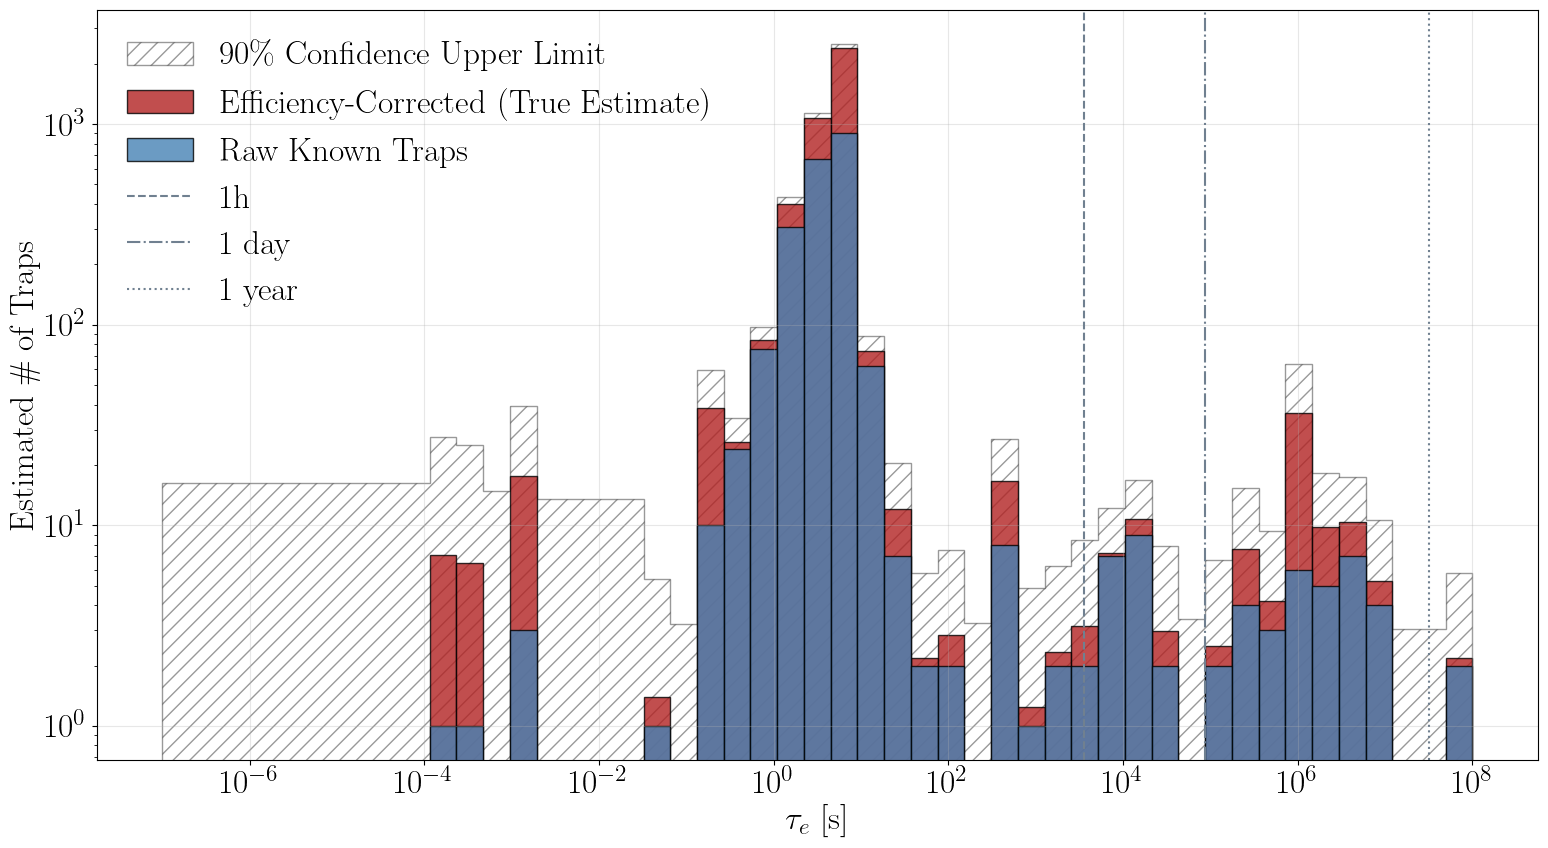

In [ ]:


# plt.figure(figsize=(16,9))

# # 1. Load the bins from your saved file
# tau_data = np.load('tau_at_135k_hist.npz')
# tau_values = tau_data['bin_edges']
# bins = tau_values
# bin_centers = np.sqrt(bins[:-1] * bins[1:])

# # 2. Reconstruct the raw and weighted histograms from your lists
# raw_hist, _ = np.histogram(tau_target_list, bins=bins)
# weighted_hist, _ = np.histogram(tau_target_list, bins=bins, weights=weights_list)

# # 3. Calculate Effective Efficiency per bin (Raw / Weighted)
# effective_efficiency = np.zeros_like(raw_hist, dtype=float)
# valid = weighted_hist > 0
# effective_efficiency[valid] = raw_hist[valid] / weighted_hist[valid]

# # 4. Interpolate efficiency for empty bins (0 counts) so the upper limit doesn't break
# if np.any(valid):
#     eff_interp = interp1d(
#         bin_centers[valid], 
#         effective_efficiency[valid], 
#         kind='nearest',        # 'nearest' works well for step-like distributions
#         bounds_error=False, 
#         fill_value="extrapolate"
#     )
#     effective_efficiency[~valid] = eff_interp(bin_centers[~valid])

# # 5. Calculate Corrected Upper Limits using your Poisson/Gamma function
# corrected_upper_limits = calculate_corrected_upper_limits(
#     raw_hist, 
#     effective_efficiency, 
#     confidence_level=0.90
# )

# # ==========================================
# # 6. Plotting
# # ==========================================

# # Plot Corrected Estimate
# # Plot the 90% Upper Limit as a stepped line hovering above the data
# plt.stairs(corrected_upper_limits, tau_values, 
#            label="90\% Confidence Upper Limit", 
#            color='black', alpha=0.4, lw=1,ls='-',fill=False, hatch='//')

# plt.hist(tau_target_list, bins=bins, weights=weights_list, 
#          color=C_RED, 
#          label='Efficiency-Corrected (True Estimate)', edgecolor='black',alpha=0.8)

# # Plot Raw Data
# plt.hist(tau_target_list, bins=bins, color=C_BLUE, edgecolor='black', 
#          alpha=0.8, label='Raw Known Traps')



# # plt.title("Emission $\\tau_e$ at 135K with Poisson Upper Limits", fontsize=16)
# plt.xlabel('$\\tau_e$ [s]', fontsize=small)
# plt.ylabel('Estimated \# of Traps', fontsize=small)

# plt.axvline(3600, label='1h', ls='--', color=C_REF)
# plt.axvline(3600*24, label='1 day', ls='-.', color=C_REF)
# plt.axvline(3600*24*365, label='1 year', ls=':', color=C_REF)

# plt.legend(frameon=False, fontsize=small)
# plt.yscale('log')
# plt.xscale('log')
# plt.grid(True, alpha=0.3)
# plt.savefig('figures/tau_at_135k_hist_upper_limit.pdf',dpi=300)
# plt.show()
# plt.close()


In [20]:
t = 135
filename = f'tau_at_{t}k_hist_upper_limit.npz'
np.savez(filename, 
            hist=corrected_upper_limits,           # Loaded as 'tau_weights' in run_ccd_simulation.py
            bin_edges=tau_values,)            # Loaded as 'tau_edges' in run_ccd_simulation.py
            # measured_taus=measured_taus,
            # extrapolated_taus=extrapolated_taus,
            # total_taus=total_taus,
            # meas_counts=meas_counts,
            # extrap_counts=extrap_counts,
            # efficiency=efficiency,
            # eff_err=eff_err)

In [21]:
import os
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from scipy.optimize import curve_fit
import hist
from hist import Hist

class NumpyEncoder(json.JSONEncoder):
    """Custom encoder to ensure Numpy arrays and scalars safely write to JSON."""
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (np.int32, np.int64, np.integer)):
            return int(obj)
        if isinstance(obj, (np.float32, np.float64, np.floating)):
            return float(obj)
        return super(NumpyEncoder, self).default(obj)

def plot_simulation_results(rundir, mask='Halo+Bleed+HotColumn+HotPixel', event_type='1e', showPlots=True,saveFig=True):
    """
    event_type: str, either '1e' or '2e' to toggle which dataset is extracted and plotted.
    """
    
    if event_type not in ['1e', '2e']:
        raise ValueError("event_type must be either '1e' or '2e'")
        
    count_key = 'counts' if event_type == '1e' else '2e_counts'

    UR_expdep = 4.36e-5 # e / pix / day
    UR_expindep = 9.94e-5 # e / superpix / image

    UR_expdep = UR_expdep / 24 # e / pix / hour
    UR_expindep = UR_expindep # e / pix / image

    colorlist = C_SEQ

    # Bins for histogram
    lower_exp0, upper_exp0 = 7e-5, 2e-4
    lower_exp4, upper_exp4 = 7e-5, 2e-4
    lower_exp6, upper_exp6 = 7e-5, 2e-4
    lower_exp10, upper_exp10 = 7e-5, 2e-4
    lower_exp20, upper_exp20 = 7e-5, 2e-4
    nbins = 25

    def init_histograms():
        return {
            0: Hist(hist.axis.Regular(nbins, lower_exp0, upper_exp0, name=f"{event_type} Densities Exp 0h")),
            4: Hist(hist.axis.Regular(nbins, lower_exp4, upper_exp4, name=f"{event_type} Densities Exp 4h")),
            6: Hist(hist.axis.Regular(nbins, lower_exp6, upper_exp6, name=f"{event_type} Densities Exp 6h")),
            10: Hist(hist.axis.Regular(nbins, lower_exp10, upper_exp10, name=f"{event_type} Densities Exp 10h")),
            20: Hist(hist.axis.Regular(nbins, lower_exp20, upper_exp20, name=f"{event_type} Densities Exp 20h")),
        }

    histograms = init_histograms()
    histograms_no_traps = init_histograms()

    # Define the cache file path (unique to mask AND event_type to avoid cross-contamination)
    cache_file = os.path.join(rundir, f'aggregated_results_{mask}_{event_type}.json')
    print(cache_file)
    # Cache Routing Logic (JSON)
    if os.path.exists(cache_file):
        print(f"Loading JSON cached aggregated {event_type} data from {cache_file}...")
        with open(cache_file, 'r') as f:
            cache = json.load(f)
            
        def restore_keys(d):
            return {int(k): v for k, v in d.items()}

        total_counts_traps = restore_keys(cache['total_counts_traps'])
        total_pix_traps = restore_keys(cache['total_pix_traps'])
        total_counts_notraps = restore_keys(cache['total_counts_notraps'])
        total_pix_notraps = restore_keys(cache['total_pix_notraps'])
        unique_exposures = np.array(cache['unique_exposures'])
        
        for k, v in cache['histograms'].items():
            histograms[int(k)][...] = np.array(v)
        for k, v in cache['histograms_no_traps'].items():
            histograms_no_traps[int(k)][...] = np.array(v)
        
    else:
        print(f"Cache not found. Processing raw HDF5 simulation files for {event_type} events...")
        
        total_counts_traps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}
        total_pix_traps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}

        total_counts_notraps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}
        total_pix_notraps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}

        # Target only HDF5 files
        target_files = [f for f in os.listdir(rundir) if f.startswith('ccd_traps_run') and f.endswith('.h5')]
        num_images = len(target_files)
        plot = False

        for i in range(num_images):
            filepath = os.path.join(rundir, f'ccd_traps_run{i}.h5')
            
            with h5py.File(filepath, 'r') as f:
                # Read all exposures into memory as an array
                exposures_array = f['exposures'][:]
                unique_exposures = np.unique(np.sort(exposures_array))

                if plot:
                    fig, ax = plt.subplots(3, figsize=(10, 12))
                    fig.suptitle(f"CCD Run {i+1} ({event_type})")
                    ax[0].set_ylabel(f'Masked {event_type} Counts')
                    ax[1].set_ylabel('Unmasked Pixels')
                    ax[2].set_ylabel(f'Unmasked {event_type} Counts')

                for e in range(len(unique_exposures)):
                    exp = unique_exposures[e]
                    expkey = int(exp / 3600)
                    exp_indices = exposures_array == exp

                    # Extract datasets using the dynamic count_key
                    counts = f['stats_trap'][mask][count_key][:][exp_indices]
                    counts_notraps = f['stats_notrap'][mask][count_key][:][exp_indices]

                    if mask == 'None':
                        unmasked_pix = unmasked_pix_notraps = int(1024 / 2) * int(6144 / 2)
                        counts_masked = counts
                        counts_masked_notraps = counts_notraps
                    else:
                        counts_masked = f['stats_trap'][mask][count_key][:][exp_indices]
                        unmasked_pix = f['stats_trap'][mask]['unmasked_pix'][:][exp_indices]

                        counts_masked_notraps = f['stats_notrap'][mask][count_key][:][exp_indices]
                        unmasked_pix_notraps = f['stats_notrap'][mask]['unmasked_pix'][:][exp_indices]

                    densities_exp = counts_masked / unmasked_pix
                    densities_exp_notraps = counts_masked_notraps / unmasked_pix_notraps

                    if plot:
                        ax[0].plot(counts_masked, label=f"{expkey}h Traps", color=colorlist[e])
                        ax[0].plot(counts_masked, label=f"{expkey}h No Traps", ls='--', color=colorlist[e])

                        ax[1].plot(unmasked_pix, label=f"{expkey}h Traps", color=colorlist[e])
                        ax[1].plot(unmasked_pix_notraps, label=f"{expkey}h No Traps", ls='--', color=colorlist[e])

                        ax[2].plot(counts, label=f"{expkey}h Traps", color=colorlist[e])
                        ax[2].plot(counts_notraps, label=f"{expkey}h No Traps", ls='--', color=colorlist[e])
                    
                    total_counts_traps[expkey] += np.sum(counts_masked)
                    total_pix_traps[expkey] += np.sum(unmasked_pix)

                    total_counts_notraps[expkey] += np.sum(counts_masked_notraps)
                    total_pix_notraps[expkey] += np.sum(unmasked_pix_notraps)
                    
                    histograms[expkey].fill(densities_exp)
                    histograms_no_traps[expkey].fill(densities_exp_notraps)

                if plot:
                    ax[0].legend()
                    ax[1].legend()
                    ax[2].legend()
                    plt.tight_layout()
                    plt.show()
                    plt.close()
        
        print("Saving aggregated data to JSON cache...")
        cache_data = {
            'histograms': {str(k): h.values() for k, h in histograms.items()},
            'histograms_no_traps': {str(k): h.values() for k, h in histograms_no_traps.items()},
            'total_counts_traps': total_counts_traps,
            'total_pix_traps': total_pix_traps,
            'total_counts_notraps': total_counts_notraps,
            'total_pix_notraps': total_pix_notraps,
            'unique_exposures': unique_exposures
        }
        
        with open(cache_file, 'w') as f:
            json.dump(cache_data, f, cls=NumpyEncoder, indent=4)

    # ==========================================
    # Proceed directly to plotting / fitting
    # ==========================================

    colorlist = C_SEQ
    
    if showPlots:
        fig, ax = plt.subplots(2, figsize=(12, 12))
        for i in range(2):
            if i == 0:
                hists = histograms
                t = 'with'
            elif i == 1:
                hists = histograms_no_traps
                t = 'without'
            for j, h in enumerate([0, 4, 6, 10, 20]):
                color = colorlist[j]
                plothist = hists[h] 
                plothist.plot1d(ax=ax[i], color=color, label=f'{h}h')

            ax[i].set_title(f"{t} traps")
            ax[i].set_ylabel("Normalized Counts")
            ax[i].set_xlabel(f"{event_type} Densities")
            ax[i].legend()
        plt.tight_layout()
        plt.show()
        plt.close()

    unique_exposures_h = unique_exposures / 3600
    unique_exposures_h = unique_exposures_h.astype(int)

    average_densities = []
    average_density_errs = []
    average_densities_notraps = []
    average_density_errs_notraps = []

    for h in unique_exposures_h:
        mean_t = total_counts_traps[h] / total_pix_traps[h]
        err_t = np.sqrt(total_counts_traps[h]) / total_pix_traps[h]
        average_densities.append(mean_t)
        average_density_errs.append(err_t)

        mean_nt = total_counts_notraps[h] / total_pix_notraps[h]
        err_nt = np.sqrt(total_counts_notraps[h]) / total_pix_notraps[h]
        average_densities_notraps.append(mean_nt)
        average_density_errs_notraps.append(err_nt)

    average_densities = np.array(average_densities)
    average_density_errs = np.array(average_density_errs)
    average_densities_notraps = np.array(average_densities_notraps)
    average_density_errs_notraps = np.array(average_density_errs_notraps)

    popt, pcov = curve_fit(linear_func, unique_exposures_h, average_densities, sigma=average_density_errs, absolute_sigma=True)
    exp_dep, exp_indep = popt

    errors = np.sqrt(np.diag(pcov))
    err_dep = errors[0]
    err_indep = errors[1]

    popt, pcov = curve_fit(linear_func, unique_exposures_h, average_densities_notraps, sigma=average_density_errs_notraps, absolute_sigma=True)

    errors_notraps = np.sqrt(np.diag(pcov))
    err_dep_notraps = errors_notraps[0]
    err_indep_notraps = errors_notraps[1]

    exp_dep_notraps, exp_indep_notraps = popt
    hours = np.linspace(0, 20, 20)

    fit_no_traps = linear_func(hours, exp_dep_notraps, exp_indep_notraps)
    fit_traps = linear_func(hours, exp_dep, exp_indep)

    fig, axes = plt.subplots(2, figsize=(12, 12), gridspec_kw={'height_ratios': [3, 1]})
    ax = axes[0]
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(formatter)

    ax.plot(hours, fit_traps, color=C_RED, alpha=0.4)
    ax.plot(hours, fit_no_traps, color=C_BLUE, alpha=0.4)

    ax.errorbar(unique_exposures_h, average_densities, yerr=average_density_errs, label='with Traps', color=C_RED, ls='None', marker='o', markersize=5, capsize=1)
    ax.errorbar(unique_exposures_h, average_densities_notraps, yerr=average_density_errs_notraps, label='without Traps', color=C_BLUE, ls='None', marker='o', markersize=5, capsize=1)
    ax.set_ylabel(f"{event_type} Density [counts/unmasked pix]")
    ax.set_xlabel("Time [hours]")

    exp_indep_p = format_sci(exp_indep)
    exp_dep_p = format_sci(exp_dep)
    exp_indep_notraps_p = format_sci(exp_indep_notraps) 
    exp_dep_notraps_p = format_sci(exp_dep_notraps)
    UR_expindep_p = format_sci(UR_expindep)
    UR_expdep_p = format_sci(UR_expdep)

    true_rate = linear_func(hours, UR_expdep, UR_expindep)
    ax.plot(hours, true_rate, label='Truth', color='black', ls='--')

    ax.text(x=0.99, y=0.30, s=f'Input Exposure Independent:  {UR_expindep_p}', transform=ax.transAxes, horizontalalignment='right', verticalalignment='center', fontsize='small', color='black')
    ax.text(x=0.99, y=0.26, s=f'Input Exposure Dependent:  {UR_expdep_p}', transform=ax.transAxes, horizontalalignment='right', verticalalignment='center', fontsize='small', color='black')
    ax.text(x=0.99, y=0.2, s=f'Exposure Independent with Traps:  {exp_indep_p}', transform=ax.transAxes, horizontalalignment='right', verticalalignment='center', fontsize='small', color=C_RED)
    ax.text(x=0.99, y=0.16, s=f'Exposure Dependent with Traps:  {exp_dep_p}', transform=ax.transAxes, horizontalalignment='right', verticalalignment='center', fontsize='small', color=C_RED)
    ax.text(x=0.99, y=0.10, s=f'Exposure Independent without Traps:  {exp_indep_notraps_p}', transform=ax.transAxes, horizontalalignment='right', verticalalignment='center', fontsize='small', color=C_BLUE)
    ax.text(x=0.99, y=0.06, s=f'Exposure Dependent without Traps:  {exp_dep_notraps_p}', transform=ax.transAxes, horizontalalignment='right', verticalalignment='center', fontsize='small', color=C_BLUE)

    ax.legend(frameon=False)

    diff = average_densities - average_densities_notraps
    differr = np.sqrt(average_density_errs**2 + average_density_errs_notraps**2)
    
    axes[1].errorbar(unique_exposures_h, average_densities - average_densities_notraps, yerr=differr, color='black', ls="None", marker='o', capsize=3)
    axes[1].set_ylabel("Difference")
    axes[1].axhline(0, ls='dashed', color=C_REF)
    axes[1].minorticks_on()
    axes[0].minorticks_on()
    axes[0].set_xticks(np.arange(0, 22, 2))
    plt.tight_layout()
    
    runname = rundir.replace('/', '').replace(".", '')
    
    os.makedirs('figures', exist_ok=True)
    if saveFig:
        plt.savefig(f'figures/{runname}_{event_type}_sim_results.pdf', dpi=300)
    
    if showPlots:
        plt.show()
    plt.close()

    mosaic = """
    AABB
    CCDD
    EEFF
    """

    fig, ax_dict = plt.subplot_mosaic(mosaic, figsize=(15, 15), constrained_layout=True)
    key_list = ['A','B','C','D','E','F']
    
    for i in range(len(average_densities)):
        key = key_list[i]
        truth = linear_func(unique_exposures_h[i], UR_expdep, UR_expindep)
        ax_dict[key].errorbar(unique_exposures_h[i], average_densities[i], yerr=average_density_errs[i], label='with Traps', color=C_RED, capsize=3, marker='o', markersize=5)
        ax_dict[key].errorbar(unique_exposures_h[i], average_densities_notraps[i], yerr=average_density_errs_notraps[i], label='without Traps', color=C_BLUE, capsize=3, marker='o', markersize=5)
        ax_dict[key].scatter(unique_exposures_h[i], truth, color='black', label='Truth')
        ax_dict[key].legend()
        ax_dict[key].set_title(f"Exposure: {unique_exposures_h[i]}h")
        ax_dict[key].minorticks_on()

    key = 'F' 
    diff_err = np.sqrt(average_density_errs**2 + average_density_errs_notraps**2)
    ax_dict[key].errorbar(unique_exposures_h, diff, yerr=diff_err, marker='o', capsize=3, color='black', ls="None")
    ax_dict[key].set_ylabel("Differences")
    ax_dict[key].set_xlabel("Exposure [h]")
    ax_dict[key].minorticks_on()

    if showPlots:
        plt.show()
    plt.close()

    return (exp_indep, exp_dep, exp_indep_notraps, exp_dep_notraps, UR_expindep, UR_expdep, 
            err_indep, err_dep, err_indep_notraps, err_dep_notraps)

./minos_conditions/aggregated_results_Halo_1e.json
Cache not found. Processing raw HDF5 simulation files for 1e events...
Saving aggregated data to JSON cache...


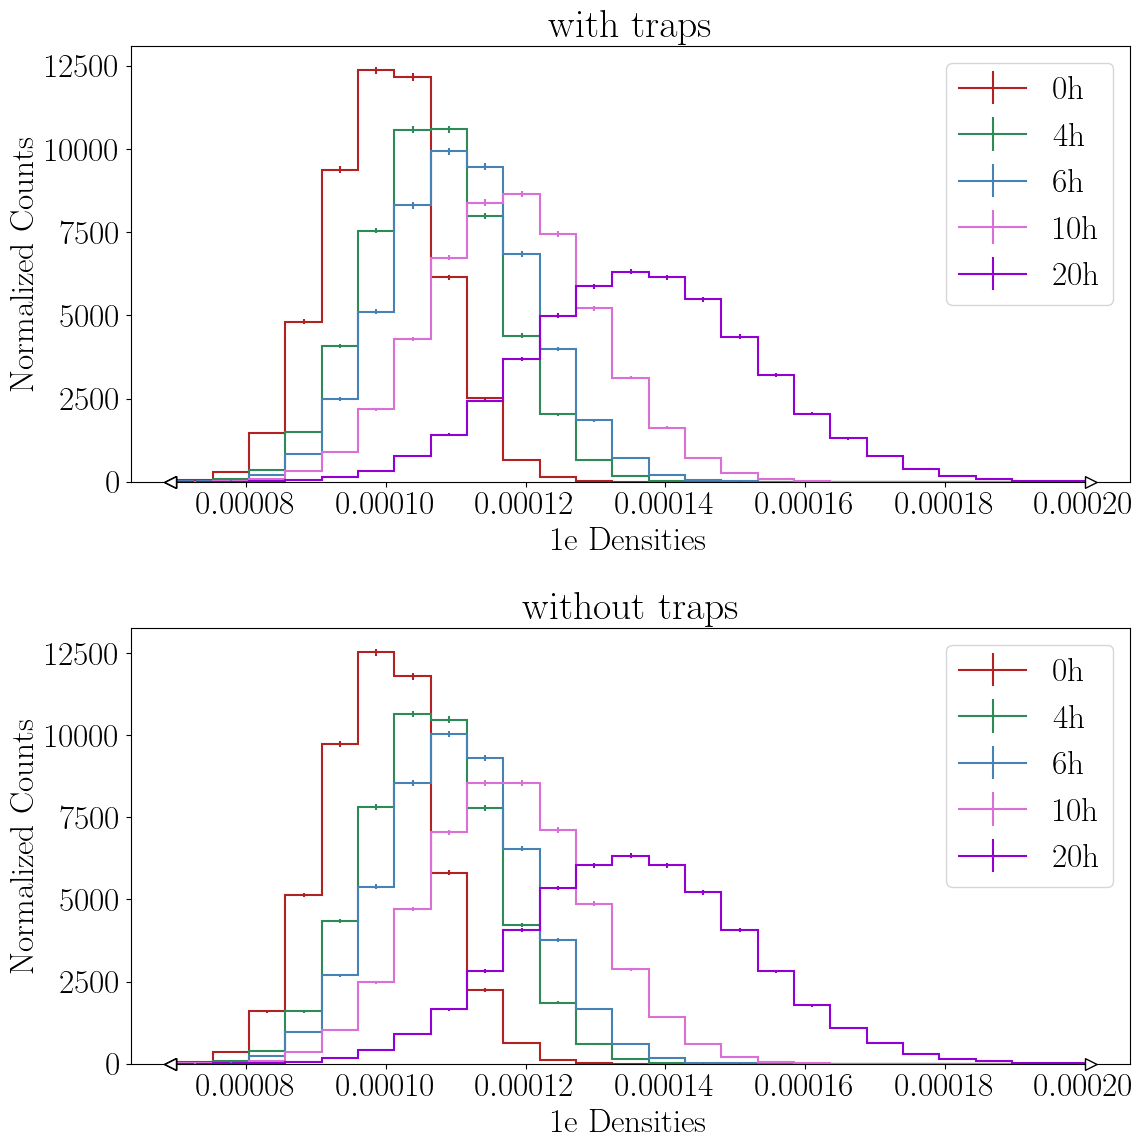

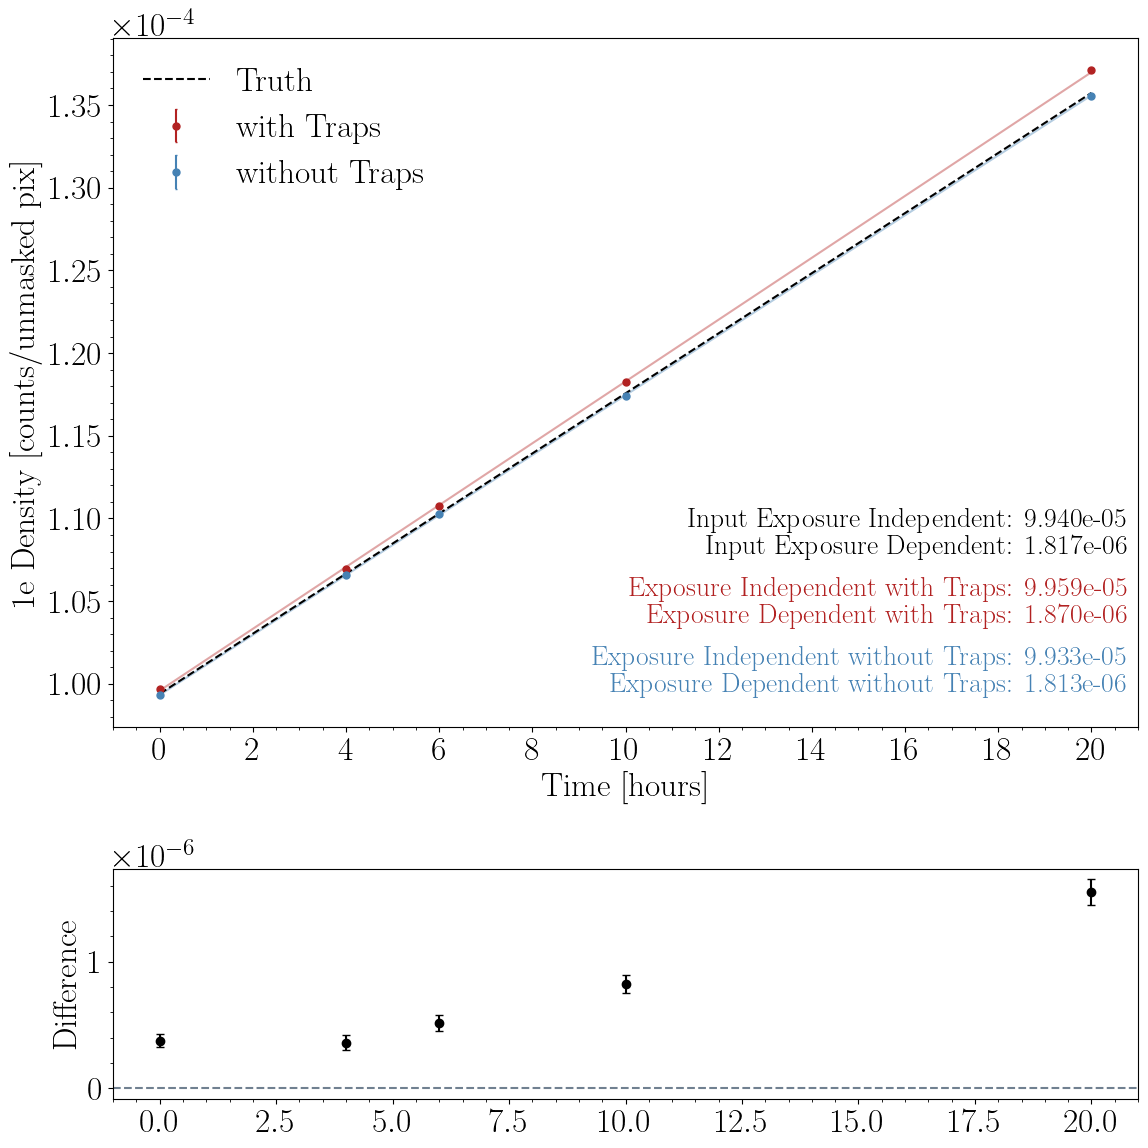

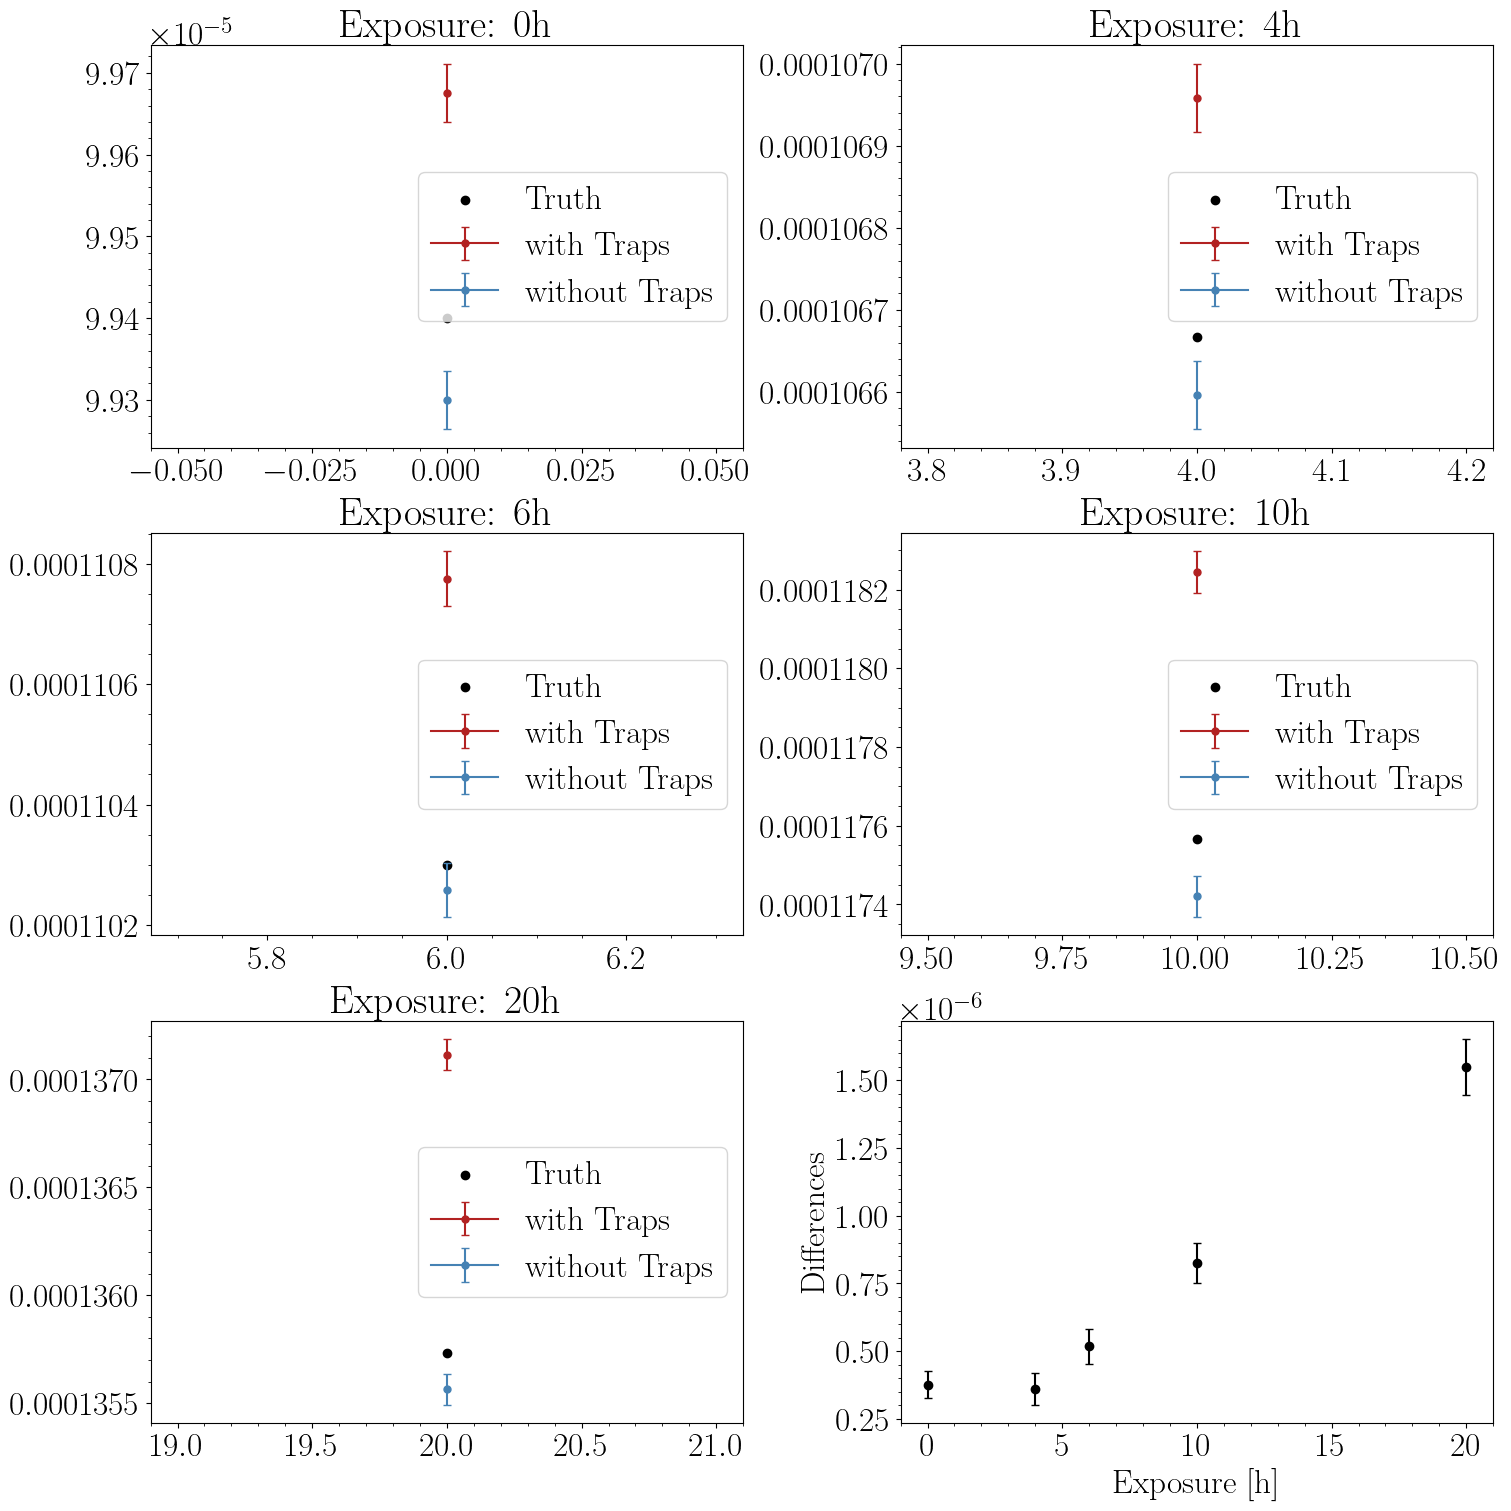

In [11]:
mask = 'Halo+Bleed+HotColumn+HotPixel'
mask = 'None'
mask = 'Halo'
rm = './minos_conditions/'
results = plot_simulation_results(rm, mask=mask,showPlots=True,saveFig=False)

In [12]:
#(exp_indep, exp_dep, exp_indep_notraps, exp_dep_notraps, UR_expindep, UR_expdep, 
            #err_indep, err_dep, err_indep_notraps, err_dep_notraps)
for i in range(4):
    print(results[i])
print(results[0] - results[2], (results[1] - results[3])*24)
print(100*(results[0] - results[2]) /results[4] , 100*(results[1] - results[3])/(results[5]))


9.958883537268326e-05
1.8697560425889465e-06
9.932567716655337e-05
1.8129457706975368e-06
2.631582061298854e-07 1.3634465253938344e-06
0.2647466862473696 3.1271709298023724


In [30]:
rundir = './minos_conditions/'
rundir = './minos_conditions_binned/'
rundir = './minos_conditions_upperlimit/'
rundir = './minos_conditions_binned_upperlimit/'
rundir = './snolab_conditions/'
rundir = './snolab_conditions_binned/'
rundir = './snolab_conditions_upperlimit/'
rundir = './snolab_conditions_binned_upperlimit/'

# run_directories_minos = ['./minos_conditions/','./minos_conditions_binned/','minos_conditions_upperlimit/','minos_conditions_binned_upperlimit/']
# run_directories_snolab = ['./snolab_conditions/','./snolab_conditions_binned/','snolab_conditions_upperlimit/','snolab_conditions_binned_upperlimit/']
run_directories_minos = ['./minos_conditions/','minos_conditions_upperlimit/']
run_directories_snolab = ['./snolab_conditions/','snolab_conditions_upperlimit/']
# mask = "None"
# mask = 'Halo'
# # mask = 'Halo+Bleed'
# # mask = "Halo+Bleed+HotPixel"
# # mask = "Halo+Bleed+HotColumn"
# mask = 'Halo+Bleed+HotColumn+HotPixel
minos_results = []
snolab_results = []
minos_results = []
snolab_results = []
all_results = []
for rm in run_directories_minos:
    results = plot_simulation_results(rm, mask='Halo+Bleed+HotColumn+HotPixel',showPlots=False)
    minos_results.append(results)
    all_results.append(results)

for rs in run_directories_snolab:
    results = plot_simulation_results(rs, mask='Halo+Bleed+HotColumn+HotPixel',showPlots=False)
    snolab_results.append(results)
    all_results.append(results)

# Convert to arrays: they will now have 10 columns instead of 6
m_res = np.array(minos_results)
s_res = np.array(snolab_results)
a_res = np.array(all_results)


./minos_conditions/aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json
Loading JSON cached aggregated 1e data from ./minos_conditions/aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json...
minos_conditions_upperlimit/aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json
Loading JSON cached aggregated 1e data from minos_conditions_upperlimit/aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json...
./snolab_conditions/aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json
Loading JSON cached aggregated 1e data from ./snolab_conditions/aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json...
snolab_conditions_upperlimit/aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json
Loading JSON cached aggregated 1e data from snolab_conditions_upperlimit/aggregated_results_Halo+Bleed+HotColumn+HotPixel_1e.json...


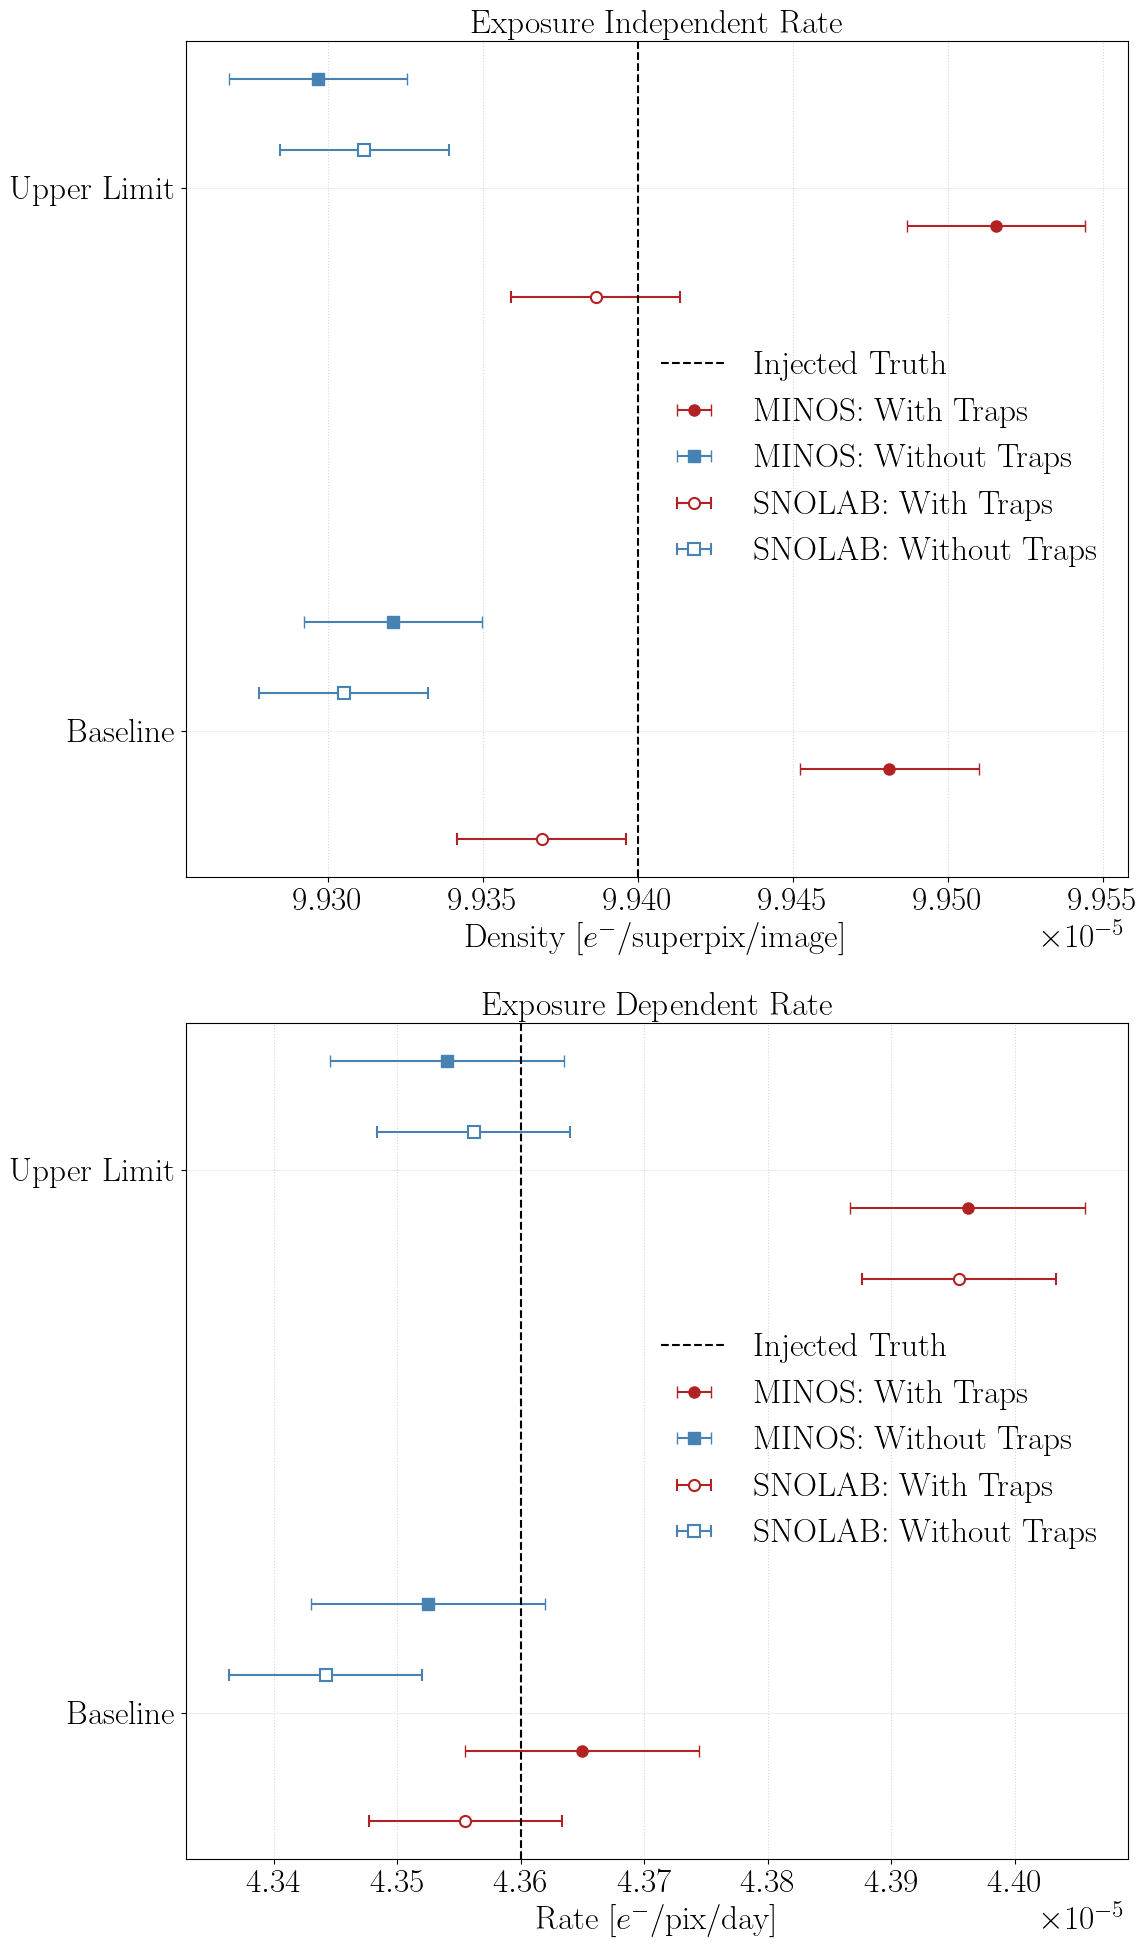

In [31]:


m_res = np.array(minos_results)
s_res = np.array(snolab_results)

# 3. Setup Plot Labels and Positions
labels = ['Baseline', 'Upper Limit']
y_pos = np.arange(len(labels))

# Create a 2-row figure instead of 4
fig, axes = plt.subplots(2, 1, figsize=(12,20), sharey=True)
fig.subplots_adjust(hspace=0.3)

# 4. The Combined Plotting Function
def plot_forest_combined(ax, m_data, s_data, col_indep, col_notraps, col_truth, col_err_traps, col_err_notraps, title, xlabel):
    if 'Exposure Dependent' in title:
        scale = 24
    else:
        scale = 1
    # Offsets to keep the 4 points from overlapping on the same Y-line
    o_s_trap = -0.20   # SNOLAB Traps (Highest)
    o_m_trap = -0.07   # MINOS Traps
    o_s_notrap = 0.07  # SNOLAB No Traps (Lowest)
    o_m_notrap = 0.20  # MINOS No Traps o_s_notrap

    # --- MINOS Data (Filled Markers) ---
    ax.errorbar(m_data[:, col_indep]*scale, y_pos + o_m_trap, xerr=m_data[:, col_err_traps]*scale, 
                fmt='o', color=C_RED, linestyle='none', label='MINOS: With Traps', markersize=8, capsize=4)
    
    ax.errorbar(m_data[:, col_notraps]*scale, y_pos + o_m_notrap, xerr=m_data[:, col_err_notraps]*scale, 
                fmt='s', color=C_BLUE, linestyle='none', label='MINOS: Without Traps', markersize=8, capsize=4)

    # --- SNOLAB Data (Open Markers, controlled via markerfacecolor='white') ---
    ax.errorbar(s_data[:, col_indep]*scale, y_pos + o_s_trap, xerr=s_data[:, col_err_traps]*scale, 
                fmt='o', color=C_RED, linestyle='none', label='SNOLAB: With Traps', 
                markersize=8, capsize=4, markerfacecolor='white', markeredgewidth=1.5)
    
    ax.errorbar(s_data[:, col_notraps]*scale, y_pos + o_s_notrap, xerr=s_data[:, col_err_notraps]*scale, 
                fmt='s', color=C_BLUE, linestyle='none', label='SNOLAB: Without Traps', 
                markersize=8, capsize=4, markerfacecolor='white', markeredgewidth=1.5)

    # --- Truth Line ---
    truth_val = m_data[0, col_truth]*scale
    ax.axvline(x=truth_val, color='black', linestyle='--', linewidth=1.5, label='Injected Truth')

    # --- Formatting ---
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=small)
    ax.invert_yaxis() # Put 'Baseline' at the top
    
    ax.set_title(title, fontsize=small, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=small)
    
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(formatter)
    
    # Light gridlines for readability
    ax.grid(True, axis='y', linestyle='-', alpha=0.2)
    ax.grid(True, axis='x', linestyle=':', alpha=0.5)

# --- Subplot 1: Exposure Independent (Intercepts) ---
# Traps=0, NoTraps=2, Truth=4, ErrTraps=6, ErrNoTraps=8
plot_forest_combined(axes[0], m_res, s_res, 0, 2, 4, 6, 8,
                     title="Exposure Independent Rate", 
                     xlabel=r"Density [$e^-$/superpix/image]")

# --- Subplot 2: Exposure Dependent (Slopes) ---
# Traps=1, NoTraps=3, Truth=5, ErrTraps=7, ErrNoTraps=9
plot_forest_combined(axes[1], m_res, s_res, 1, 3, 5, 7, 9,
                     title="Exposure Dependent Rate", 
                     xlabel=r"Rate [$e^-$/pix/day]")

# --- Legend & Polish ---
handles, plot_labels = axes[0].get_legend_handles_labels()

# Move legend to the middle-right side (bbox_to_anchor=(1.02, 0.5))
# Set ncol=1 to stack the labels vertically
axes[0].legend(handles, plot_labels, loc='center right', ncol=1, fontsize=small, frameon=False)#, bbox_to_anchor=(1.02, 0.5))
axes[1].legend(handles, plot_labels, loc='center right', ncol=1, fontsize=small, frameon=False)#, bbox_to_anchor=(1.02, 0.5))

# Use 'rect' to compress the subplots into the left 80% of the figure, 
# leaving a dedicated blank column on the right side for the legend to sit in.
# plt.tight_layout(rect=[0, 0, 0.80, 1])

# Save and Show
plt.savefig('figures/results_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
s_res,m_res

In [ ]:
m_res[0][0]- m_res[0][2],m_res[1][0]- m_res[1][2]

In [ ]:
m_res[0][1]- m_res[0][3],m_res[1][1]- m_res[1][3]

In [ ]:
(exp_indep, exp_dep, exp_indep_notraps, exp_dep_notraps, UR_expindep, UR_expdep, 
            err_indep, err_dep, err_indep_notraps, err_dep_notraps)

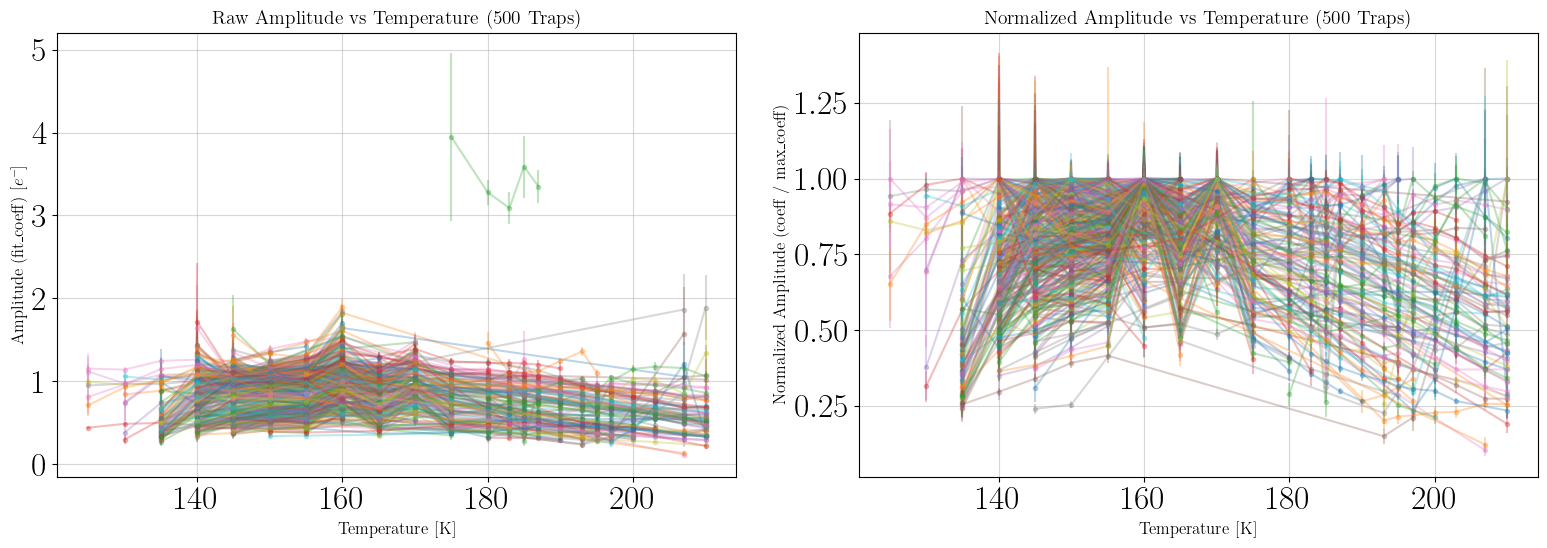

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Assuming 'fit_dipole_spectra' is already loaded in your notebook.
# If not, uncomment the line below:
# fit_dipole_spectra = load_spectra_hdf5('fit_dipole_spectra_err_4.h5')

num_traps_to_plot = 500 # Adjust this to see more or fewer traps

# Gather all well-behaved traps
all_well_behaved = []
for q in [0, 1, 2, 3]:
    if q not in fit_dipole_spectra:
        continue
    for dp, trap in fit_dipole_spectra[q].items():
        if isinstance(dp, tuple) and trap.get('WellBehavedTrap', False):
            all_well_behaved.append(trap)

# Pick a random subset to avoid over-cluttering the plot
traps_subset = random.sample(all_well_behaved, min(num_traps_to_plot, len(all_well_behaved)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for trap in traps_subset:
    temps = []
    coeffs = []
    coeff_errs = []
    
    # Extract temperature and fit info
    for key, data in trap.items():
        if isinstance(key, int) and data.get('GoodIntensityFit', False):
            temps.append(key)
            coeffs.append(data['fit_coeff'])
            coeff_errs.append(data['fit_coeff_err'])
            
    if len(temps) > 3:
        # Sort by temperature so the lines draw correctly left-to-right
        sort_idx = np.argsort(temps)
        temps = np.array(temps)[sort_idx]
        coeffs = np.array(coeffs)[sort_idx]
        coeff_errs = np.array(coeff_errs)[sort_idx]
        
        # Plot 1: Raw Amplitude
        axes[0].errorbar(temps, coeffs, yerr=coeff_errs, fmt='-o', alpha=0.3, markersize=3)
        
        # Plot 2: Normalized Amplitude (normalized to the max amplitude of that trap)
        max_coeff = np.max(coeffs)
        normalized_coeffs = coeffs / max_coeff
        normalized_errs = coeff_errs / max_coeff
        axes[1].errorbar(temps, normalized_coeffs, yerr=normalized_errs, fmt='-o', alpha=0.3, markersize=3)

# Formatting Raw Plot
axes[0].set_xlabel('Temperature [K]', fontsize=12)
axes[0].set_ylabel('Amplitude (fit_coeff) [$e^-$]', fontsize=12)
axes[0].set_title(f'Raw Amplitude vs Temperature ({len(traps_subset)} Traps)', fontsize=14)
axes[0].grid(True, alpha=0.5)

# Formatting Normalized Plot
axes[1].set_xlabel('Temperature [K]', fontsize=12)
axes[1].set_ylabel('Normalized Amplitude (coeff / max_coeff)', fontsize=12)
axes[1].set_title(f'Normalized Amplitude vs Temperature ({len(traps_subset)} Traps)', fontsize=14)
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


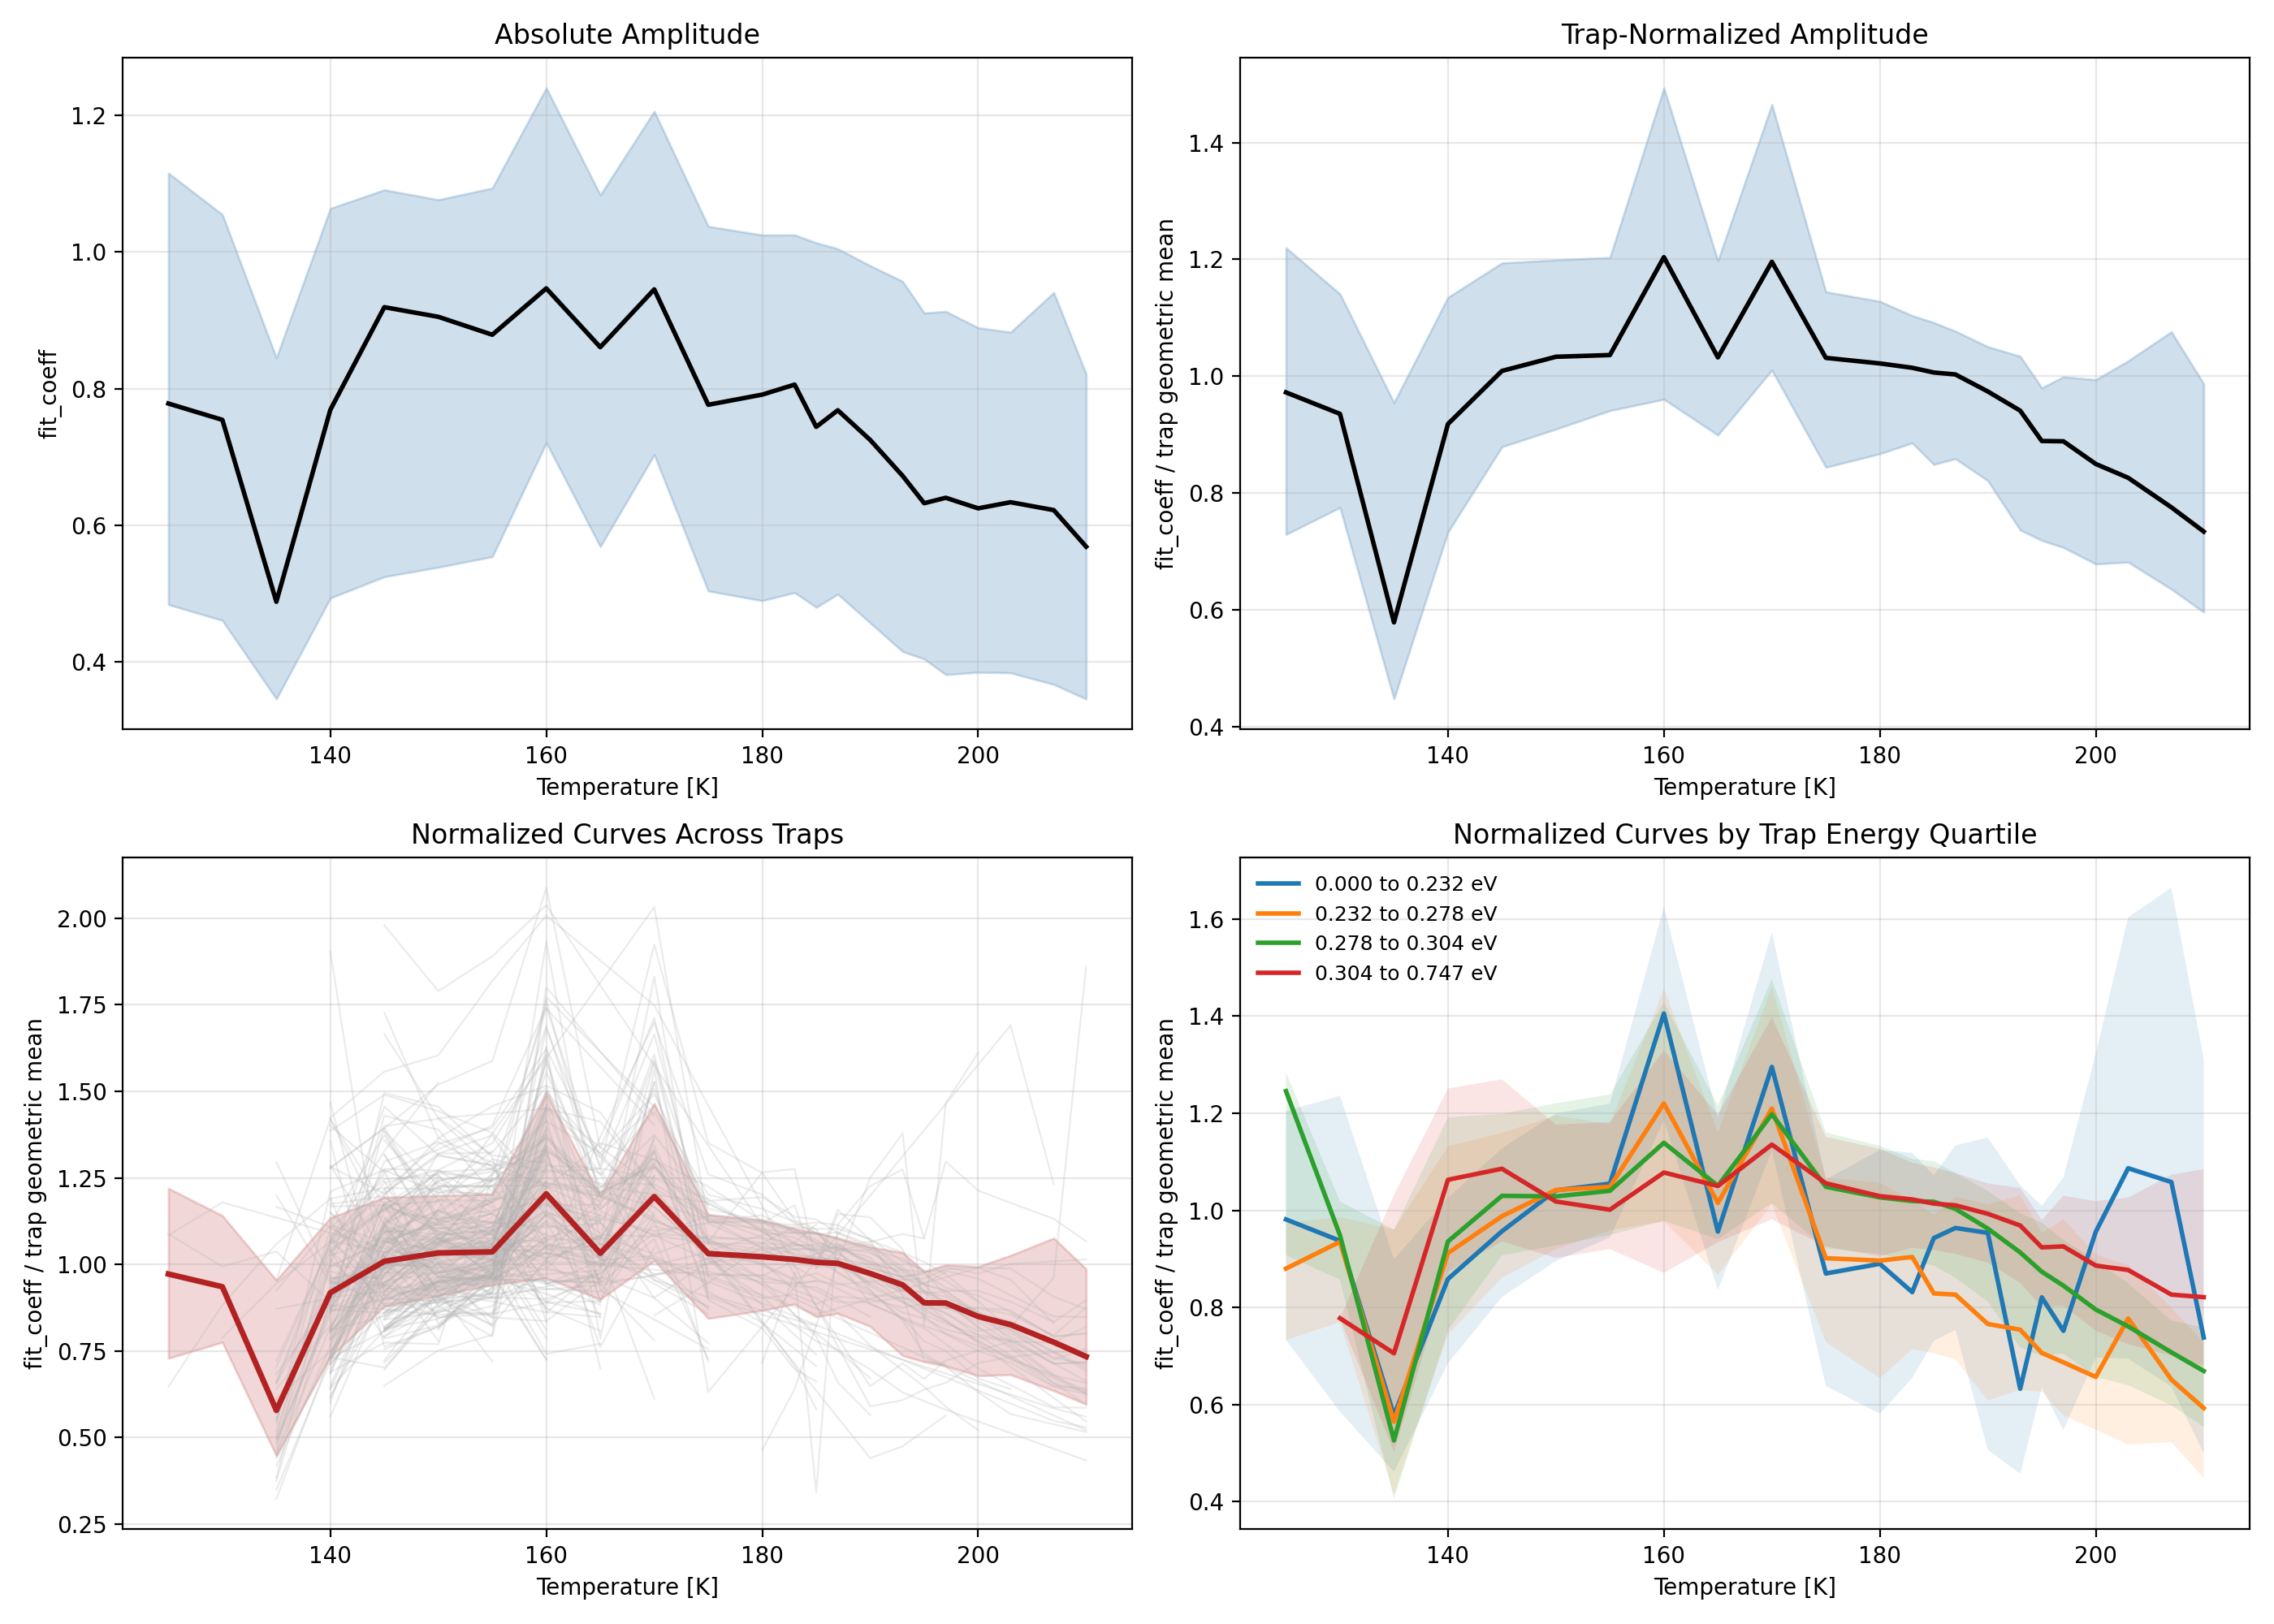

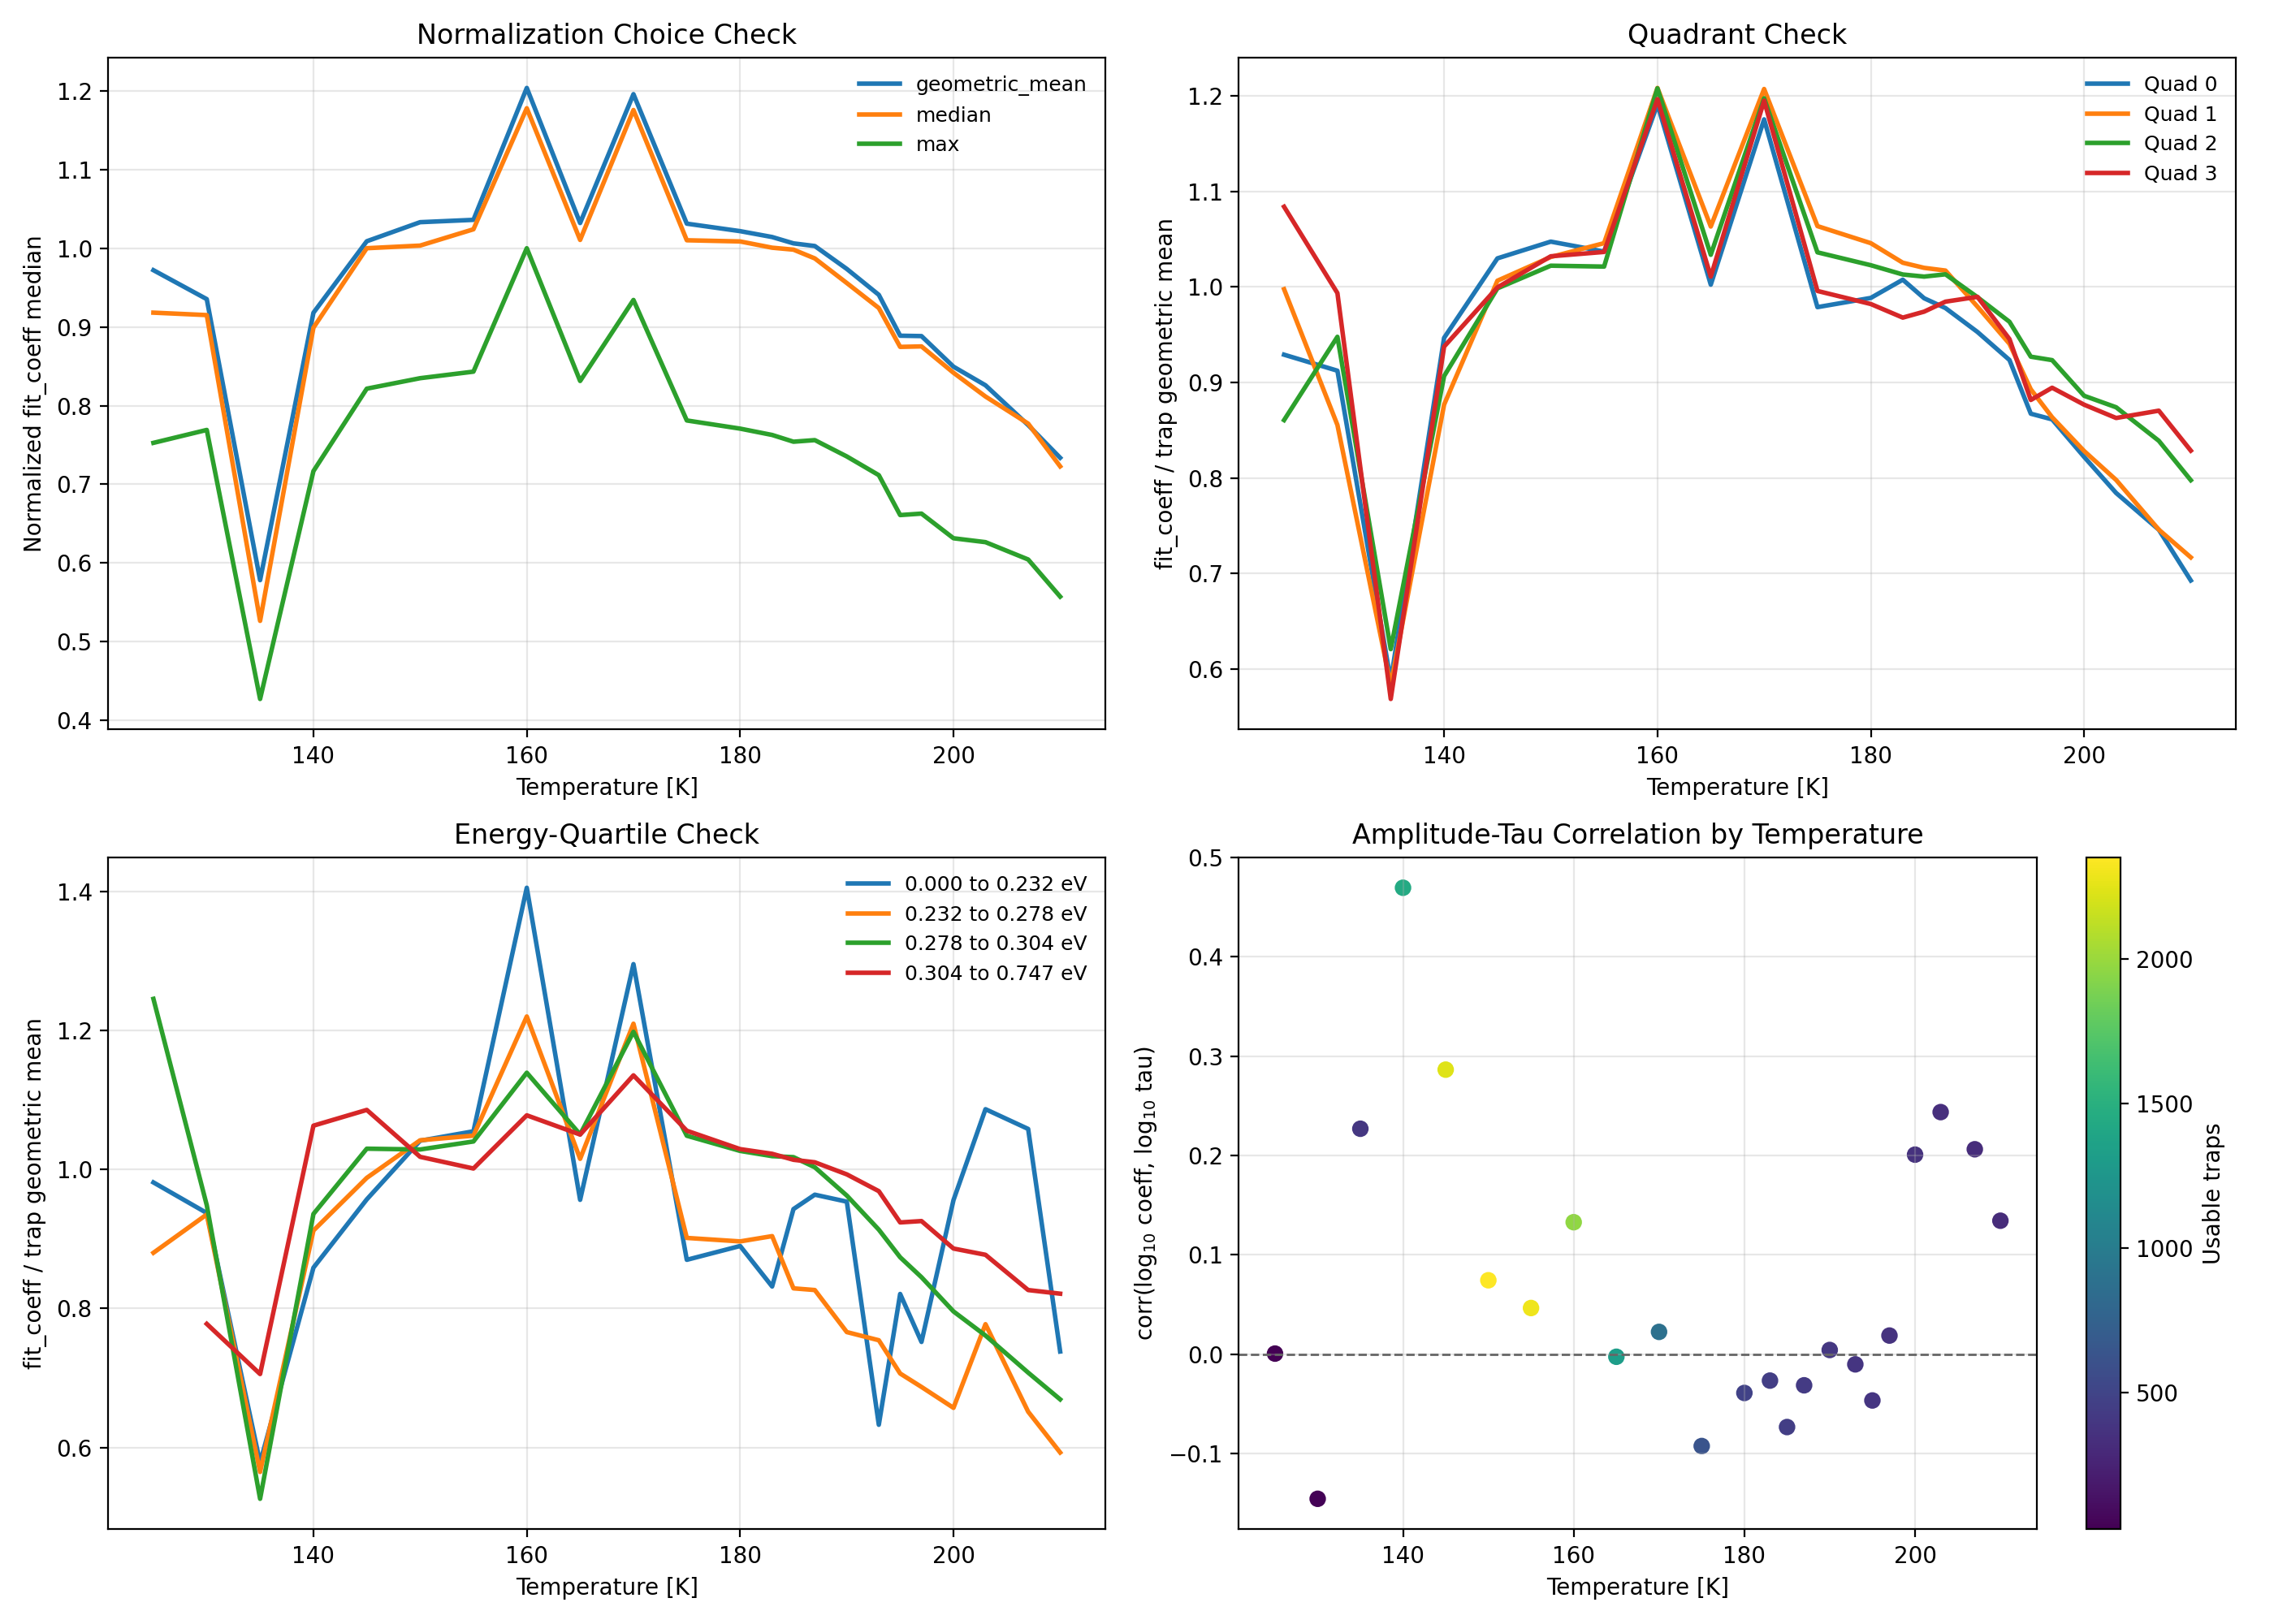

In [25]:
from IPython.display import Image, display

display(Image("coeff_vs_temperature_summary.png", width=1200))
display(Image("coeff_vs_temperature_followups.png", width=1200))

# Amplitude vs Temperature Across Traps

## Suggested code cell

```python

```

## Suggested markdown cell

### Question

Do all traps have the same amplitude-versus-temperature relation, where the amplitude is the fitted `fit_coeff` from the intensity model in `dipole.py`?

### Methodology

I used the saved per-trap intensity-fit results in `fit_dipole_spectra_err_4.h5`. For each trap and each temperature, I extracted the fitted amplitude `fit_coeff` only when the temperature point had `GoodIntensityFit=True`. To focus on traps with reasonably complete and stable behavior, I restricted the main normalized study to traps that were marked `WellBehavedTrap=True`, had `EnergyFitFailed=False`, and had at least 4 good temperature points. This left 2,514 usable traps.

I studied the question in two complementary ways:

1. **Absolute amplitude**: compare the raw fitted `fit_coeff(T)` values across traps.
2. **Normalized amplitude**: divide each trap's amplitude curve by its own typical scale and compare the resulting shapes.

For the normalization, I used each trap's **geometric-mean amplitude** across temperature, rather than normalizing by the maximum point. The goal was to test whether the curves share a common **shape** up to an overall multiplicative scale, without artificially forcing every trap to equal 1 at its highest point.

### How to read the main summary figure

- **Top left: Absolute Amplitude**
  This panel shows the median raw `fit_coeff` across traps at each temperature, with the 16th to 84th percentile band. It answers whether all traps have the same absolute amplitude scale. They do not.

- **Top right: Trap-Normalized Amplitude**
  This panel shows the same quantity after dividing each trap by its own geometric-mean amplitude. This isolates the temperature dependence of the amplitude from the trap-to-trap scale differences.

- **Bottom left: Normalized Curves Across Traps**
  Gray curves are individual normalized trap curves, and the red curve is the population median with the 16th to 84th percentile band. This makes it easy to see both the common trend and the remaining trap-to-trap scatter.

- **Bottom right: Normalized Curves by Trap Energy Quartile**
  This checks whether the normalized amplitude shape depends on fitted trap energy.

### Main result

The amplitude-versus-temperature relation is **not identical for all traps**, but it is also **not completely unrelated from trap to trap**.

After removing the overall scale of each trap, there is a clear shared average trend:

- the normalized amplitude is low near 135 K,
- rises toward a broad maximum around 160 to 170 K,
- then falls again toward 210 K.

Numerically, the median normalized amplitude is:

- about **0.58** at 135 K,
- about **1.01** at 145 K,
- about **1.20** at 160 K,
- about **1.20** at 170 K,
- about **0.97** at 190 K,
- about **0.73** at 210 K.

So the simplest summary is:

> The traps appear to share a broad common amplitude-versus-temperature shape once each trap is rescaled by its own characteristic amplitude, but there is still noticeable trap-to-trap scatter around that shared trend.

## Follow-up checks

### 1. Does the answer depend strongly on how the curves are normalized?

I compared three normalizations:

- geometric mean of each trap,
- median of each trap,
- maximum of each trap.

The **geometric-mean** and **median** normalizations give very similar temperature trends. The **max-normalized** curves look systematically flatter and are forced to peak near 1 by construction, which makes the traps look more similar than they really are. For that reason, I treat the geometric-mean normalization as the most honest version of the â€œsame shape up to scale?â€ question.

### 2. Are some temperatures too sparse to trust?

Yes, especially the lowest temperatures.

The usable-trap counts by temperature are:

- 125 K: 25 traps
- 130 K: 41 traps
- 135 K: 389 traps
- 140 K: 1,444 traps
- 145 K: 2,238 traps
- 150 K: 2,354 traps

and then gradually decreasing again at the highest temperatures.

This means the broad trend from roughly **140 K to 210 K** is much better supported than the behavior at **125 K to 130 K**. The dip at 135 K is already based on a much healthier sample than 125 K or 130 K, but the very earliest points should still be interpreted cautiously.

### 3. Do different CCD quadrants behave differently?

Not in a major way.

All four quadrants show the same broad normalized pattern: rise toward about 160 to 170 K and decline by 210 K. There is some modest spread at the highest temperatures. For example, the median normalized amplitude at 210 K is:

- Quad 0: 0.69
- Quad 1: 0.72
- Quad 2: 0.80
- Quad 3: 0.83

So there may be some quadrant dependence in the high-temperature tail, but quadrant-to-quadrant differences are smaller than the overall shared temperature trend.

### 4. Does the trend depend on fitted trap energy?

Somewhat, but not enough to erase the shared shape.

When the traps are split into fitted-energy quartiles, all quartiles still show the same broad behavior: a dip around 135 K, a rise toward 160 to 170 K, and a decline at high temperature. The lowest-energy quartile shows the largest deviations from the overall median shape, especially at high temperature, so it would be fair to say:

> there is evidence for a common trend, but the detailed shape is not perfectly universal across trap-energy populations.

### 5. Could amplitude-tau covariance in the fit be driving the trend?

Possibly in part, but probably not all of it.

I checked the correlation between `log10(coeff)` and `log10(tau)` across traps at fixed temperature. The correlation varies with temperature:

- near zero at several temperatures,
- moderately positive around 140 K,
- mildly positive again at the highest temperatures.

So amplitude-tau covariance is real and should be kept in mind, but it does **not** look like a single simple degeneracy that explains the whole temperature pattern. A stronger follow-up would be to repeat the study with `tau(T)` fixed from each trap's energy-fit model and refit only the amplitude.

## Conclusion

The data do **not** support the statement that the amplitude-versus-temperature relation is exactly the same for all traps.

A better statement is:

> Most traps appear to follow a similar average amplitude-versus-temperature curve after removing their overall amplitude scale, but there is still meaningful trap-to-trap scatter, plus some dependence on trap energy and possibly on fit covariance at specific temperatures.

## Reasonable next steps

1. Repeat the study with `tau(T)` fixed from the energy fit, to reduce amplitude-tau degeneracy.
2. Quantify the residual scatter around a shared temperature curve and compare it to the reported `fit_coeff_err`.
3. Fit a simple shared-shape model, for example `log coeff_trap(T) = alpha_trap + f(T) + residual`, and test whether the residual structure depends on energy or quadrant.
4. If the low-energy quartile remains distinct, treat that as evidence for multiple trap populations rather than one universal amplitude shape.
